## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

## Loading the dataset

## Data Overview

* Observations
* Sanity checks

In [6]:
data = pd.read_csv("Loan_Modelling.csv")
# create a copy of the data to avoid any changes to the original data
df = data.copy()
# Display 10 random sample rows of the dataset
df.sample(10)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
1565,1566,34,9,104,95758,3,1.20,3,0,0,0,0,1,0
1380,1381,60,34,105,92103,2,1.40,1,0,0,0,0,1,0
4840,4841,33,9,18,91768,4,0.40,2,0,0,0,0,1,0
170,171,27,1,138,90250,2,2.00,1,0,0,0,0,1,0
2879,2880,42,15,73,94545,3,2.33,2,0,0,0,0,0,0
1467,1468,62,36,29,91107,2,0.70,3,0,0,0,0,0,0
31,32,40,16,29,94117,1,2.00,2,0,0,0,0,1,0
2045,2046,52,28,44,95051,4,0.90,2,107,0,0,0,1,0
962,963,47,21,120,95833,1,0.00,1,135,0,0,0,0,0
4541,4542,62,38,124,95023,1,3.80,1,405,0,0,0,1,0


## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

# we will drop the ID Columns as it does not add a predictibility value
loan.drop("ID", axis=1, inplace=True)
loan.sample(5)


In [7]:
# viewing the shape of the data set
df.shape

(5000, 14)

In [8]:
#Checking for null and duplicate values
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


In [9]:
df.duplicated().sum()

0

In [10]:
# viewing the variables datatypes
df.dtypes

,0
ID,int64
Age,int64
Experience,int64
Income,int64
ZIPCode,int64
Family,int64
CCAvg,float64
Education,int64
Mortgage,int64
Personal_Loan,int64


In [11]:
#Five point summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


Observation:

The min Age is 23 , max is 67 , Average is 45 Years old - Data
seems reasonable and normaly distributed
The min Experience is -3 years which does not seem reasonable, hence requires a closer look
The min Income is USD 46k, max is USD 224K and average is USD 64K - Dataset seems to be right skewed
The Zip codes shall not be treated as an integer value as it reflects location - Requires data pre-processing
The min Family size is 1, max is 4 and average is 2 - Dataset seems reasonable and almost uniformly distributed and can be treated as a categorical variable as it holds only 4 values
The min CCAvg is USD 0k (which can be reflecting customers who do not own credit cards), max is USD 1.9K and average is USD 10K - Dataset seems reasonable and right skewed
The Education is a categorical variable where 1: Undergrad; 2: Graduate;3: Advanced/Professional
The min Mortgage is USD 0k, max is USD 635K and average is USD 0K - Dataset heavily right skewed
The Personal_Loan is a categorical variable where 1: customer accepted the personal loan offered in the last campaign and 0:customer didnot accept
The Securities_Account is a categorical variable where 1: customer has Securities_Account 0:customer does not have Securities_Account
The CD_Account is a categorical variable where 1: customer has CD_Account 0:customer does not have CD_Account
The Online is a categorical variable where 1: customer uses online banking 0:customer does use online banking
The CreditCard is a categorical variable where 1: customer use a credit card issued by any other Bank 0:customer does not use a credit card issued by any other BankList item


## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [12]:
# displaying how many rows carries a negative value
print(f'There are {len(df[df["Experience"] < 0])} rows with a negative value')

There are 52 rows with a negative value


In [75]:
# displaying how many rows carries a negative value
print(f'There are {len(df[df["Experience"] < 0])} rows with a negative value')

There are 52 rows with a negative value


The data distribution is roughly taking the shape of a uniformly distributed curve. Accordingly, the approach to amputate the -ve values is by setting them equal to the median



In [13]:
df["Experience"] = df["Experience"].apply(
    lambda x: df["Experience"].median() if x < 0 else x
)

In [14]:
# checking the value counts to confirm amputation is successful
len(df[df["Experience"] < 0])

0

Zip code conversion
Using the "uszipcode" library, we extract the "City" and "State" from the zipcode of every customer



In [15]:
!pip install uszipcode
!pip install pgeocode
import pandas as pd
import pgeocode

# Initialize the geocoder for US ZIP codes
nomi = pgeocode.Nominatim('us')

# Function to fetch city and state from a given ZIP code
def get_city_state(zipcode):
    # Handle missing or non-numeric zip codes
    if pd.isna(zipcode) or not str(zipcode).isdigit():
        return None, None
    # Query the city and state using pgeocode
    result = nomi.query_postal_code(zipcode)
    if result is not None:
        city = result.place_name
        state = result.state_code
        return city, state
    else:
        return None, None

loan = pd.DataFrame(df)

loan[['City', 'State']] = loan['ZIPCode'].apply(lambda z: pd.Series(get_city_state(z)))

loan.to_csv('loans.csv', index=False)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 3.8 MB/s eta 0:00:00
  Created wheel for atomicwrites: filename=atomicwrites-1.4.1-py2.py3-none-any.whl size=6940 sha256=6ca3b7d8d548b1e660313809abf719bdbe3550e161250fbd9a1b13cd74dbfe9b
  Stored in directory: /root/.cache/pip/wheels/34/07/0b/33b15f68736109f72ea0bb2499521d87312b932620737447a2
Successfully built atomicwrites


In [16]:
loan.head()
loan.shape

(5000, 16)

In [17]:
df1 = loan.drop(columns=['ID'])
df1.head()
df.shape

(5000, 14)

In [18]:
#explorying the null values added in the dataframe from the city and state lists
df1['City'].isnull().value_counts()

,count
City,
False,4959
True,41


In [19]:
df1['State'].isnull().value_counts()

,count
State,
False,4959
True,41


In [20]:
#extracting the zipcodes that are returning the nan values
zip_nan = df1[df1['City'].isnull()]
zip_nan['ZIPCode'].value_counts()

,count
ZIPCode,
92717,22
92709,7
96651,6
92634,5
93077,1


There are 5 unique Zip codes reflecting as NAN in the city column.



In [21]:
# Checking the same for the state column
zip_nan_state = df1[df1['State'].isnull()]
zip_nan_state['ZIPCode'].value_counts()

,count
ZIPCode,
92717,22
92709,7
96651,6
92634,5
93077,1


The missing city and state values share the same ZIP codes. We will search manually for the 4 unique codes online and replace the nan with the actual value


In [22]:
#Create a dictionary with the Zip code googled City and State
zip_dict = {'92717':'Irvine, CA',
             '96651':'Rudno nad Hronom, BC',
             '92079':'San Diegp, CA',
             '92634':'Fullerton, CA',
             '93077':'Ventura, CA'
            }

#Create a function to fill the missing values
def fill_nan(data, indxs, value, column):
    for i in indxs:
        data[column].iloc[i]=value

#Create a for loop to fill in the missing city and state values
for i in zip_dict.keys():
    indxs = df1[df1['ZIPCode']==int(i)].index
    fill_nan(df1, indxs, zip_dict[str(i)].split(',')[0], 'City')
    fill_nan(df1, indxs, zip_dict[str(i)].split(',')[1], 'State')

#confirm null values are removed in City and State columns
df1.isnull().sum()

,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0
Securities_Account,0


In [23]:
#Display value counts of states
df1['State'].value_counts()

,count
State,
CA,4959
CA,28
BC,6


There are two main states CA (majority) and BC, yet "CA" and " CA" can be merged and " BC" to "BC" for a better homoginity


In [24]:
df1['State'].replace(' CA','CA',inplace=True)
df1['State'].replace(' BC','BC',inplace=True)
df1['State'].value_counts()

,count
State,
CA,4987
BC,6


In [25]:
#Display value counts of Cities
df1['City'].value_counts()

,count
City,
Los Angeles,375
San Diego,269
San Francisco,257
Berkeley,241
Sacramento,148
Palo Alto,130
Stanford,127
Davis,121
La Jolla,112


There are 245 different cities in the dataset, most customers are from Los Angeles, San Diego, San Francisco, Berkeley and Sacramento

Finally, we drop the ZIP Code column

In [26]:
loan.drop('ZIPCode', axis =1, inplace=True)

Data is ready for the EDA

Exploratory Data Analysis on the data
1. Univariate analysis
a. Visualizing the numerical data
From the 5 point summary, it is observed that Age, Experience, Income, CCAvg and Mortgage are numerical and continous in nature, hence we will define and apply a function to plot the histogram & boxplot for each variable



In [27]:
#we will define a function to plot the boxplot and histogram for all numerical variables
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

Age


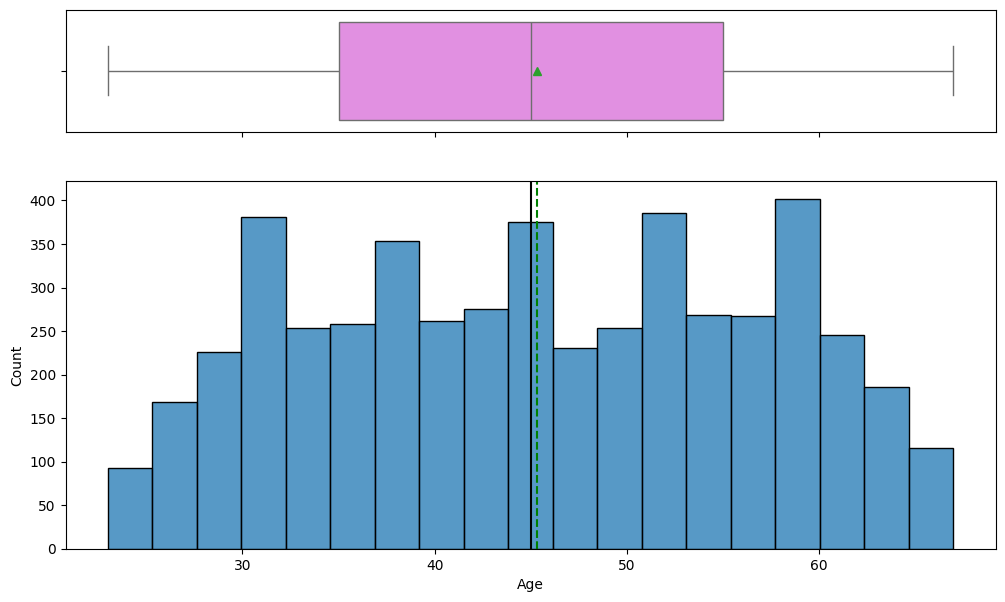

In [28]:
histogram_boxplot(loan,'Age')


The min is 23 , max is 67 , Average is 45 Years old - Data seems is slightly fitting a uniform distribution.
The maximum number of clients is within the 58-60 years old range, there are also peak counts at 30-32, 38-40, 44-46 and 52-54 years old
There are no outliers observed.

Experience

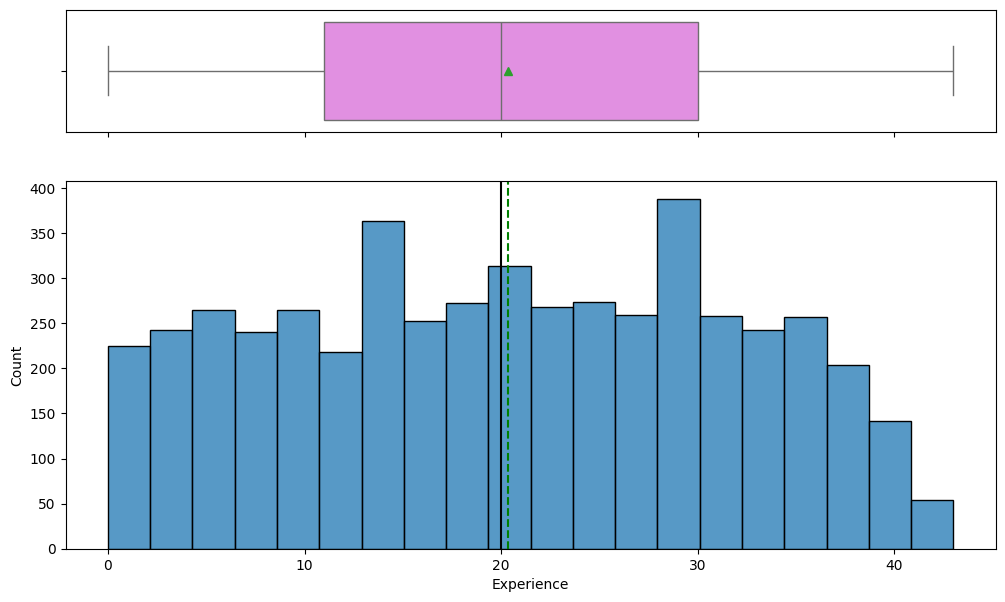

In [29]:
histogram_boxplot(loan,'Experience')

The min Experience is 0 years, the max is 43 and the mean is approximatly 20 years.
The data is almost fitting a uniform distribution with peaks at 12-14 years and 28-30 years
There are no outliers observed

Income

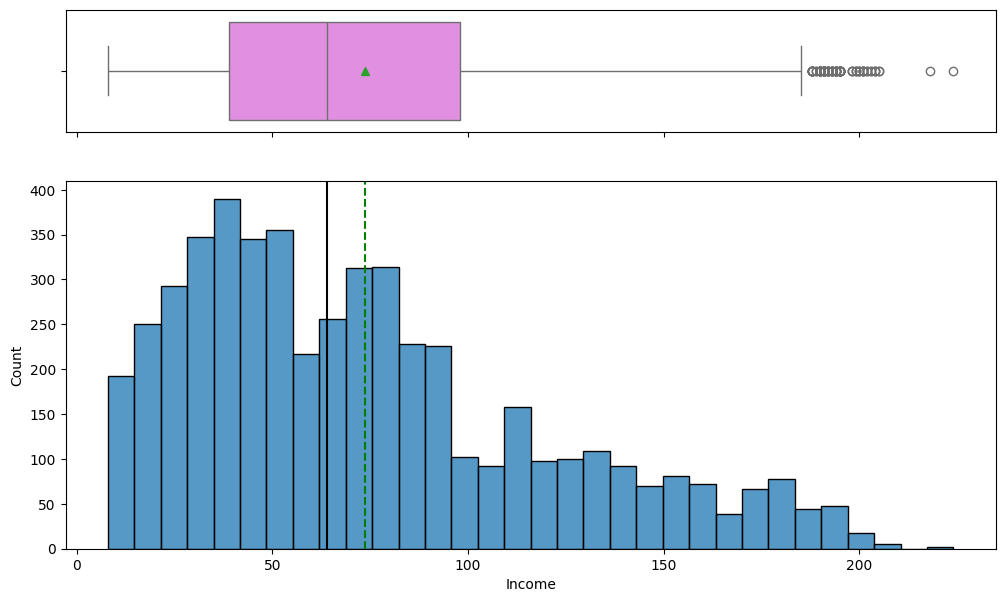

In [30]:
histogram_boxplot(loan,'Income')

The min Income is USD 46k, max is USD 224K and average is USD 64K - Dataset is right skewed
There is a number of outliers, yet they seem consistent with the data hence no action is required for outlier treatment

CCAvg

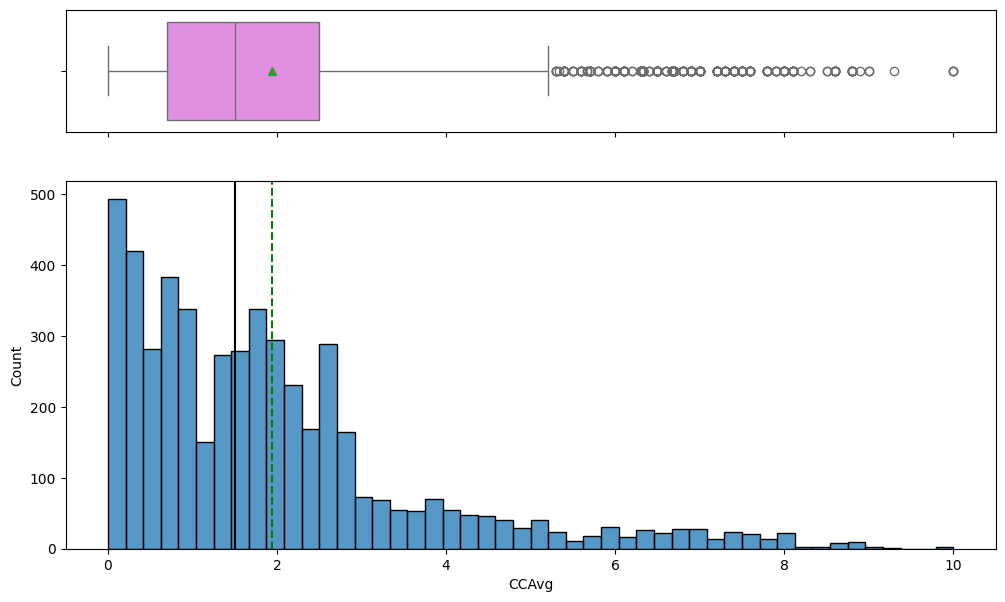

In [31]:
histogram_boxplot(loan,'CCAvg')

The min CCAvg is USD 0k (which can be reflecting customers who do not own credit cards), max is USD 1.9K and average is approx USD 1.9K
Dataset is right skewed with a number of outliers that seem homogenous with the data, hence no action required for the outliers

Mortgage


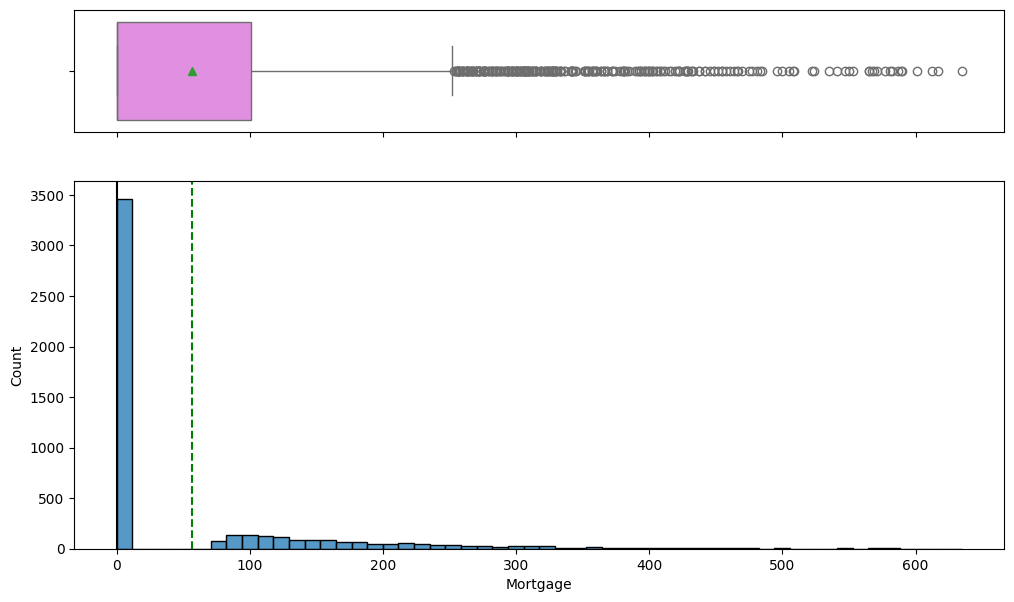

In [32]:
histogram_boxplot(loan,'Mortgage')

The min Mortgage is USD 0k, max is USD 635K and average is USD 0K - Dataset heavily right skewed
To visualize better, we will separate the USD 0k mortgage from the > USD 0K mortgage and plot the data again

In [33]:
#extracting the customers with mortgage values > 0
mortgage = loan[loan['Mortgage']>0]
print(f'There are {len(mortgage)} customers under mortgage and forms {round((len(mortgage)/5000)*100)}% of the dataset')

There are 1538 customers under mortgage and forms 31% of the dataset


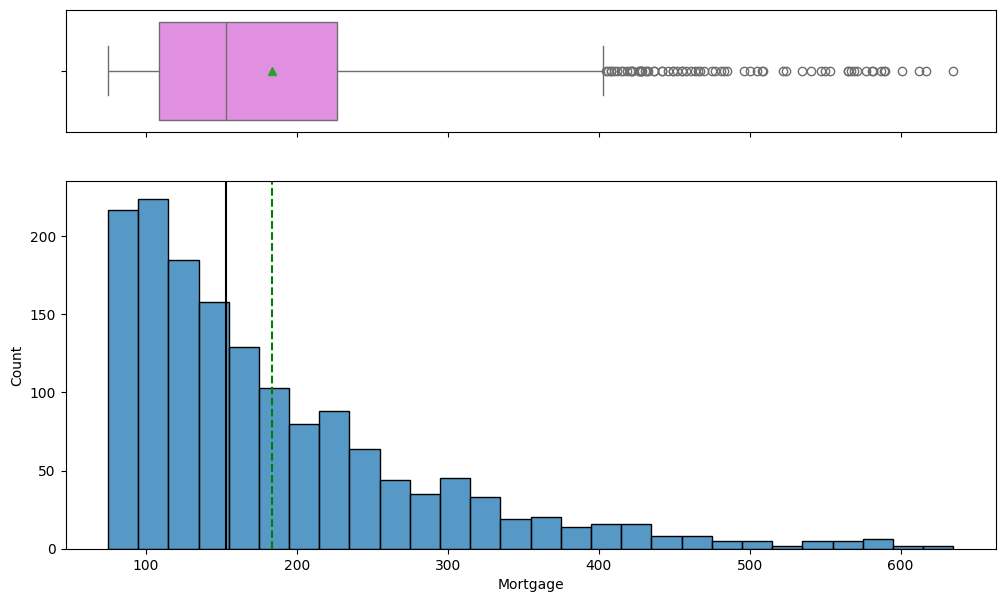

In [34]:
#plotting the mortgage of the customers
histogram_boxplot(mortgage,'Mortgage')

The mortgage distibution of the customers under mortgage is right skewed with a minimum value of approx 99K to max value of 635K and mean value between USD 180-200K .


Visualizing the categorical data
From the 5 point summary, it is observed that Zip codes, Family size, Education, Personal_Loan, CD_Account, Online and CreditCard are categorical in nature, hence we will define and apply a function to plot a labelled barplot for each variable

In [35]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

Zip codes_Cities
Very small scale in the vertical barplot hence, we plot the cities on a horizontal count plot

<Axes: xlabel='count', ylabel='City'>

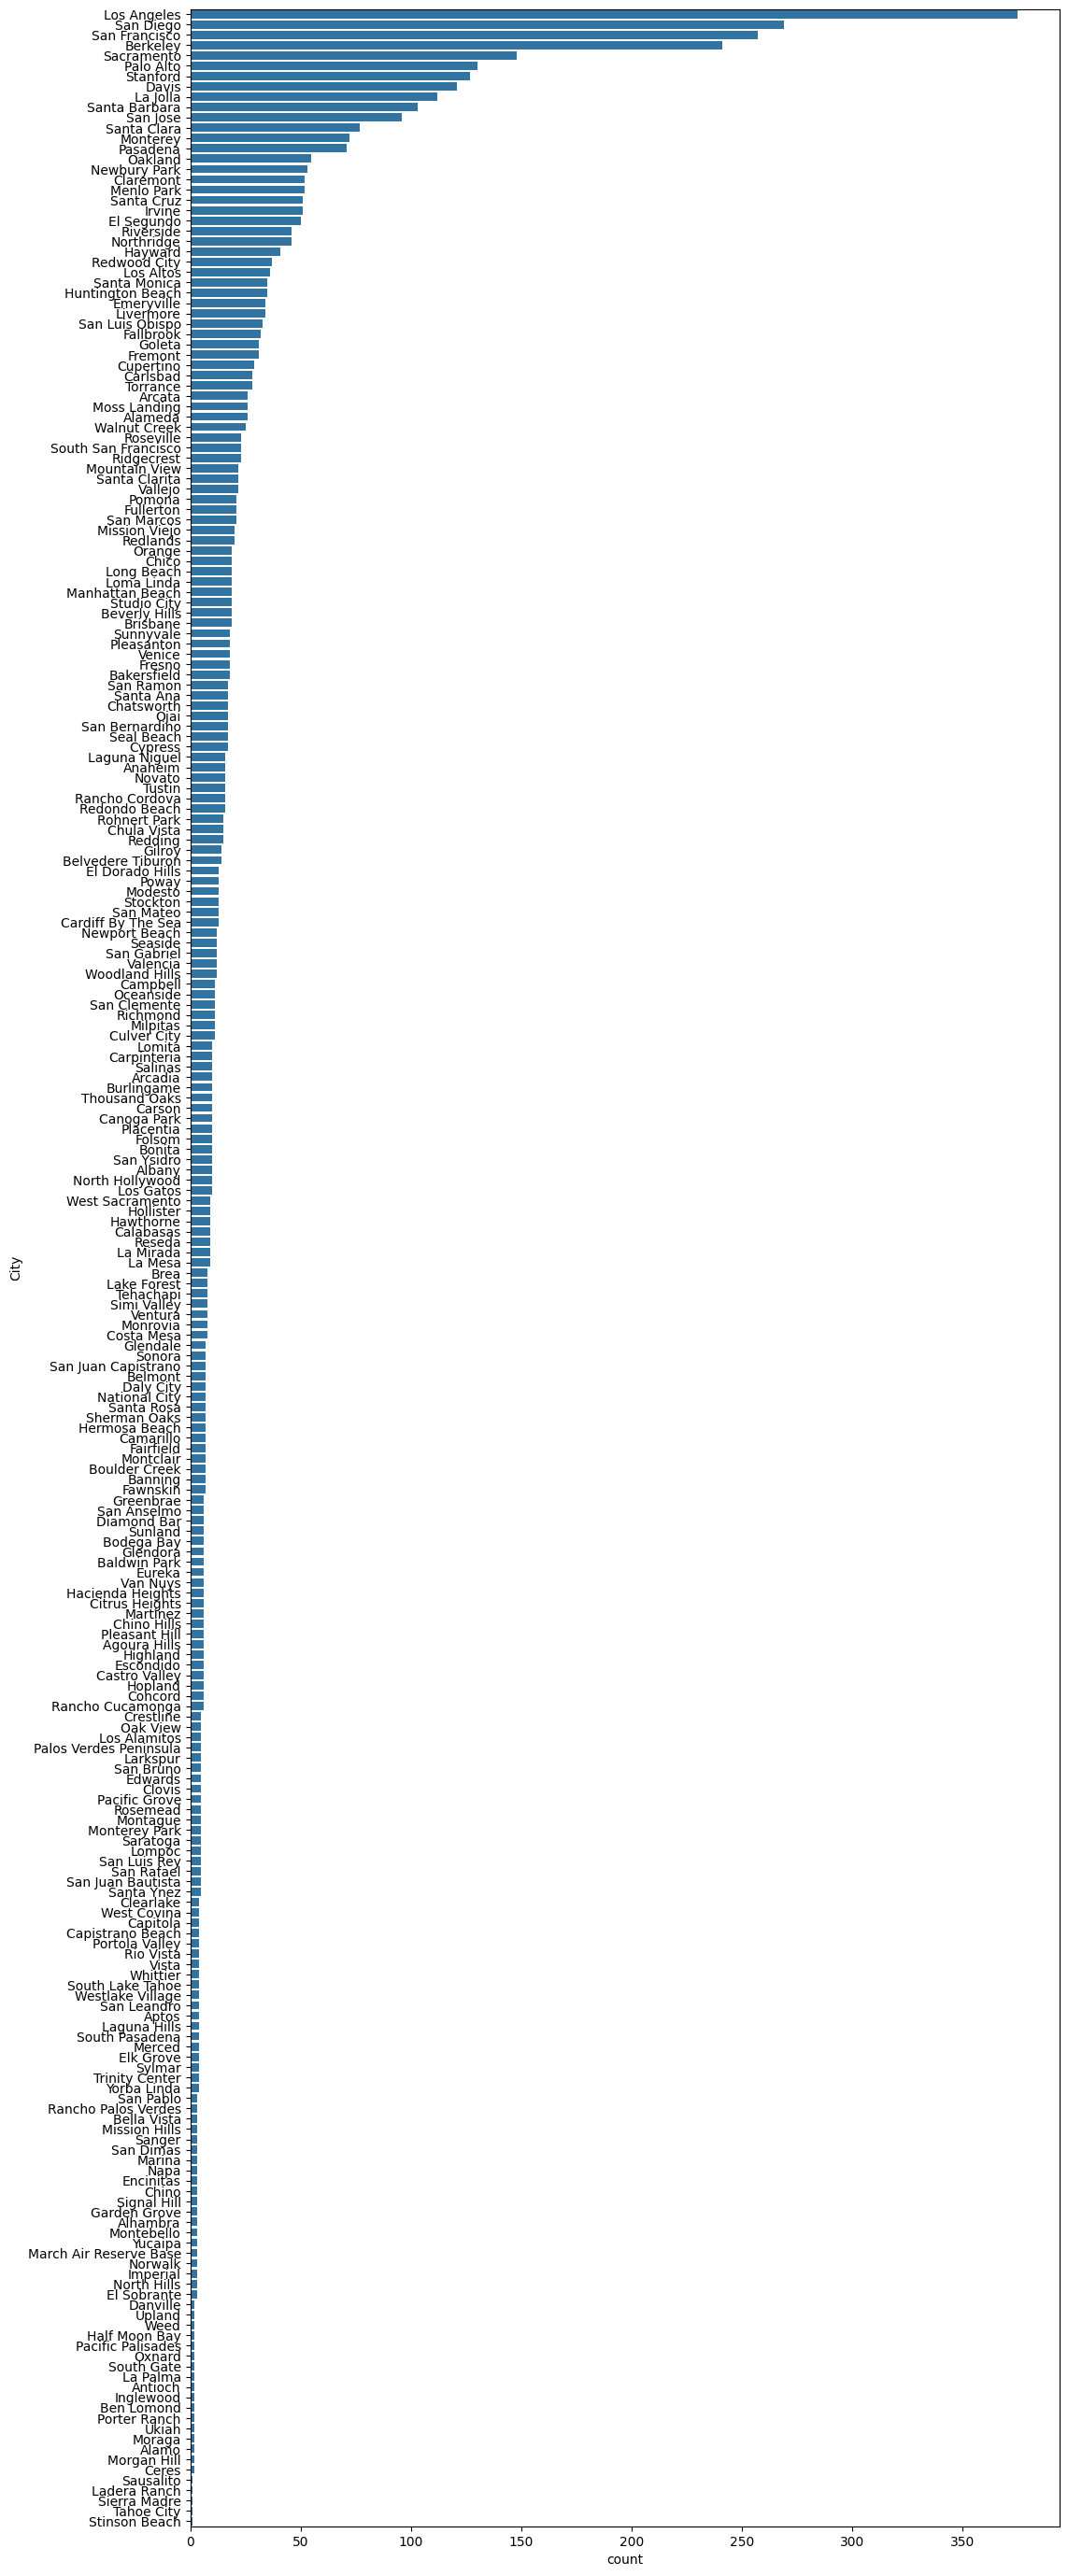

In [36]:
plt.figure(figsize=(12,35))
sns.countplot(data=loan, y='City', order=loan['City'].value_counts().index)

Approx. 25.8% of the customers reside in Los Angeles, San Diego, San Fransisco, Berkeley and Sacramento (these are the top 5 cities) with the top city is Los Angeles where 7.5% of the customers reside.

City	No. of customers
Los Angeles| 375| San Diego | 269| San Francisco| 257| Berkeley | 241| Sacramento | 148|

Family size

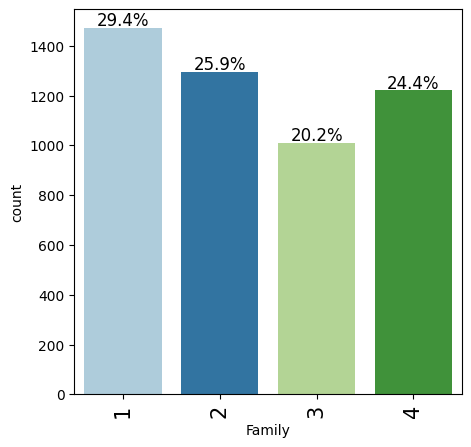

In [38]:
labeled_barplot(loan,'Family',perc=True)

Education

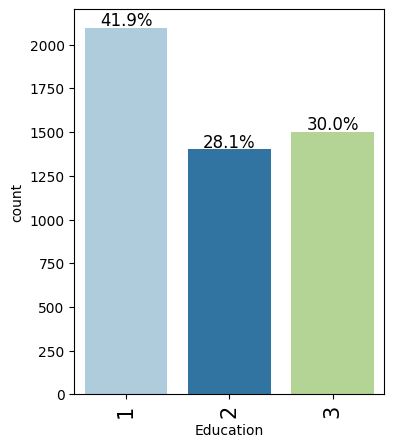

In [39]:
labeled_barplot(loan,'Education',perc=True)

Personal_Loan


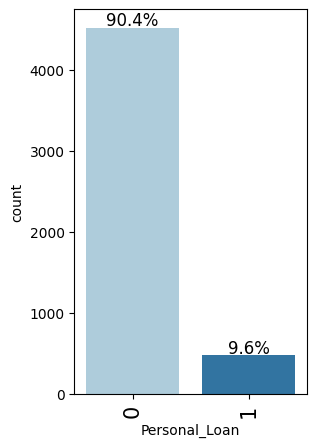

In [40]:
labeled_barplot(loan,'Personal_Loan',perc=True)

90.4% of customers Did not accept a loan
9.6% of customers accepted a loan


CD_Account


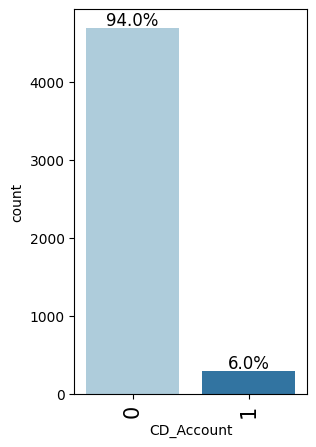

In [41]:
labeled_barplot(loan,'CD_Account',perc=True)

94% of customers Do Not have a CD_Account
6% only have a CD_Account


Online


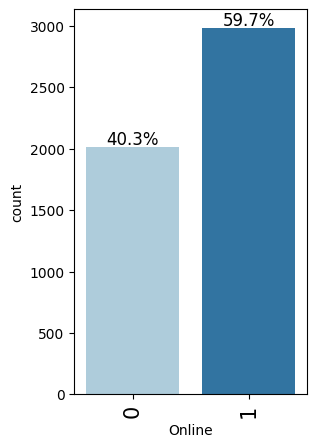

In [42]:
labeled_barplot(loan,'Online',perc=True)

59.7% of customers use the online banking services
40.3% of customers do not use the online banking services

CreditCard


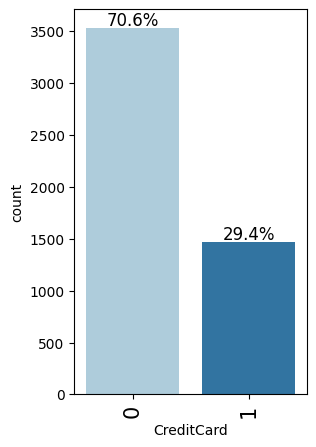

In [43]:
labeled_barplot(loan,'CreditCard',perc=True)

70.6% of customers do not use a credit card issued by a different bank
29.4% of customers use a credit card issued by a different bank


2. Bivariate analysis
We start with a simple pair plot to view if there is correlation between the data set variables



In [44]:
plt.figure(figsize=(15,15))
# sns.pairplot(loan, diag_kind='kde')
sns.pairplot(loan, hue="Personal_Loan")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Observations:

The orange points represent customers who accepted a personal loan, while the blue points represent those who did not.
From the univariate analysis of the personal loan dataset, it was noted that only 9.6% of the customers accepted the loan. This aligns with the pair plot, where the majority of points are blue.
There is a strong linear correlation between Age and Experience.
A slight correlation is observed between Income and CCAvg (Credit Card Average).
A high concentration of customers who accepted a personal loan can be seen among those with:
Higher income levels (starting at approximately USD 100K and above).
Higher CCAvg (starting at approximately USD 3K and above).
Higher mortgage values (starting at approximately USD 300K and above).
CD accounts.
Credit cards issued by other banks.
Families with 3 or 4 members.
Education levels 2 (graduate) or 3 (advanced/professional).
Thus, we can expect the above variables to have a medium to high predictive power in classification models.



<Axes: >

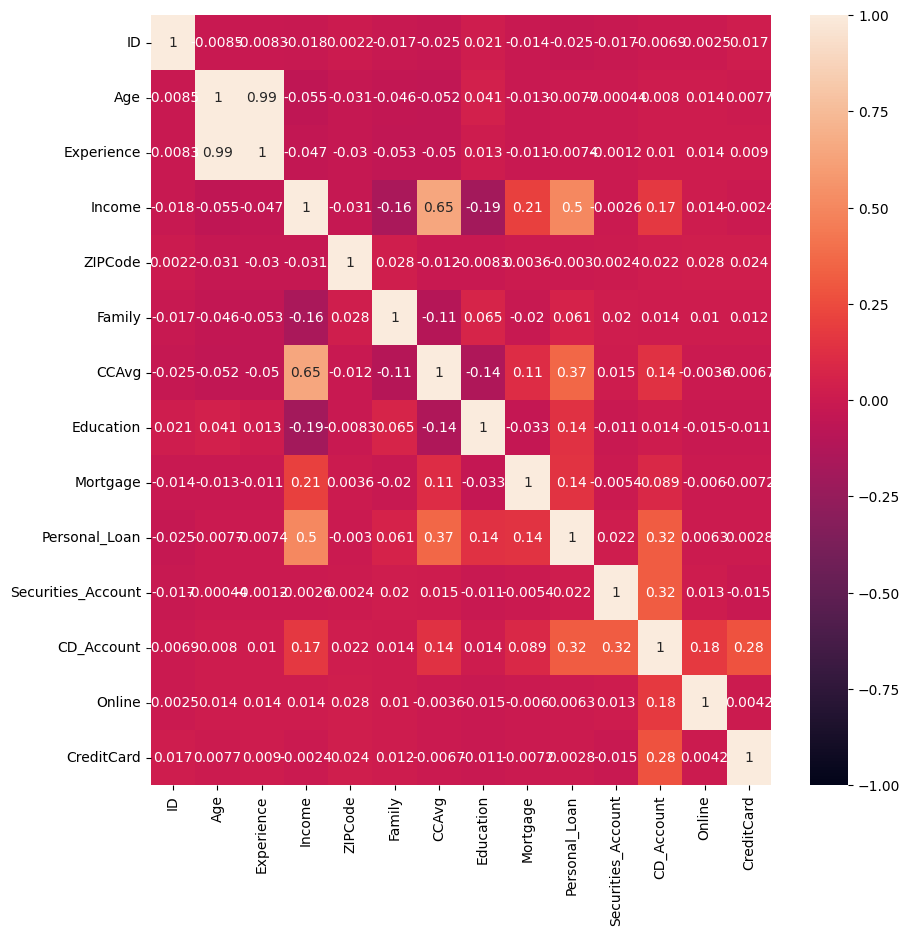

In [45]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(),vmax=1,vmin=-1,annot=True)

The correlation heatmap confirms the relationships observed in the pair plot, showing that:

The correlation between Age and Experience is very strong (value = 0.98).
The correlation between Income and CCAvg is moderate (value = 0.65).
All other correlation values are relative



Observing the variables effect on the target variable
a. Plotting the target VS distribution of numerical variables
Let us plot the target VS distribution of the variables to understand further our data set prior building the model



In [46]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [47]:
df1.columns

Index(['Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard', 'City', 'State'],
      dtype='object')

Age VS Personal_Loan

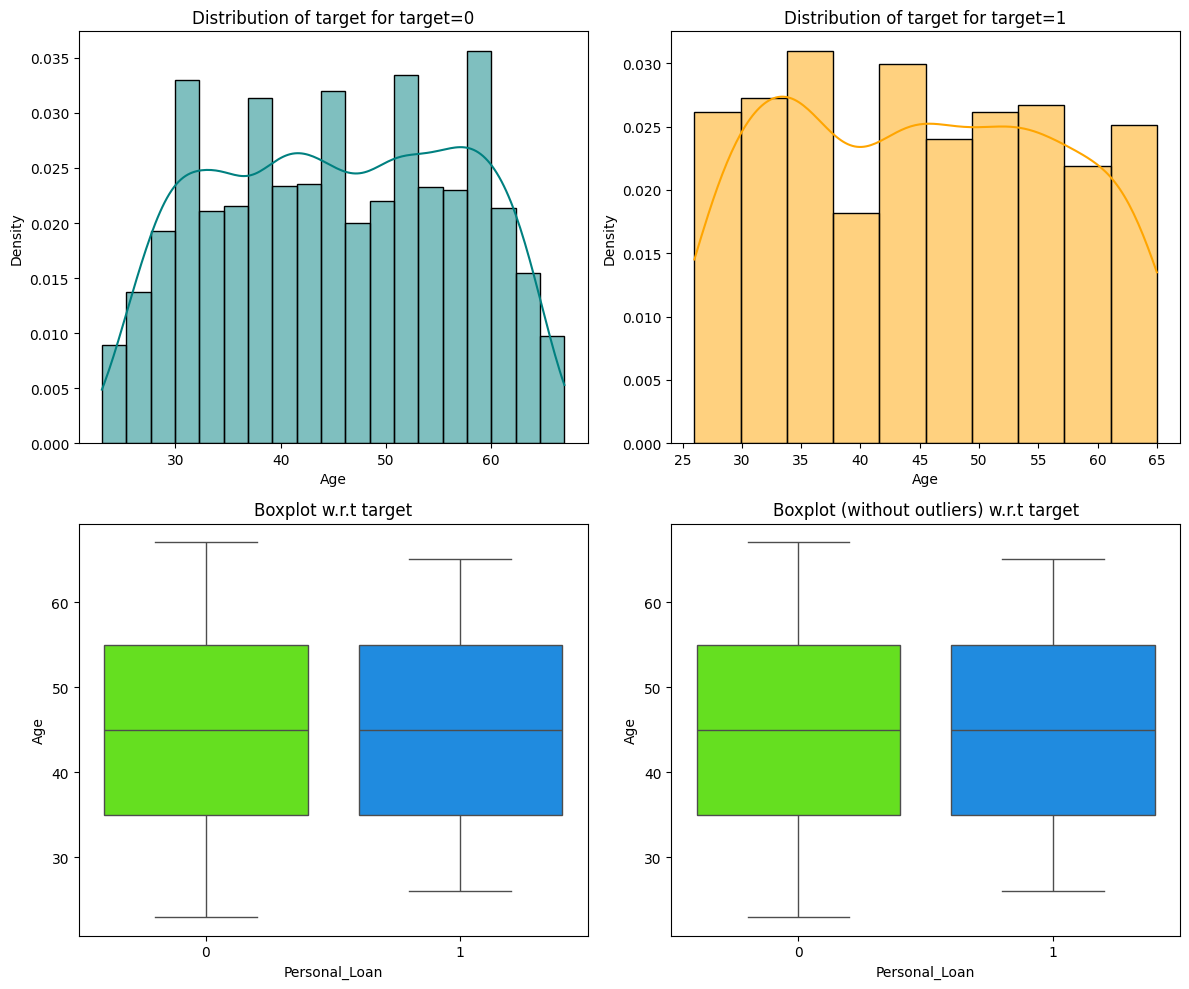

In [48]:
distribution_plot_wrt_target(df1,'Age','Personal_Loan')

It was observed that the average age of customers, whether they accepted or declined personal loans, is close to 45 years. As anticipated from the pair plot, Age shows no significant relationship with the target variable, indicating minimal predictive power.



Experience VS Personal_Loan


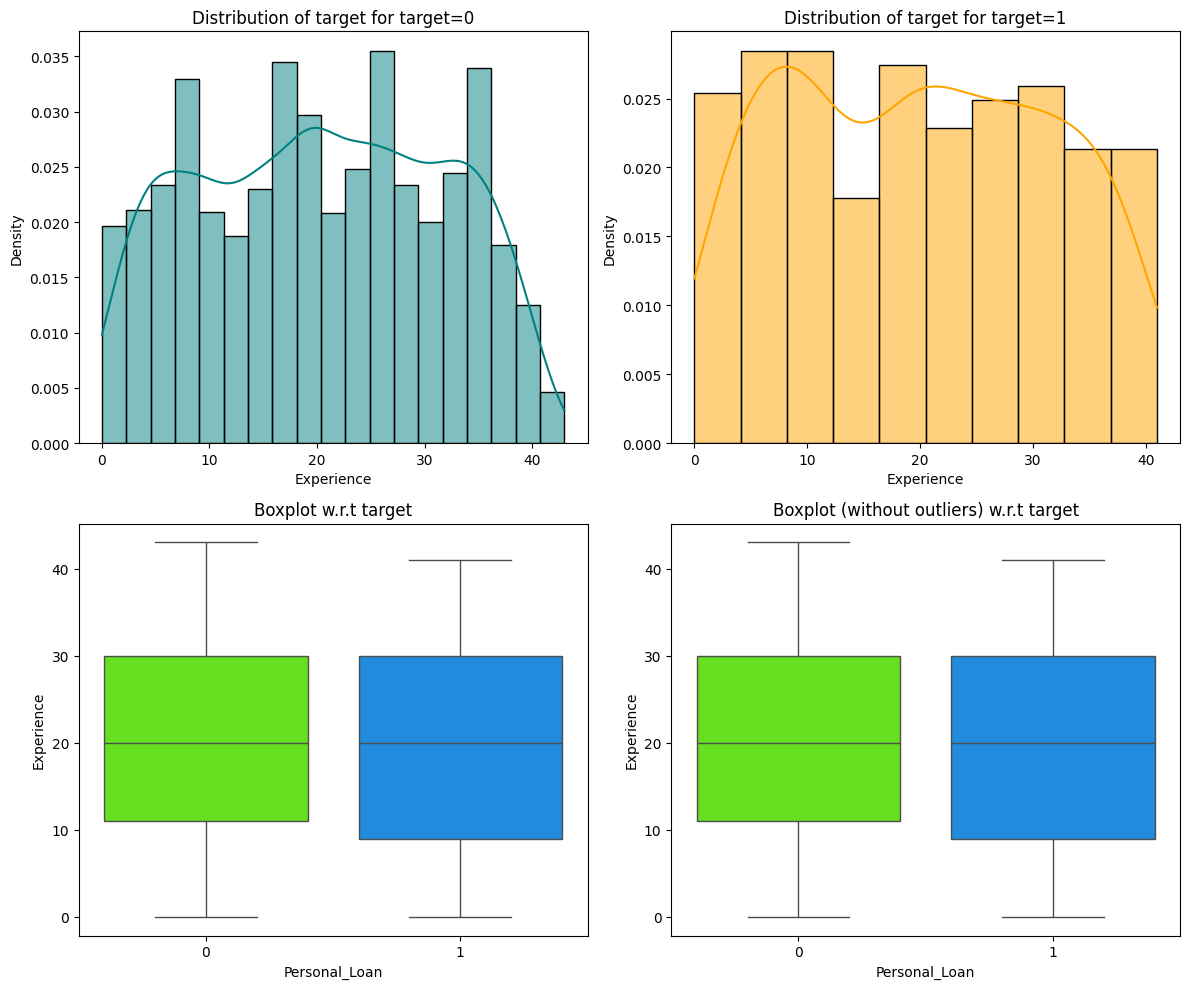

In [49]:
distribution_plot_wrt_target(df1,'Experience','Personal_Loan')

The average Experience for customers, whether they accepted or declined personal loans, is observed to be around 20 years. As indicated by the pair plot, Experience shows no meaningful relationship with the target variable, and thus has minimal predictive power.



Income VS Personal_Loan


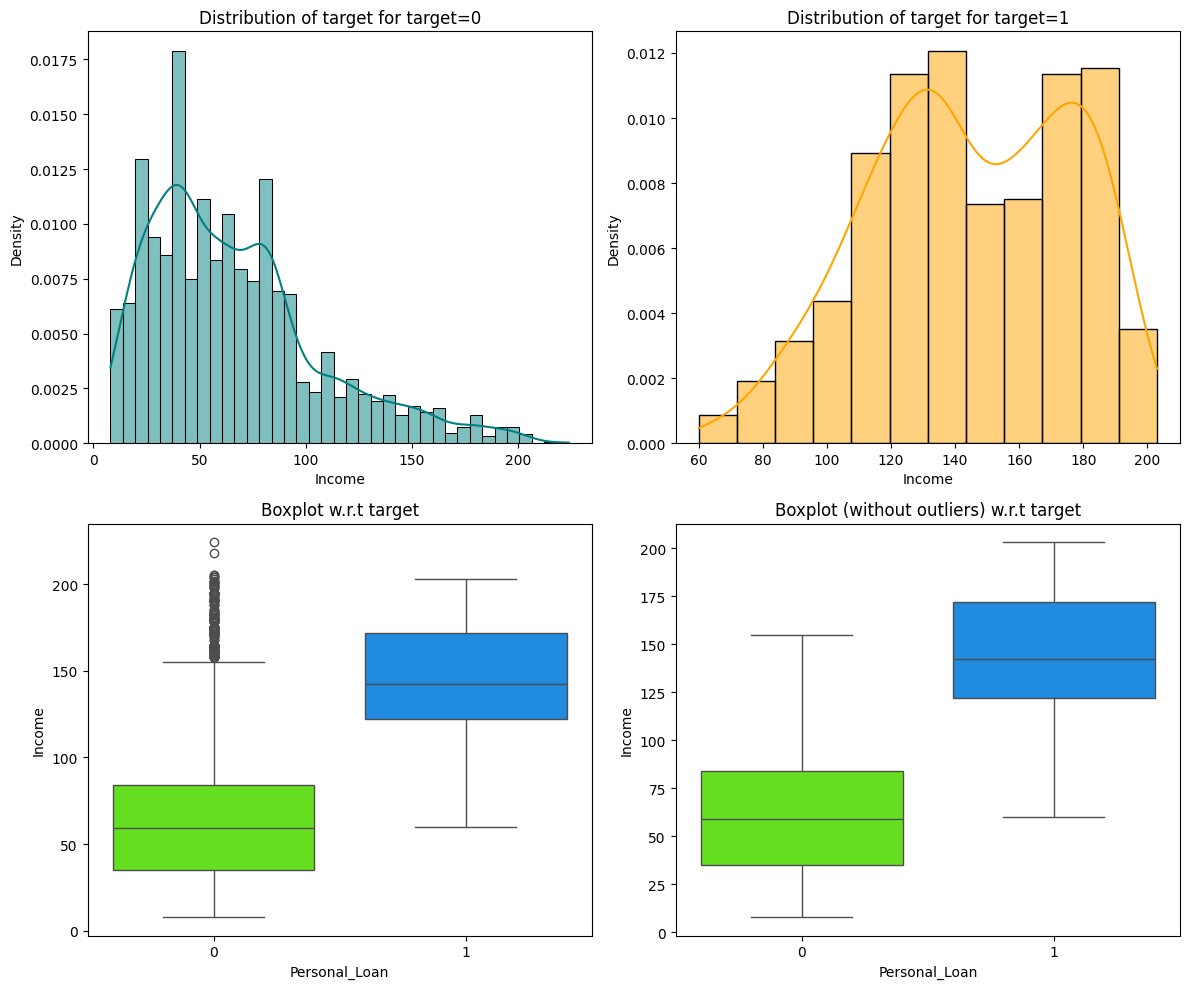

In [50]:
distribution_plot_wrt_target(df1,'Income','Personal_Loan')

As anticipated, the Income variable shows a significant difference between customers who accepted and those who did not accept the personal loan. The average income for customers who declined the loan is approximately USD 65K, while for those who accepted it, the average income is around USD 145K. This indicates that a customer's income level has a strong influence on their decision to accept a personal loan – the higher the income, the more likely they are to accept the loan.



Mortgage VS Personal_Loan


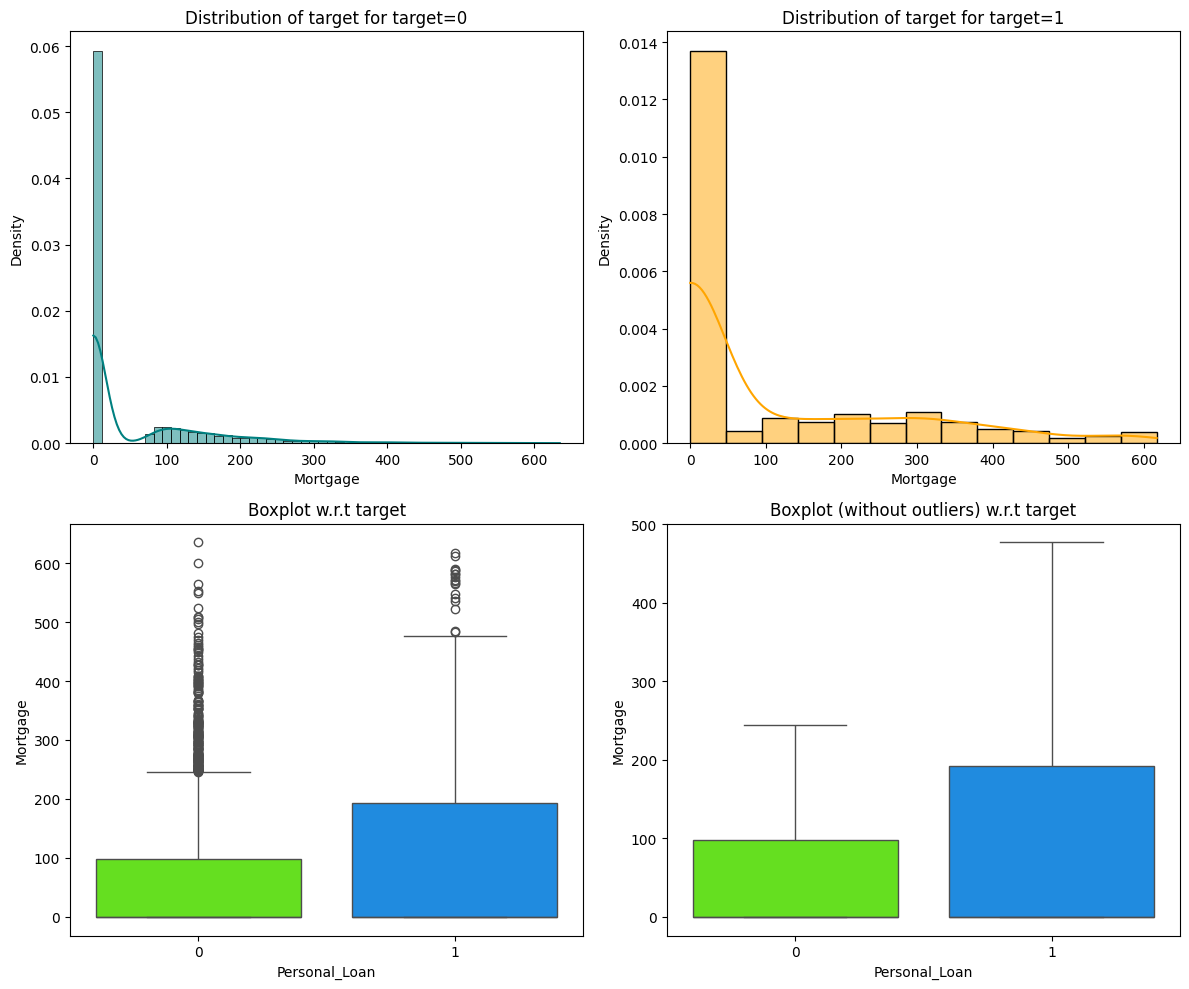

In [51]:
distribution_plot_wrt_target(df1,'Mortgage','Personal_Loan')

It is observed that customers with a mortgage are more likely to accept a personal loan. However, since the distribution of this variable is heavily right-skewed due to the large number of customers without a mortgage, we will focus on plotting the distribution for customers who are paying a mortgage, consolidated in the mortgage DataFrame. This approach will provide clearer insights into the average mortgage value for customers who accepted versus those who did not accept a personal loan.



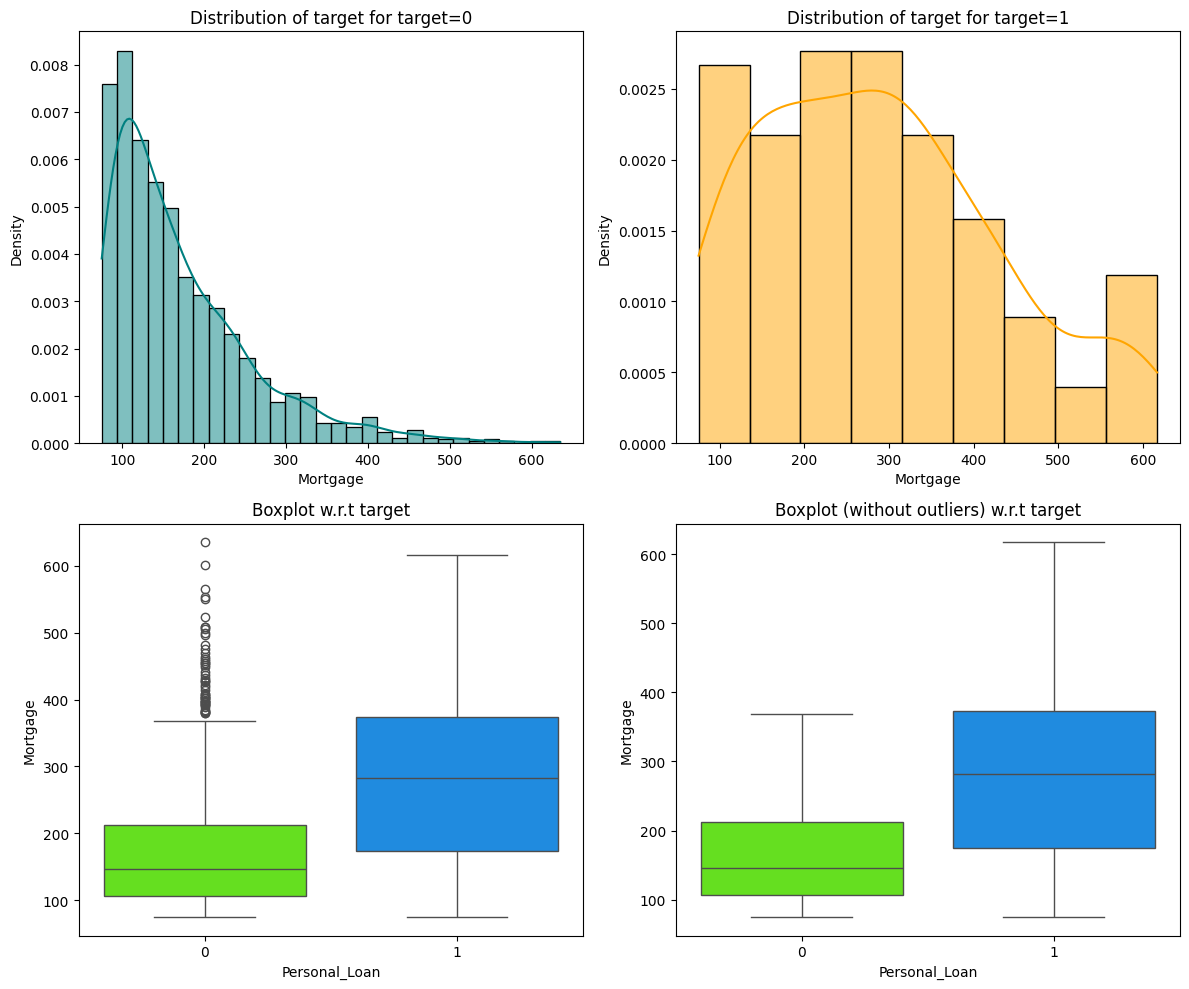

In [52]:
distribution_plot_wrt_target(mortgage,'Mortgage','Personal_Loan')

It is observed that the average mortgage value for customers who did not accept a personal loan is approximately USD 150K, significantly lower than the average of around USD 290K for those who accepted the loan. Therefore, as the mortgage value increases, customers are more likely to accept a personal loan.



CCAvg VS Personal_Loan


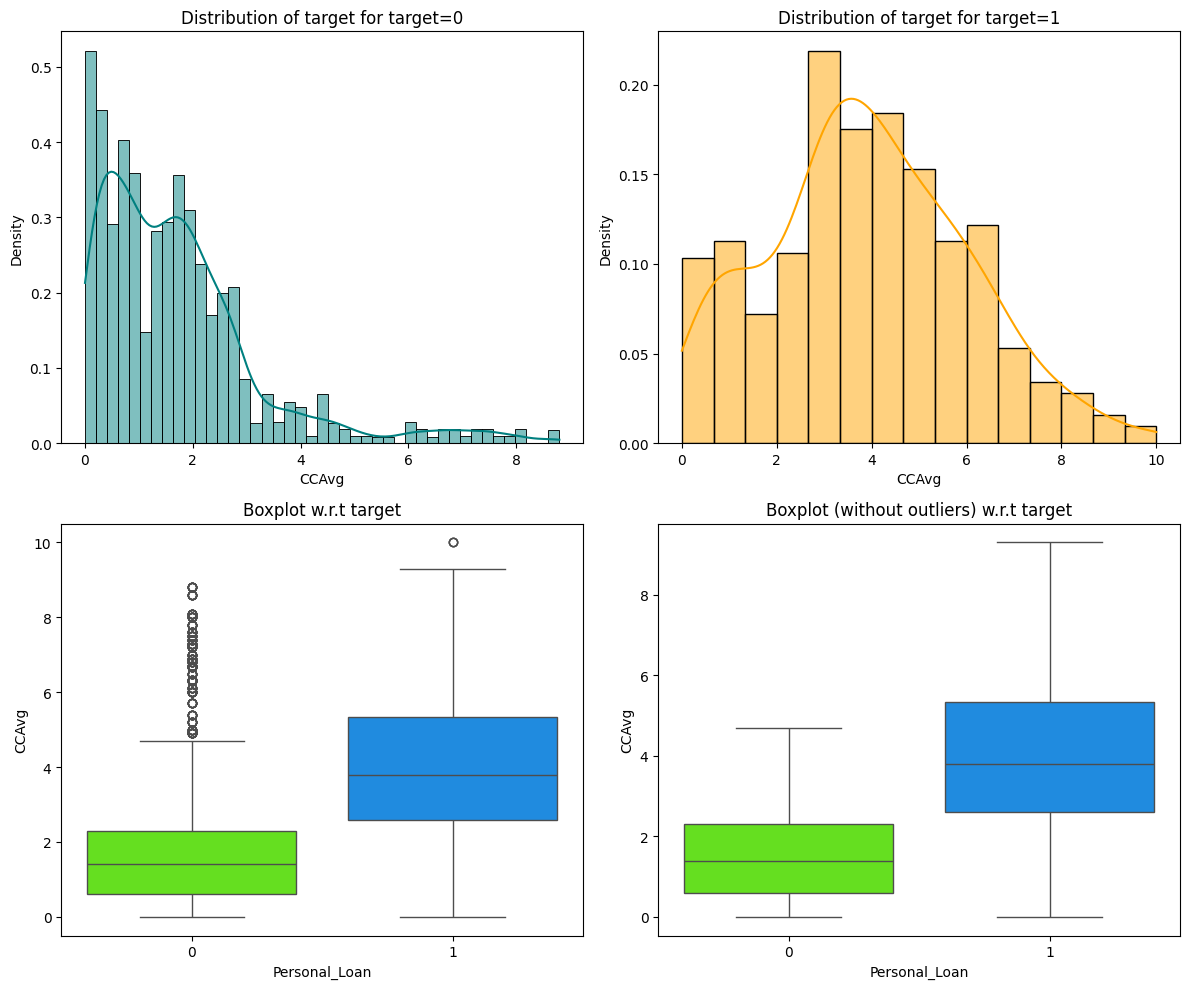

In [53]:
distribution_plot_wrt_target(loan,'CCAvg','Personal_Loan')

It is observed that the average CCAvg (Credit Card Average) for customers who did not accept a personal loan is around USD 1.6K, significantly lower than the average of approximately USD 4K for those who accepted the loan. This suggests that customers who accept personal loans tend to spend more on a monthly basis.



b. Plotting the target VS distribution of categorical variables


In [54]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 6))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

Family VS Personal_Loan


Personal_Loan     0    1   All
Family                        
All            4520  480  5000
4              1088  134  1222
3               877  133  1010
1              1365  107  1472
2              1190  106  1296
------------------------------------------------------------------------------------------------------------------------


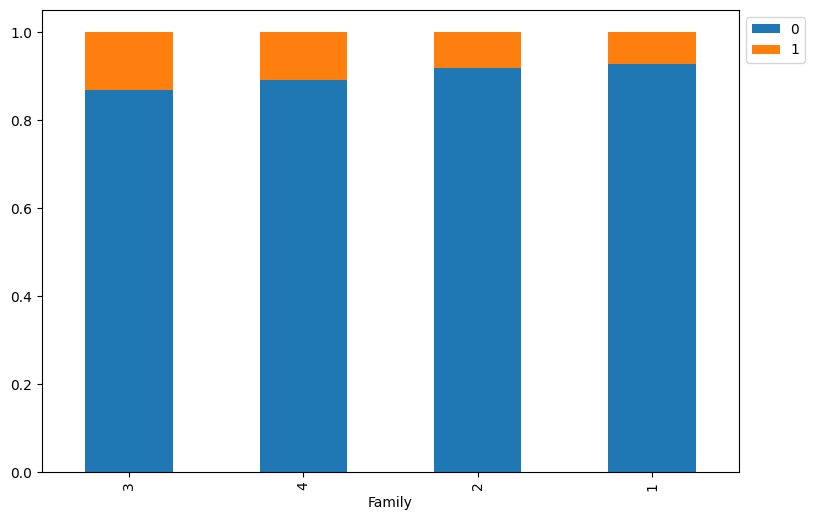

In [55]:
stacked_barplot(df1,'Family','Personal_Loan')

It is observed that families with 3 or 4 members are more likely to accept a personal loan. Therefore, as family size increases, customers tend to be more inclined to accept personal loans.



Education VS Personal_Loan


Personal_Loan     0    1   All
Education                     
All            4520  480  5000
3              1296  205  1501
2              1221  182  1403
1              2003   93  2096
------------------------------------------------------------------------------------------------------------------------


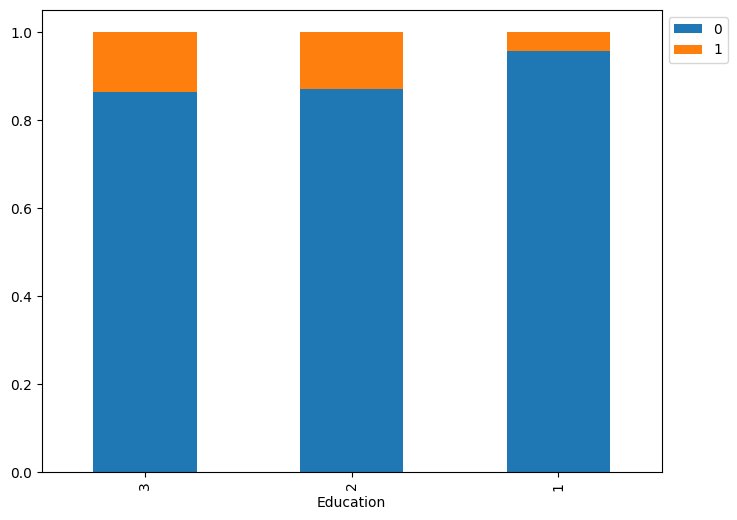

In [56]:
stacked_barplot(df1,'Education','Personal_Loan')

It is observed that customers with education levels 2 and 3 are more likely to accept a personal loan compared to those with education level 1, with the highest acceptance rate seen among customers with education level 3.



Securities_Account VS Personal_Loan


Personal_Loan          0    1   All
Securities_Account                 
All                 4520  480  5000
0                   4058  420  4478
1                    462   60   522
------------------------------------------------------------------------------------------------------------------------


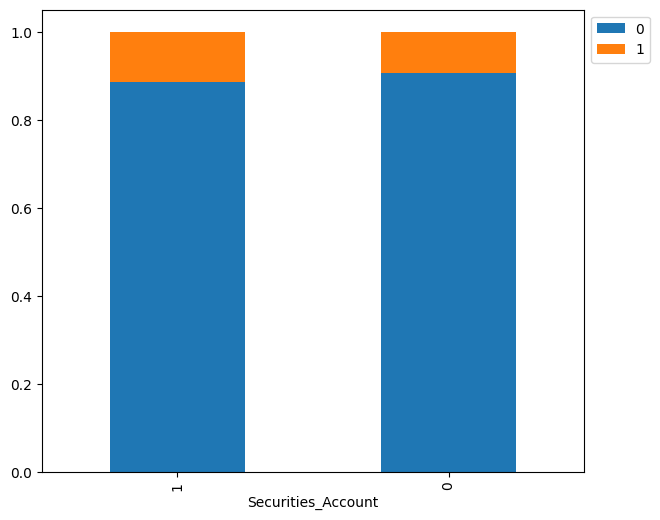

In [57]:
stacked_barplot(df1,'Securities_Account','Personal_Loan')

It is observed that customers with Security account are more willing to accept a personal loan



CD_Account VS Personal_Loan


Personal_Loan     0    1   All
CD_Account                    
All            4520  480  5000
0              4358  340  4698
1               162  140   302
------------------------------------------------------------------------------------------------------------------------


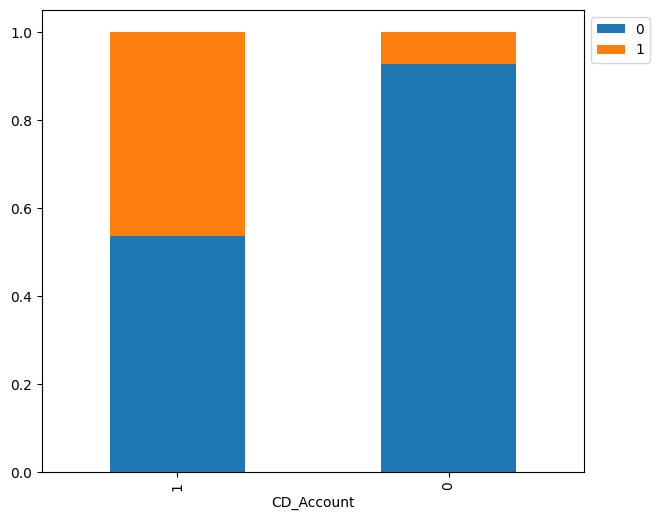

In [58]:
stacked_barplot(loan,'CD_Account','Personal_Loan')

It is observed that customers with CD_account are more willing to accept a personal loan



Online VS Personal_Loan


Personal_Loan     0    1   All
Online                        
All            4520  480  5000
1              2693  291  2984
0              1827  189  2016
------------------------------------------------------------------------------------------------------------------------


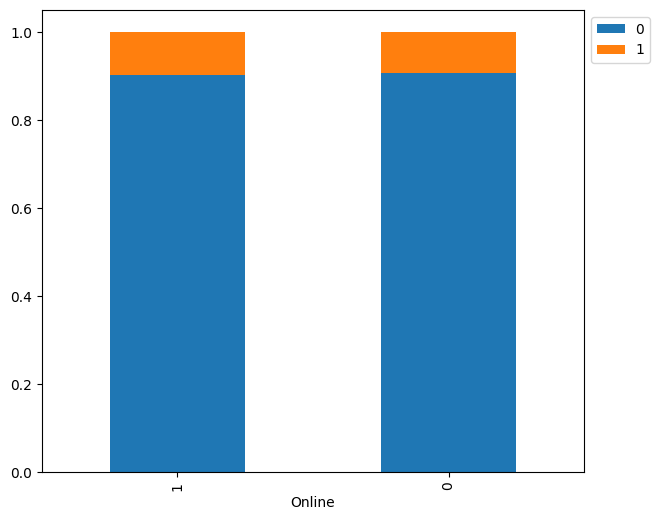

In [59]:
stacked_barplot(df1,'Online','Personal_Loan')

It is observed that customers who use iternet banking services and who do not use internet banking services are almost equally likely to accept personal loans


CreditCard VS Personal_Loan


Personal_Loan     0    1   All
CreditCard                    
All            4520  480  5000
0              3193  337  3530
1              1327  143  1470
------------------------------------------------------------------------------------------------------------------------


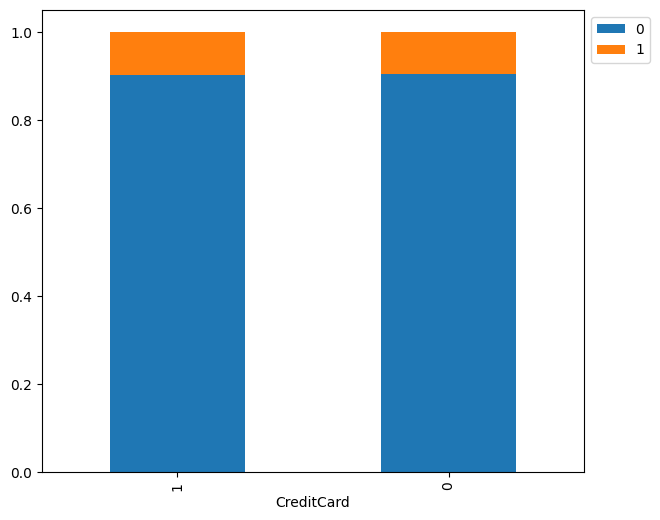

In [60]:
stacked_barplot(df1,'CreditCard','Personal_Loan')

It is observed that customers who use credit cards issued by other banks and those who do not are almost equally likely to accept personal loans


City VS Personal_Loan
For improved visualization, we set a threshold to highlight the most common cities among the customers, grouping the less common ones under "Others." This newly created DataFrame will be used solely to visualize how the most common cities relate to personal loan acceptance and will not be used during the modeling stage.



In [61]:
#assigning the threshold
cities = df1['City'].value_counts()
threshold = 50
cities[cities.values >= threshold]

,count
City,
Los Angeles,375
San Diego,269
San Francisco,257
Berkeley,241
Sacramento,148
Palo Alto,130
Stanford,127
Davis,121
La Jolla,112


In [62]:
# the threshhold of 50 seems alright, hence we extract the cities names
cities_list = cities[cities.values >= threshold].index.tolist()
print("Cities names taken into consideration:", len(cities_list), cities_list)

Cities names taken into consideration: 21 ['Los Angeles', 'San Diego', 'San Francisco', 'Berkeley', 'Sacramento', 'Palo Alto', 'Stanford', 'Davis', 'La Jolla', 'Santa Barbara', 'San Jose', 'Santa Clara', 'Irvine', 'Monterey', 'Pasadena', 'Oakland', 'Newbury Park', 'Menlo Park', 'Claremont', 'Santa Cruz', 'El Segundo']


In [63]:
#we create a copy of the data frame as we are doing this transformation only for better visualization
df2 = df1.copy()

In [64]:
df2['City'] = df2['City'].apply(lambda x:x if x in cities_list else 'others')

In [65]:
# function to plot horizontal stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="barh", stacked=True, figsize=(count + 5, 6))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

Personal_Loan     0    1   All
City                          
All            4520  480  5000
others         2187  228  2415
Los Angeles     337   38   375
Berkeley        214   27   241
San Diego       248   21   269
San Francisco   238   19   257
Palo Alto       114   16   130
La Jolla         97   15   112
Stanford        114   13   127
Sacramento      135   13   148
Santa Clara      65   12    77
San Jose         85   11    96
Pasadena         61   10    71
Irvine           63   10    73
Santa Barbara    95    8   103
Santa Cruz       44    7    51
Monterey         66    6    72
Davis           115    6   121
Oakland          50    5    55
El Segundo       45    5    50
Claremont        48    4    52
Menlo Park       48    4    52
Newbury Park     51    2    53
------------------------------------------------------------------------------------------------------------------------


<Figure size 1000x4000 with 0 Axes>

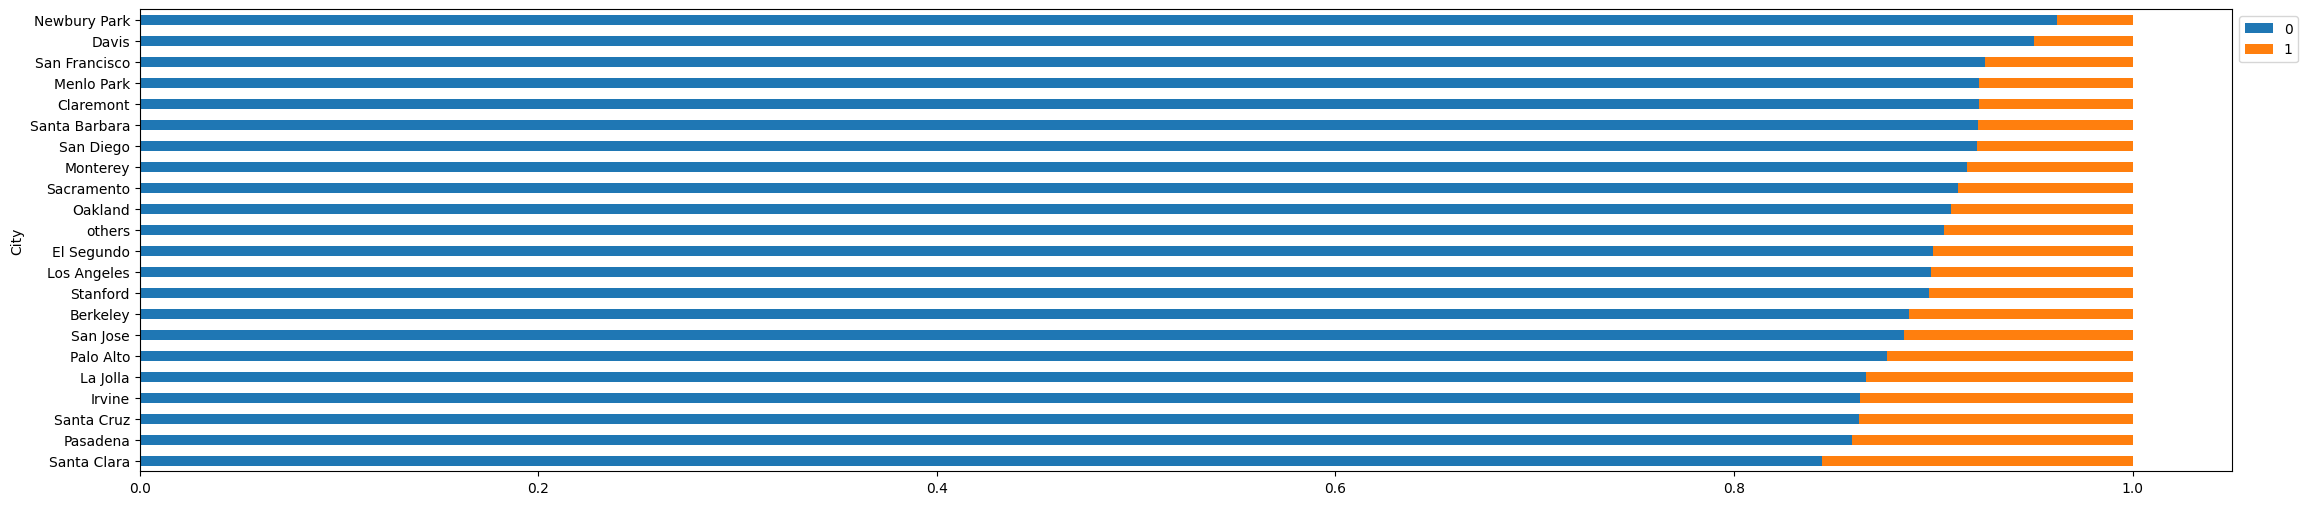

In [66]:
#plotting a horizonal stacked bar plot
plt.figure(figsize=(10,40))
stacked_barplot(df2,'City','Personal_Loan')

It is observed that Santa Clara has the highest proportion of customers willing to accept personal loans, followed by Pasadena and Irvine.



State VS Personal_Loan


Personal_Loan     0    1   All
State                         
CA             4508  479  4987
All            4514  479  4993
BC                6    0     6
------------------------------------------------------------------------------------------------------------------------


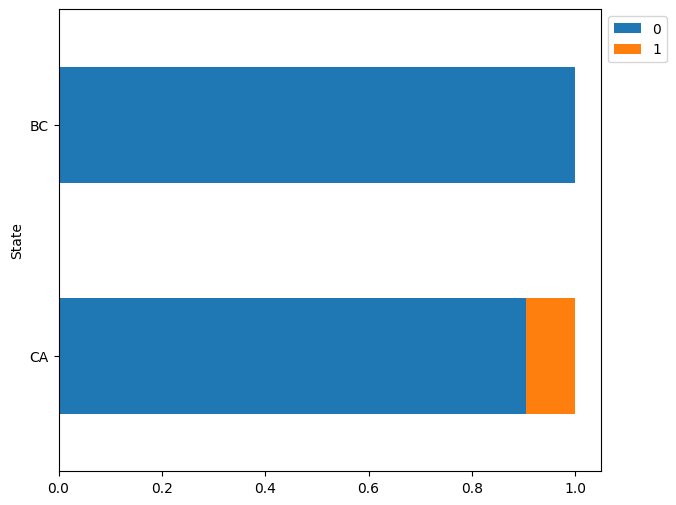

In [67]:
stacked_barplot(df2,'State','Personal_Loan')

The customers residing in CA are more willing to accept personal loans than the customers in BC


Key Insights based on EDA
The Five point summary for all the variables including the city and state added columns:



In [68]:
df2.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,5000.0,NaN,NaN,NaN,45.3384,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,NaN,NaN,NaN,20.3276,11.253035,0.0,11.0,20.0,30.0,43.0
Income,5000.0,NaN,NaN,NaN,73.7742,46.033729,8.0,39.0,64.0,98.0,224.0
ZIPCode,5000.0,NaN,NaN,NaN,93169.257,1759.455086,90005.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,NaN,NaN,NaN,2.3964,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,NaN,NaN,NaN,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,NaN,NaN,NaN,1.881,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,NaN,NaN,NaN,56.4988,101.713802,0.0,0.0,0.0,101.0,635.0
Personal_Loan,5000.0,NaN,NaN,NaN,0.096,0.294621,0.0,0.0,0.0,0.0,1.0
Securities_Account,5000.0,NaN,NaN,NaN,0.1044,0.305809,0.0,0.0,0.0,0.0,1.0


Key Observations from Univariate Analysis:
Age: The minimum age is 23, the maximum is 67, and the average is 45 years old. The data appears to slightly resemble a uniform distribution.
Experience: The minimum experience is 0 years, the maximum is 43 years, with an average of approximately 20 years.
CCAvg: The minimum CCAvg is USD 0K (likely indicating customers without credit cards), the maximum is USD 1.9K, and the average is around USD 10K.
Mortgage: 69% of customers do not have a mortgage, while the remaining 31% have mortgages ranging from USD 99K to USD 635K, with an average value between USD 180K and USD 200K.
Top Cities: The five most common cities are Los Angeles, followed by San Diego, San Francisco, Berkeley, and Sacramento.
Top State: The majority of customers reside in California (CA).
Family Size: The most common family size is 1 (29.4%), followed by 2 (25.9%), 4 (24.4%), and 3 (20.2%).
Customer Education:
41.9% are undergraduates.
28.1% are graduates.
30.0% have advanced/professional education.
CD Account: 94% of customers do not have a CD account, while 6% do.
Online Banking: 40.3% of customers do not use online banking, while 59.7% do.
Credit Card: 70.6% of customers do not hold a credit card, while 29.4% do.
Personal Loan: 90.4% of customers did not accept a personal loan, while 9.6% did.
Key Insights and Observations from Multivariate Analysis:
Correlation Between Variables:
Age and Experience: A very high correlation (value = 0.98).
Income and CCAvg: A moderate correlation (value = 0.65).
All other correlation values are too small to be considered significant.
Effect of Variables on the Target Variable:
Income: Higher income increases the likelihood of accepting a personal loan.
Family Size: As family size grows, customers are more likely to accept a personal loan.
CCAvg: Higher monthly spending correlates with a higher likelihood of accepting a personal loan.
Education: Higher education levels correspond to an increased likelihood of accepting a personal loan.
Mortgage: Higher mortgage values increase the likelihood of accepting a personal loan.
City: Santa Clara shows the highest proportion of customers accepting personal loans, followed by Pasadena and Irvine.
State: Customers residing in California (CA) are more likely to accept personal loans.
Securities Account: Customers with a securities account are more likely to accept a personal loan.
CD Account: Customers with a CD account are more likely to accept a personal loan.
Online Banking: No observed effect on the target variable.
Age, Experience, Credit Card: No observed effect on the target variable.
Expected Target Dependencies:
Low Importance: Age, Experience, Credit Card, and Online Banking are expected to have low importance.
High to Medium Importance: Income, Family Size, CCAvg, Education, Mortgage, Securities Account, and CD Account are expected to have high to medium predictive power.


Data Preparation for modelling
Note! Earlier on in the code the below Data Pre-proccesing actions were applied:

ID column: dropped
Experience column: Negative values replaced by Median
ZIP Code Column: Split into City and state then dropped
Now we move on to Data preparation for modelling

1. Creating the dummy variables


In [69]:
df1.drop('ZIPCode', axis =1, inplace=True)

In [70]:
df1.columns

Index(['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education',
       'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account',
       'Online', 'CreditCard', 'City', 'State'],
      dtype='object')

In [71]:
df_model = pd.get_dummies(
    df1,
    columns=[
        "Education",
        "City",
        "State",
    ],
    drop_first=True,
)
df_model.head()

,Age,Experience,Income,Family,CCAvg,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Education_2,Education_3,City_Alameda,City_Alamo,City_Albany,City_Alhambra,City_Anaheim,City_Antioch,City_Aptos,City_Arcadia,City_Arcata,City_Bakersfield,City_Baldwin Park,City_Banning,City_Bella Vista,City_Belmont,City_Belvedere Tiburon,City_Ben Lomond,City_Berkeley,City_Beverly Hills,City_Bodega Bay,City_Bonita,City_Boulder Creek,City_Brea,City_Brisbane,City_Burlingame,City_Calabasas,City_Camarillo,City_Campbell,City_Canoga Park,City_Capistrano Beach,City_Capitola,City_Cardiff By The Sea,City_Carlsbad,City_Carpinteria,City_Carson,City_Castro Valley,City_Ceres,City_Chatsworth,City_Chico,City_Chino,City_Chino Hills,City_Chula Vista,City_Citrus Heights,City_Claremont,City_Clearlake,City_Clovis,City_Concord,City_Costa Mesa,City_Crestline,City_Culver City,City_Cupertino,City_Cypress,City_Daly City,City_Danville,City_Davis,City_Diamond Bar,City_Edwards,City_El Dorado Hills,City_El Segundo,City_El Sobrante,City_Elk Grove,City_Emeryville,City_Encinitas,City_Escondido,City_Eureka,City_Fairfield,City_Fallbrook,City_Fawnskin,City_Folsom,City_Fremont,City_Fresno,City_Fullerton,City_Garden Grove,City_Gilroy,City_Glendale,City_Glendora,City_Goleta,City_Greenbrae,City_Hacienda Heights,City_Half Moon Bay,City_Hawthorne,City_Hayward,City_Hermosa Beach,City_Highland,City_Hollister,City_Hopland,City_Huntington Beach,City_Imperial,City_Inglewood,City_Irvine,City_La Jolla,City_La Mesa,City_La Mirada,City_La Palma,City_Ladera Ranch,City_Laguna Hills,City_Laguna Niguel,City_Lake Forest,City_Larkspur,City_Livermore,City_Loma Linda,City_Lomita,City_Lompoc,City_Long Beach,City_Los Alamitos,City_Los Altos,City_Los Angeles,City_Los Gatos,City_Manhattan Beach,City_March Air Reserve Base,City_Marina,City_Martinez,City_Menlo Park,City_Merced,City_Milpitas,City_Mission Hills,City_Mission Viejo,City_Modesto,City_Monrovia,City_Montague,City_Montclair,City_Montebello,City_Monterey,City_Monterey Park,City_Moraga,City_Morgan Hill,City_Moss Landing,City_Mountain View,City_Napa,City_National City,City_Newbury Park,City_Newport Beach,City_North Hills,City_North Hollywood,City_Northridge,City_Norwalk,City_Novato,City_Oak View,City_Oakland,City_Oceanside,City_Ojai,City_Orange,City_Oxnard,City_Pacific Grove,City_Pacific Palisades,City_Palo Alto,City_Palos Verdes Peninsula,City_Pasadena,City_Placentia,City_Pleasant Hill,City_Pleasanton,City_Pomona,City_Porter Ranch,City_Portola Valley,City_Poway,City_Rancho Cordova,City_Rancho Cucamonga,City_Rancho Palos Verdes,City_Redding,City_Redlands,City_Redondo Beach,City_Redwood City,City_Reseda,City_Richmond,City_Ridgecrest,City_Rio Vista,City_Riverside,City_Rohnert Park,City_Rosemead,City_Roseville,City_Rudno nad Hronom,City_Sacramento,City_Salinas,City_San Anselmo,City_San Bernardino,City_San Bruno,City_San Clemente,City_San Diego,City_San Dimas,City_San Francisco,City_San Gabriel,City_San Jose,City_San Juan Bautista,City_San Juan Capistrano,City_San Leandro,City_San Luis Obispo,City_San Luis Rey,City_San Marcos,City_San Mateo,City_San Pablo,City_San Rafael,City_San Ramon,City_San Ysidro,City_Sanger,City_Santa Ana,City_Santa Barbara,City_Santa Clara,City_Santa Clarita,City_Santa Cruz,City_Santa Monica,City_Santa Rosa,City_Santa Ynez,City_Saratoga,City_Sausalito,City_Seal Beach,City_Seaside,City_Sherman Oaks,City_Sierra Madre,City_Signal Hill,City_Simi Valley,City_Sonora,City_South Gate,City_South Lake Tahoe,City_South Pasadena,City_South San Francisco,City_Stanford,City_Stinson Beach,City_Stockton,City_Studio City,City_Sunland,City_Sunnyvale,City_Sylmar,City_Tahoe City,City_Tehachapi,City_Thousand Oaks,City_Torrance,City_Trinity Center,City_Tustin,City_Ukiah,City_Upland,City_Valencia,City_Vallejo,City_Van Nuys,City_Venice,City_Ventura,City_Vista,City_Walnut Creek,City_Weed,City_West Covina,City_West Sacramento,City_Westlake Village,City_Whittier,City_Woodland Hills,City_Yorba Linda,City_Yucaipa,State_CA
0,25,1.0,49,4,1.6

In [106]:
#checking the shape of the dataset
df_model.shape

(5000, 258)

In [72]:
for col in df_model.columns[df_model.dtypes == 'bool']:
    df_model[col] = df_model[col].astype('int8')

In [73]:
#checking the data types
df_model.dtypes.value_counts()

,count
int8,247
int64,9
float64,2


No boolean or object data types, dataset is ready to go



2. Splitting the data


In [74]:
X = df_model.drop('Personal_Loan',axis=1)
y = df_model['Personal_Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [75]:
#Checking the train and test dataset sizes for confirmation
print(f'X_train shape:{X_train.shape}')
print(f'X_test shape:{X_test.shape}')

X_train shape:(3500, 257)
X_test shape:(1500, 257)


In [76]:
#checking the percentage of target variable classes in the train and test sets
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


As observed earlier on as well in the univariate analysis, the class 1 proportion is only 9.5% of the data set.



Model Evaluation Criteria
The model can make two types of incorrect predictions:

False Positive (FP): Predicting that a customer will accept a loan, but in reality, the customer does not. This leads to a loss of resources.
False Negative (FN): Predicting that a customer will not accept a loan, but in reality, the customer would have accepted it. This leads to a loss of opportunity.
Which case is more critical?
The more significant issue is when the model predicts that a customer will not accept a loan, but the customer actually would (False Negative). This results in a loss of opportunity.

How can we reduce this loss (False Negatives)?
To minimize false negatives, we need to maximize recall. The higher the recall, the better the model is at reducing false negatives.

Therefore, we will begin by creating functions to calculate various evaluation metrics and generate the confusion matrix for our models:

The get_recall_score function will be used to assess the performance of the models.
The make_confusion_matrix function will be used to plot the confusion matrix.

In [77]:
##  Function to calculate recall score
def get_recall_score(model, predictors, target):
    """
    model: classifier
    predictors: independent variables
    target: dependent variable

    """
    prediction = model.predict(predictors)
    return recall_score(target, prediction)

In [78]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Model Building

Logistic Regression
First, we start by defining the functions that supports the performance evaluation of the Logistic Regression Model.

confusion_matrix_sklearn_with_threshold (Builds the confusion matrix of the classification model)
model_performance_classification_sklearn_with_threshold(Computes the different metrics)
plot_prec_recall_vs_tresh (plots precission and recall VS Threshold)

In [79]:
# defining a function to plot the confusion_matrix of a classification model built using sklearn
def confusion_matrix_sklearn_with_threshold(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix, based on the threshold specified, with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    pred_prob = model.predict_proba(predictors)[:, 1]
    pred_thres = pred_prob > threshold
    y_pred = np.round(pred_thres)

    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [80]:
# defining a function to plot the confusion_matrix of a classification model built using sklearn
def confusion_matrix_sklearn_with_threshold(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix, based on the threshold specified, with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    pred_prob = model.predict_proba(predictors)[:, 1]
    pred_thres = pred_prob > threshold
    y_pred = np.round(pred_thres)

    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [81]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn

def model_performance_classification_sklearn_with_threshold(model, predictors, target, threshold=0.5):
    """
    Function to compute different metrics, based on the threshold specified, to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # predicting using the independent variables
    pred_prob = model.predict_proba(predictors)[:, 1]
    pred_thres = pred_prob > threshold
    pred = np.round(pred_thres)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [82]:
def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])

Building the Model


In [83]:
# There are different solvers available in Sklearn logistic regression
# The newton-cg solver is applied as it is faster for high-dimensional data
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression(solver="newton-cg", random_state=1)
model = lg.fit(X_train, y_train)

Finding the coefficients


In [84]:
# let us check the coefficients and intercept of the model

coef_df = pd.DataFrame(np.append(lg.coef_, lg.intercept_),
    index=X_train.columns.tolist() + ["Intercept"],
    columns=["Coefficients"],
)
coef_df.T

,Age,Experience,Income,Family,CCAvg,Mortgage,Securities_Account,CD_Account,Online,CreditCard,Education_2,Education_3,City_Alameda,City_Alamo,City_Albany,City_Alhambra,City_Anaheim,City_Antioch,City_Aptos,City_Arcadia,City_Arcata,City_Bakersfield,City_Baldwin Park,City_Banning,City_Bella Vista,City_Belmont,City_Belvedere Tiburon,City_Ben Lomond,City_Berkeley,City_Beverly Hills,City_Bodega Bay,City_Bonita,City_Boulder Creek,City_Brea,City_Brisbane,City_Burlingame,City_Calabasas,City_Camarillo,City_Campbell,City_Canoga Park,City_Capistrano Beach,City_Capitola,City_Cardiff By The Sea,City_Carlsbad,City_Carpinteria,City_Carson,City_Castro Valley,City_Ceres,City_Chatsworth,City_Chico,City_Chino,City_Chino Hills,City_Chula Vista,City_Citrus Heights,City_Claremont,City_Clearlake,City_Clovis,City_Concord,City_Costa Mesa,City_Crestline,City_Culver City,City_Cupertino,City_Cypress,City_Daly City,City_Danville,City_Davis,City_Diamond Bar,City_Edwards,City_El Dorado Hills,City_El Segundo,City_El Sobrante,City_Elk Grove,City_Emeryville,City_Encinitas,City_Escondido,City_Eureka,City_Fairfield,City_Fallbrook,City_Fawnskin,City_Folsom,City_Fremont,City_Fresno,City_Fullerton,City_Garden Grove,City_Gilroy,City_Glendale,City_Glendora,City_Goleta,City_Greenbrae,City_Hacienda Heights,City_Half Moon Bay,City_Hawthorne,City_Hayward,City_Hermosa Beach,City_Highland,City_Hollister,City_Hopland,City_Huntington Beach,City_Imperial,City_Inglewood,City_Irvine,City_La Jolla,City_La Mesa,City_La Mirada,City_La Palma,City_Ladera Ranch,City_Laguna Hills,City_Laguna Niguel,City_Lake Forest,City_Larkspur,City_Livermore,City_Loma Linda,City_Lomita,City_Lompoc,City_Long Beach,City_Los Alamitos,City_Los Altos,City_Los Angeles,City_Los Gatos,City_Manhattan Beach,City_March Air Reserve Base,City_Marina,City_Martinez,City_Menlo Park,City_Merced,City_Milpitas,City_Mission Hills,City_Mission Viejo,City_Modesto,City_Monrovia,City_Montague,City_Montclair,City_Montebello,City_Monterey,City_Monterey Park,City_Moraga,City_Morgan Hill,City_Moss Landing,City_Mountain View,City_Napa,City_National City,City_Newbury Park,City_Newport Beach,City_North Hills,City_North Hollywood,City_Northridge,City_Norwalk,City_Novato,City_Oak View,City_Oakland,City_Oceanside,City_Ojai,City_Orange,City_Oxnard,City_Pacific Grove,City_Pacific Palisades,City_Palo Alto,City_Palos Verdes Peninsula,City_Pasadena,City_Placentia,City_Pleasant Hill,City_Pleasanton,City_Pomona,City_Porter Ranch,City_Portola Valley,City_Poway,City_Rancho Cordova,City_Rancho Cucamonga,City_Rancho Palos Verdes,City_Redding,City_Redlands,City_Redondo Beach,City_Redwood City,City_Reseda,City_Richmond,City_Ridgecrest,City_Rio Vista,City_Riverside,City_Rohnert Park,City_Rosemead,City_Roseville,City_Rudno nad Hronom,City_Sacramento,City_Salinas,City_San Anselmo,City_San Bernardino,City_San Bruno,City_San Clemente,City_San Diego,City_San Dimas,City_San Francisco,City_San Gabriel,City_San Jose,City_San Juan Bautista,City_San Juan Capistrano,City_San Leandro,City_San Luis Obispo,City_San Luis Rey,City_San Marcos,City_San Mateo,City_San Pablo,City_San Rafael,City_San Ramon,City_San Ysidro,City_Sanger,City_Santa Ana,City_Santa Barbara,City_Santa Clara,City_Santa Clarita,City_Santa Cruz,City_Santa Monica,City_Santa Rosa,City_Santa Ynez,City_Saratoga,City_Sausalito,City_Seal Beach,City_Seaside,City_Sherman Oaks,City_Sierra Madre,City_Signal Hill,City_Simi Valley,City_Sonora,City_South Gate,City_South Lake Tahoe,City_South Pasadena,City_South San Francisco,City_Stanford,City_Stinson Beach,City_Stockton,City_Studio City,City_Sunland,City_Sunnyvale,City_Sylmar,City_Tahoe City,City_Tehachapi,City_Thousand Oaks,City_Torrance,City_Trinity Center,City_Tustin,City_Ukiah,City_Upland,City_Valencia,City_Vallejo,City_Van Nuys,City_Venice,City_Ventura,City_Vista,City_Walnut Creek,City_Weed,City_West Covina,City_West Sacramento,City_Westlake Village,City_Whittier,City_Woodland Hills,City_Yorba Linda,City_Yucaipa,State_CA,Intercept
Coefficients,0.072947

Coefficient interpretations

In [124]:
#let us sort by descending order to easily recognize the more powerful variables
coef_df.sort_values(by='Coefficients',ascending=False).T

,Education_3,Education_2,CD_Account,City_Los Gatos,City_Martinez,City_Cardiff By The Sea,City_Whittier,City_Greenbrae,City_Banning,City_Oak View,City_Woodland Hills,City_West Sacramento,City_Riverside,City_Bakersfield,City_Venice,City_Moss Landing,City_San Ysidro,City_Glendale,Family,City_Seaside,City_Roseville,City_Irvine,City_San Juan Capistrano,City_Torrance,City_Reseda,City_Calabasas,City_Ridgecrest,City_Thousand Oaks,City_El Sobrante,City_Rohnert Park,City_Lomita,City_San Jose,City_Vallejo,City_San Diego,City_Montebello,City_San Luis Rey,City_Novato,City_Santa Barbara,City_Santa Cruz,City_Pasadena,City_Placentia,City_Chula Vista,City_Fawnskin,City_Richmond,City_Hayward,City_San Francisco,City_Sunnyvale,City_Berkeley,City_Stanford,City_San Clemente,CCAvg,City_Fremont,City_Fullerton,City_Sacramento,City_Huntington Beach,City_Sherman Oaks,City_Elk Grove,City_Laguna Niguel,City_Los Altos,City_Monrovia,City_Capitola,City_Palo Alto,City_La Jolla,City_Oceanside,City_Hawthorne,Age,City_Ventura,City_Eureka,Income,City_Carpinteria,City_Costa Mesa,City_Camarillo,City_Los Angeles,City_Pleasanton,City_Claremont,City_Norwalk,City_Belvedere Tiburon,City_Pacific Grove,Mortgage,City_Bella Vista,City_San Dimas,City_Ladera Ranch,City_Stinson Beach,City_Oxnard,City_Ceres,City_Half Moon Bay,City_Tahoe City,City_Valencia,City_Pacific Palisades,City_Sausalito,City_Castro Valley,City_Sylmar,City_Lompoc,City_Chino,City_Rancho Palos Verdes,City_Garden Grove,City_South Pasadena,City_Rudno nad Hronom,City_Edwards,City_Saratoga,City_Clovis,City_North Hills,City_Vista,City_Upland,City_Alamo,City_Encinitas,City_Morgan Hill,City_Yucaipa,City_Inglewood,City_Stockton,City_Belmont,City_Escondido,City_Napa,City_Signal Hill,City_San Pablo,City_Daly City,City_Ben Lomond,City_Concord,City_Imperial,City_Moraga,City_Santa Rosa,City_Hacienda Heights,City_Clearlake,City_Weed,City_San Rafael,City_Danville,City_San Mateo,City_Pomona,City_Montague,City_Carson,City_Hollister,City_Brea,City_Folsom,City_Long Beach,City_Yorba Linda,City_Crestline,City_Mission Hills,City_South Gate,City_Westlake Village,City_Pleasant Hill,City_Campbell,City_Fresno,City_Gilroy,City_Glendora,City_Santa Monica,City_Santa Clarita,City_March Air Reserve Base,City_Trinity Center,City_La Mirada,City_Aptos,City_Larkspur,City_Bodega Bay,City_Cypress,City_Fairfield,City_Portola Valley,City_Rio Vista,Experience,City_Ojai,City_Capistrano Beach,City_San Bruno,City_Baldwin Park,City_Newport Beach,City_Albany,City_South Lake Tahoe,City_Los Alamitos,City_Van Nuys,City_Porter Ranch,City_Hopland,City_Rancho Cucamonga,City_El Dorado Hills,City_Cupertino,City_Poway,City_Alameda,City_Monterey Park,City_Citrus Heights,City_Ukiah,City_Highland,City_Seal Beach,City_Tehachapi,City_Rosemead,City_Sonora,City_San Gabriel,City_Sanger,City_Sierra Madre,City_Lake Forest,City_Simi Valley,City_Chatsworth,City_Chino Hills,City_San Ramon,City_Hermosa Beach,City_San Juan Bautista,City_El Segundo,City_Montclair,City_Arcadia,City_West Covina,City_San Leandro,City_Chico,City_Sunland,City_Antioch,City_Palos Verdes Peninsula,City_National City,City_Redding,City_Marina,City_Salinas,City_Modesto,City_Orange,City_Canoga Park,City_La Palma,City_Beverly Hills,City_Santa Ynez,City_La Mesa,City_Merced,City_San Marcos,City_Goleta,City_Walnut Creek,City_Redlands,City_Anaheim,City_Laguna Hills,City_Mountain View,City_Culver City,City_Bonita,City_Mission Viejo,City_Newbury Park,City_Santa Ana,City_San Anselmo,City_Boulder Creek,City_South San Francisco,City_San Luis Obispo,City_Studio City,City_Santa Clara,City_Burlingame,City_Rancho Cordova,City_Diamond Bar,City_San Bernardino,City_Redondo Beach,City_Oakland,City_North Hollywood,City_Northridge,City_Fallbrook,City_Emeryville,City_Arcata,City_Brisbane,City_Loma Linda,City_Tustin,Online,City_Redwood City,City_Menlo Park,City_Monterey,City_Milpitas,City_Alhambra,State_CA,City_Manhattan Beach,City_Carlsbad,City_Davis,Securities_Account,CreditCard,City_Livermore,Intercept
Coefficients,3.418908

In [85]:
#The positive coefficients
coef_df[coef_df['Coefficients']>0].sort_values(by='Coefficients',ascending=False).T

,Education_3,Education_2,CD_Account,City_Los Gatos,City_Martinez,City_Cardiff By The Sea,City_Whittier,City_Greenbrae,City_Banning,City_Oak View,City_Woodland Hills,City_West Sacramento,City_Riverside,City_Bakersfield,City_Venice,City_Moss Landing,City_San Ysidro,City_Glendale,Family,City_Seaside,City_Roseville,City_Irvine,City_San Juan Capistrano,City_Torrance,City_Reseda,City_Calabasas,City_Ridgecrest,City_Thousand Oaks,City_El Sobrante,City_Rohnert Park,City_Lomita,City_San Jose,City_Vallejo,City_San Diego,City_Montebello,City_San Luis Rey,City_Novato,City_Santa Barbara,City_Santa Cruz,City_Pasadena,City_Placentia,City_Chula Vista,City_Fawnskin,City_Richmond,City_Hayward,City_San Francisco,City_Sunnyvale,City_Berkeley,City_Stanford,City_San Clemente,CCAvg,City_Fremont,City_Fullerton,City_Sacramento,City_Huntington Beach,City_Sherman Oaks,City_Elk Grove,City_Laguna Niguel,City_Los Altos,City_Monrovia,City_Capitola,City_Palo Alto,City_La Jolla,City_Oceanside,City_Hawthorne,Age,City_Ventura,City_Eureka,Income,City_Carpinteria,City_Costa Mesa,City_Camarillo,City_Los Angeles,City_Pleasanton,City_Claremont,City_Norwalk,City_Belvedere Tiburon,City_Pacific Grove,Mortgage,City_Bella Vista
Coefficients,3.418908,3.274511,3.221384,1.23745,0.939231,0.930898,0.902609,0.879604,0.848127,0.847875,0.808491,0.797375,0.723974,0.710144,0.702958,0.700935,0.695154,0.666517,0.666194,0.546248,0.54405,0.527951,0.511585,0.502123,0.50054,0.486914,0.485519,0.485515,0.473491,0.458562,0.449749,0.42738,0.404926,0.381755,0.366179,0.35744,0.345645,0.34256,0.305799,0.300986,0.298119,0.2957,0.291392,0.288094,0.2459,0.236437,0.230055,0.223264,0.214094,0.200027,0.198518,0.191948,0.187486,0.18396,0.169983,0.152191,0.141296,0.127806,0.119356,0.11883,0.118621,0.100597,0.089089,0.080615,0.078468,0.072947,0.062011,0.057808,0.055245,0.053029,0.053003,0.051304,0.047307,0.043048,0.041868,0.033627,0.012795,0.00649,0.001013,0.000881


Positive coefficients:
The Above table shows all variables with Positive cefficients - i.e With value increase the propability of the customer to accept a personal loan increases.
The top 5 variables affecting the target variable are:
Education_3
Education_2
CD_Account
City_Los Gatos
City_Martinez

In [86]:
#The Negative coefficients
coef_df[coef_df['Coefficients']<0].sort_values(by='Coefficients').T

,Intercept,City_Livermore,CreditCard,Securities_Account,City_Davis,City_Carlsbad,City_Manhattan Beach,State_CA,City_Alhambra,City_Milpitas,City_Monterey,City_Menlo Park,City_Redwood City,Online,City_Tustin,City_Loma Linda,City_Brisbane,City_Arcata,City_Emeryville,City_Fallbrook,City_Northridge,City_North Hollywood,City_Oakland,City_Redondo Beach,City_San Bernardino,City_Diamond Bar,City_Rancho Cordova,City_Burlingame,City_Santa Clara,City_Studio City,City_San Luis Obispo,City_South San Francisco,City_Boulder Creek,City_San Anselmo,City_Santa Ana,City_Newbury Park,City_Mission Viejo,City_Bonita,City_Culver City,City_Mountain View,City_Laguna Hills,City_Anaheim,City_Redlands,City_Walnut Creek,City_Goleta,City_San Marcos,City_Merced,City_La Mesa,City_Santa Ynez,City_Beverly Hills,City_La Palma,City_Canoga Park,City_Orange,City_Modesto,City_Salinas,City_Marina,City_Redding,City_National City,City_Palos Verdes Peninsula,City_Antioch,City_Sunland,City_Chico,City_San Leandro,City_West Covina,City_Arcadia,City_Montclair,City_El Segundo,City_San Juan Bautista,City_Hermosa Beach,City_San Ramon,City_Chino Hills,City_Chatsworth,City_Simi Valley,City_Lake Forest,City_Sierra Madre,City_Sanger,City_San Gabriel,City_Sonora,City_Rosemead,City_Tehachapi,City_Seal Beach,City_Highland,City_Ukiah,City_Citrus Heights,City_Monterey Park,City_Alameda,City_Poway,City_Cupertino,City_El Dorado Hills,City_Rancho Cucamonga,City_Hopland,City_Porter Ranch,City_Van Nuys,City_Los Alamitos,City_South Lake Tahoe,City_Albany,City_Newport Beach,City_Baldwin Park,City_San Bruno,City_Capistrano Beach,City_Ojai,Experience,City_Rio Vista,City_Portola Valley,City_Fairfield,City_Cypress,City_Bodega Bay,City_Larkspur,City_Aptos,City_La Mirada,City_Trinity Center,City_March Air Reserve Base,City_Santa Clarita,City_Santa Monica,City_Glendora,City_Gilroy,City_Fresno,City_Campbell,City_Pleasant Hill,City_Westlake Village,City_South Gate,City_Mission Hills,City_Crestline,City_Yorba Linda,City_Long Beach,City_Folsom,City_Brea,City_Hollister,City_Carson,City_Montague,City_Pomona,City_San Mateo,City_Danville,City_San Rafael,City_Weed,City_Clearlake,City_Hacienda Heights,City_Santa Rosa,City_Moraga,City_Imperial,City_Concord,City_Ben Lomond,City_Daly City,City_San Pablo,City_Signal Hill,City_Napa,City_Escondido,City_Belmont,City_Stockton,City_Inglewood,City_Yucaipa,City_Morgan Hill,City_Encinitas,City_Alamo,City_Upland,City_Vista,City_North Hills,City_Clovis,City_Saratoga,City_Edwards,City_Rudno nad Hronom,City_South Pasadena,City_Garden Grove,City_Rancho Palos Verdes,City_Chino,City_Lompoc,City_Sylmar,City_Castro Valley,City_Sausalito,City_Pacific Palisades,City_Valencia,City_Tahoe City,City_Half Moon Bay
Coefficients,-13.644675,-0.881819,-0.865024,-0.857118,-0.82106,-0.81535,-0.789779,-0.74462,-0.711188,-0.598281,-0.557003,-0.547516,-0.546181,-0.524111,-0.521929,-0.50832,-0.495837,-0.491957,-0.473923,-0.463486,-0.448312,-0.43974,-0.432585,-0.427821,-0.40999,-0.403554,-0.387654,-0.383109,-0.359212,-0.346892,-0.34554,-0.343365,-0.342221,-0.33928,-0.327102,-0.321125,-0.309244,-0.308706,-0.283402,-0.281334,-0.280628,-0.278694,-0.271269,-0.266701,-0.261613,-0.234095,-0.233795,-0.214296,-0.208874,-0.208805,-0.207821,-0.20518,-0.199016,-0.19832,-0.197129,-0.194684,-0.186025,-0.179558,-0.177408,-0.177003,-0.172001,-0.170133,-0.167336,-0.16539,-0.157382,-0.15495,-0.148541,-0.147699,-0.142794,-0.139235,-0.132922,-0.127397,-0.124793,-0.124784,-0.121477,-0.11835,-0.118097,-0.115191,-0.114152,-0.113945,-0.111756,-0.111232,-0.107759,-0.1052,-0.104197,-0.097947,-0.097818,-0.096945,-0.094395,-0.092772,-0.091699,-0.089335,-0.088984,-0.088047,-0.077738,-0.077506,-0.074691,-0.07316,-0.071504,-0.071112,-0.07035,-0.069308,-0.069079,-0.067531,-0.06641,-0.06549,-0.065452,-0.064831,-0.063714,-0.063639,-0.063091,-0.062447,-0.06241,-0.059914,-0.058593,-0.057704,-0.054405,-0.053574,-0.049657,-0.047507,-0.03646,-0.035495,-0.032766,-0.03045,-0.026929,-0.025896,-0.022771,-0.022639,-0.022449,-0.021863,-0.02

Negative coefficients:
The below table shows all variables with Negative cefficients - i.e With value increase the propability of the customer to accept a personal loan decreases.
The top 5 variables affecting the target variable are:
City_Livermore
CreditCard
Securities_Account
City_Davis
City_Carlsbad


Coefficients interpretation in terms of odds


In [87]:
# converting coefficients to odds
odds = np.exp(lg.coef_[0])

# finding the percentage change
perc_change_odds = (np.exp(lg.coef_[0]) - 1) * 100

# removing limit from number of columns to display
pd.set_option("display.max_columns", None)

# adding the odds to a dataframe
pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_train.columns).sort_values(by='Odds',ascending=False)

,Odds,Change_odd%
Education_3,30.536061,2953.606085
Education_2,26.430304,2543.030391
CD_Account,25.062796,2406.279550
City_Los Gatos,3.446814,244.681425
City_Martinez,2.558015,155.801462
City_Cardiff By The Sea,2.536787,153.678732
City_Whittier,2.466029,146.602900
City_Greenbrae,2.409945,140.994457
City_Banning,2.335268,133.526805
City_Oak View,2.334680,133.468049


The top 5 variables that positively impact the likelihood of a customer accepting a personal loan are:

Education_3: Increases the odds of a customer accepting a personal loan by 30 times.
Education_2: Increases the odds of a customer accepting a personal loan by 26 times.
CD_Account: Increases the odds of a customer accepting a personal loan by 25 times.
City_Los Gatos: Increases the odds of a customer accepting a personal loan by 3.5 times.
City_Martinez: Increases the odds of a customer accepting a personal loan by 2.5 times.
The top 5 variables that negatively impact the likelihood of a customer accepting a personal loan are:

City_Livermore: Decreases the odds of a customer accepting a personal loan by 0.44 times.
CreditCard: Decreases the odds of a customer accepting a personal loan by 0.44 times.
Securities_Account: Decreases the odds of a customer accepting a personal loan by 0.42 times.
City_Davis: Decreases the odds of a customer accepting a personal loan by 0.44 times.
City_Carlsbad: Decreases the odds of a customer accepting a personal loan by 0.44 times.

Model Performamce Evaluation
Checking model performance on training set, threshold = 0.5

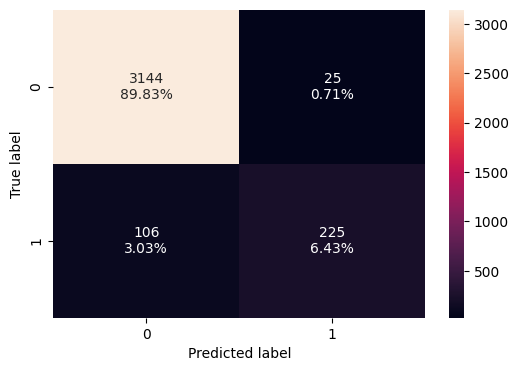

In [88]:
# creating confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix_sklearn_with_threshold(lg, X_train, y_train)

Checking performance on test set


In [89]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
log_reg_model_train_perf = model_performance_classification_sklearn_with_threshold(
    lg, X_train, y_train
)
print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.962571,0.679758,0.9,0.774527


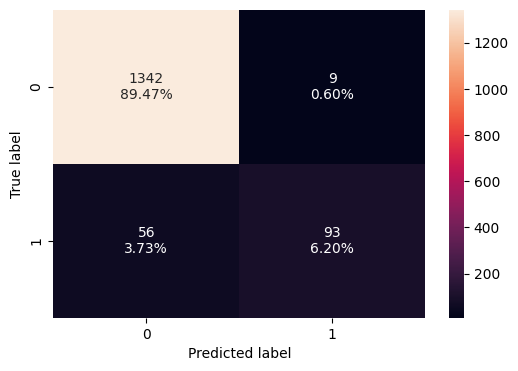

In [90]:
# creating confusion matrix
confusion_matrix_sklearn_with_threshold(lg, X_test, y_test)

In [91]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
log_reg_model_test_perf = model_performance_classification_sklearn_with_threshold(
    lg, X_test, y_test
)
print("Training performance:")
log_reg_model_test_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.956667,0.624161,0.911765,0.741036


Observation: The Recall on the training and test sets are close in value 62% and 68% respectively, yet the model performance needs to be improved as viewed from the confusion matrix as well:

TP 6.20% which is less than tha 9% positive class of the dataset


Plotting the ROC-AUC for both training and test set
ROC-AUC on training set

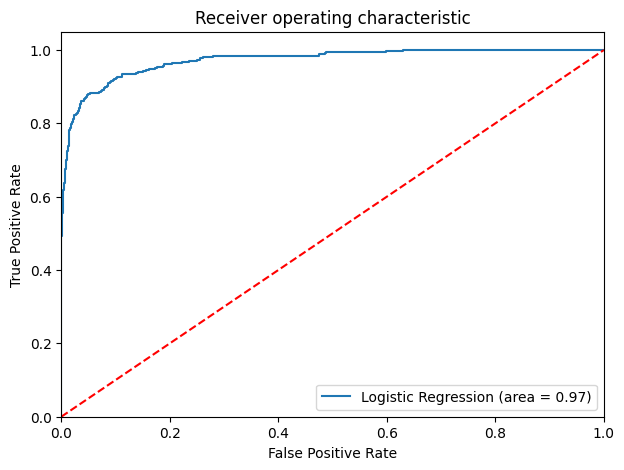

In [93]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc_train = roc_auc_score(y_train, lg.predict_proba(X_train)[:, 1])
fpr, tpr, thresholds = roc_curve(y_train, lg.predict_proba(X_train)[:, 1])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

ROC-AUC on test set

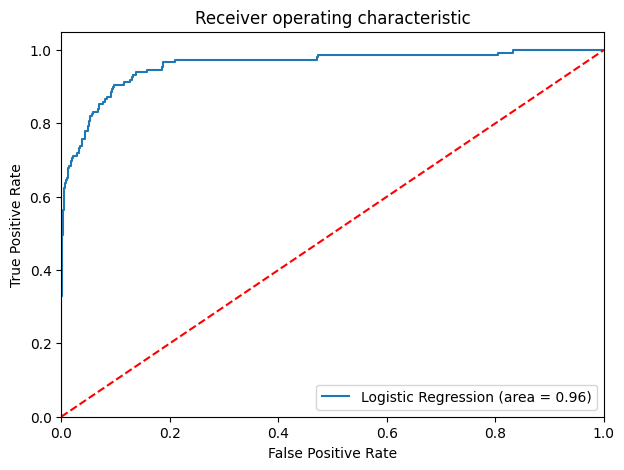

In [94]:
logit_roc_auc_test = roc_auc_score(y_test, lg.predict_proba(X_test)[:, 1])
fpr, tpr, thresholds = roc_curve(y_test, lg.predict_proba(X_test)[:, 1])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_test)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

The AUC of the test and train models ROC is 0.96 and 0.97 respectively which is very close to 1. This indicates that the model is very good yet requires some tuning. Hence, our approach is to tune the Threshold and observe how the model performance improves



Model performance improvement
1- We derive the optimal threshold from the AUC,ROC curve



In [95]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
y_predict_train_proba = lg.predict_proba(X_train)[:,1]
fpr, tpr, thresholds = roc_curve(y_train, y_predict_train_proba)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print(f'The optimal threshhold from ROC AUC curve is : {optimal_threshold_auc_roc}')

The optimal threshhold from ROC AUC curve is : 0.18774224125600344


The optimal threshhold from ROC AUC curve is : 0.1873087910754858


Checking model performance on training set


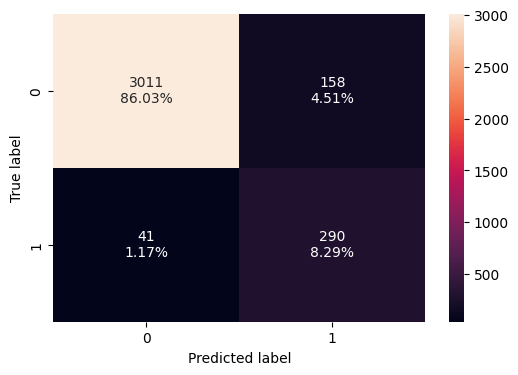

In [96]:
# creating confusion matrix
confusion_matrix_sklearn_with_threshold(
    lg, X_train, y_train, threshold=optimal_threshold_auc_roc
)

In [97]:
# checking model performance for this model
log_reg_model_train_perf_threshold_auc_roc = model_performance_classification_sklearn_with_threshold(
    lg, X_train, y_train, threshold=optimal_threshold_auc_roc
)
print("Training performance with optimal threshhold from ROC AUC curve")
log_reg_model_train_perf_threshold_auc_roc

Training performance with optimal threshhold from ROC AUC curve


,Accuracy,Recall,Precision,F1
0,0.943143,0.876133,0.647321,0.744544


Checking model performance on test set


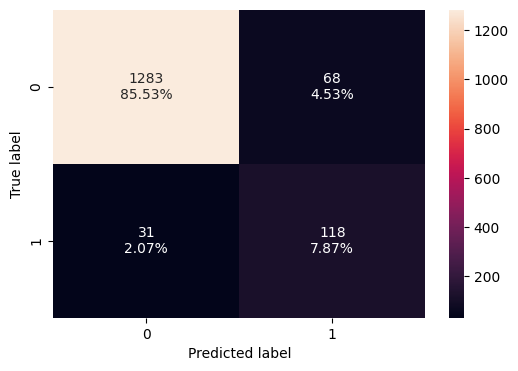

In [98]:
# creating confusion matrix
confusion_matrix_sklearn_with_threshold(
    lg, X_test, y_test, threshold=optimal_threshold_auc_roc
)

In [99]:
# checking model performance for this model
log_reg_model_test_perf_threshold_auc_roc = model_performance_classification_sklearn_with_threshold(
    lg, X_test, y_test, threshold=optimal_threshold_auc_roc
)
print("Test set performance:")
log_reg_model_test_perf_threshold_auc_roc

Test set performance:


,Accuracy,Recall,Precision,F1
0,0.934,0.791946,0.634409,0.704478


The Recall and precision are improved from range of 60s to range of 80s, yet the TP in both confusion matrices (train and test) is still under the 9% of the original dataset. Hence, our second approach is to extract another threshold from the Recall - Precision VS Threshold curve


Ploting the Recall and Precision VS Threshold curve

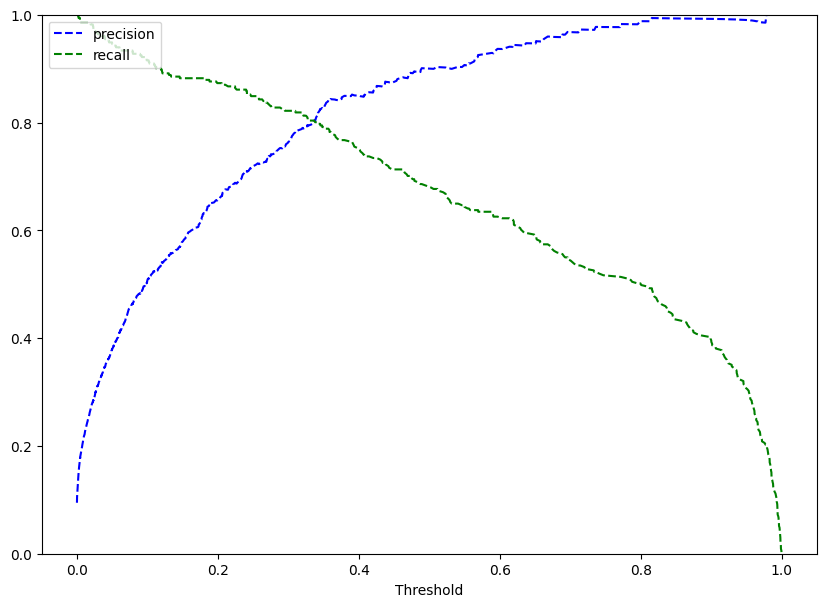

In [100]:
from sklearn.metrics import precision_recall_curve
prec, rec, tre = precision_recall_curve(y_train, y_predict_train_proba)
plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

It is observed that the intersection point of recall and precision occurs at a threshold of approximately 0.35, yielding a recall of around 80%, which is lower than the optimal threshold derived from the ROC-AUC curve. To improve the model, we will focus on threshold values lower than the optimal 0.187. From the precision-recall curve, we can see that at a threshold of approximately 0.1, recall reaches about 90%, while precision is around 50%. Therefore, we will evaluate the model's performance at this threshold.



A threshold of 0.10 is picked to Checking model performance on training and test tests


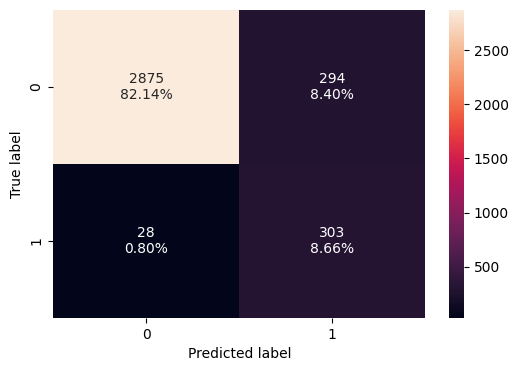

In [101]:
# creating confusion matrix for train set
confusion_matrix_sklearn_with_threshold(
    lg, X_train, y_train, threshold=0.10
)

In [102]:
# checking model performance for this model
log_reg_model_train_perf_threshold_curve = model_performance_classification_sklearn_with_threshold(
    lg, X_train, y_train, threshold=0.10
)
print("Training performance with deduced threshhold from Precision - Recall curve is:")
log_reg_model_train_perf_threshold_curve

Training performance with deduced threshhold from Precision - Recall curve is:


,Accuracy,Recall,Precision,F1
0,0.908,0.915408,0.507538,0.653017


Checking model performance on test set


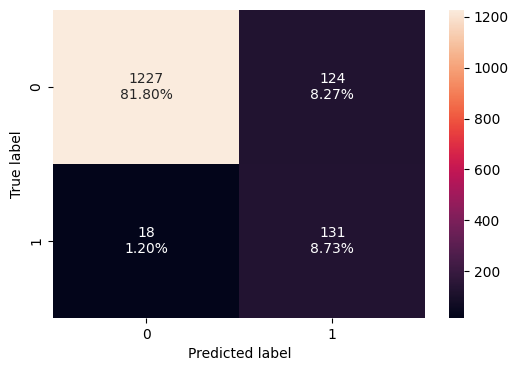

In [103]:
# creating confusion matrix
confusion_matrix_sklearn_with_threshold(
    lg, X_test, y_test, threshold=0.10
)

In [104]:
# checking model performance for this model
log_reg_model_test_perf_threshold_curve = model_performance_classification_sklearn_with_threshold(
    lg, X_test, y_test, threshold=0.10
)
print("Training performance with deduced threshhold from the Precision - Recall curve is::")
log_reg_model_test_perf_threshold_curve

Training performance with deduced threshhold from the Precision - Recall curve is::


,Accuracy,Recall,Precision,F1
0,0.905333,0.879195,0.513725,0.648515


Observation and conclusion:
At threshold 0.10 the Recall for the test and train data sets is equal to 87% and 91% respectively which is a very good performance by the logistics regression model to minimize the FN on our model to only 1.20% on the test set whilst maintaing a precision value of approx.50% for both test and train datasets.

Apply sequential feature selector


In [105]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
# to plot the performance with addition of each feature
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

In [159]:
# from sklearn.linear_model import LogisticRegression
# Fit the model on train
model = LogisticRegression(solver="newton-cg", n_jobs=-1, random_state=1, max_iter=100)

In [106]:
X_train.shape

(3500, 257)

In [107]:
# we will first build model with all varaible
sfs = SFS(
    model,
    k_features=257,
    forward=True,
    floating=False,
    scoring="f1",
    verbose=2,
    cv=3,
    n_jobs=-1,
)

sfs1 = sfs.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 257 out of 257 | elapsed:    9.6s finished

[2024-09-24 13:53:25] Features: 1/257 -- score: 0.4045694418575774[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  70 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 256 out of 256 | elapsed:   24.0s finished

[2024-09-24 13:53:49] Features: 2/257 -- score: 0.5370139749429014[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  70 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 255 out of 255 | elapsed:   25.4s finished

[2024-09-24 13:54:15] Features: 3/257 -- score: 0.5743776563448694[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 158 ta

Display the most important feature names.:



In [117]:
from sklearn.linear_model import LogisticRegression
import joblib
joblib.dump(model, '/content/drive/MyDrive//content/Project2.joblib')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive//content/Project2.joblib'

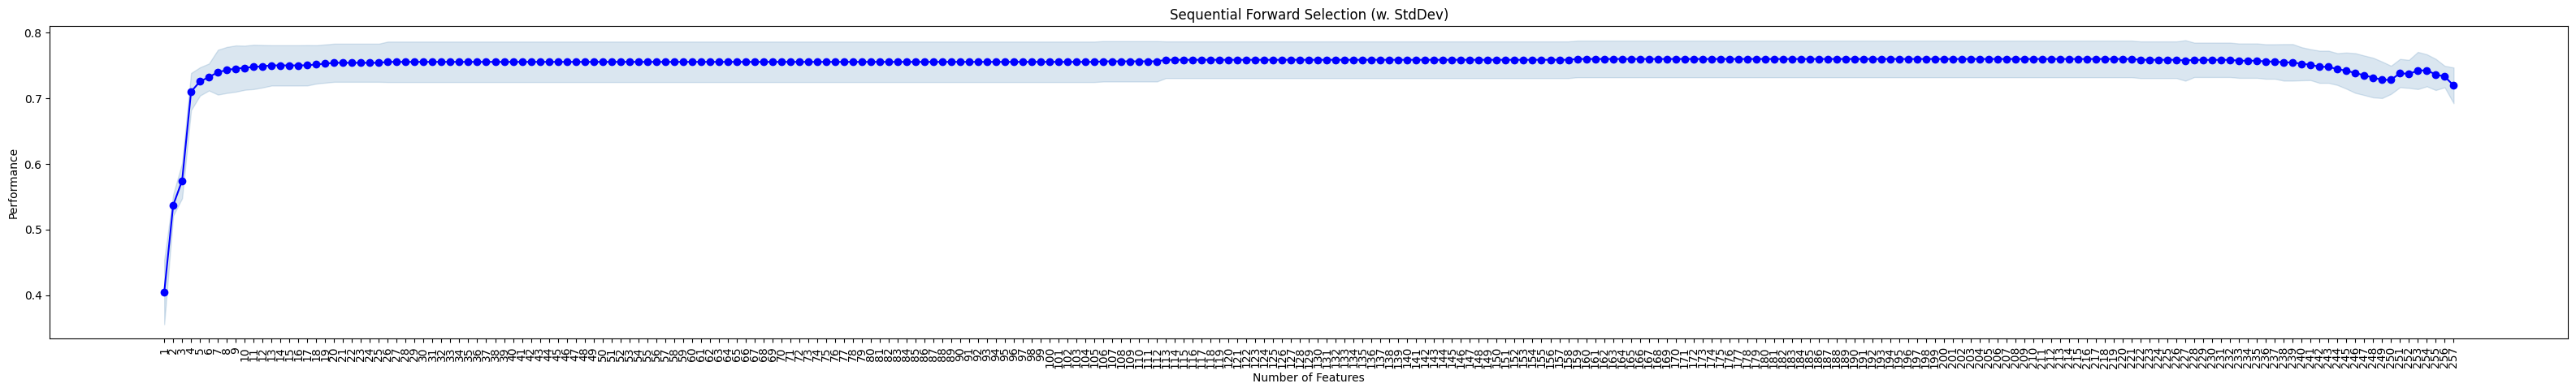

In [114]:
fig1 = plot_sfs(sfs.get_metric_dict(), kind="std_dev", figsize=(40, 5))
plt.title("Sequential Forward Selection (w. StdDev)")
plt.xticks(rotation=90)
plt.show()

We can see that from approx the 22nd feature the performance start to stay constant, hence let us create a new model with 20 variables only and display the top 20 features

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 257 out of 257 | elapsed:    8.4s finished

[2024-09-24 17:11:34] Features: 1/22 -- score: 0.4045694418575774[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  70 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 256 out of 256 | elapsed:   24.7s finished

[2024-09-24 17:11:59] Features: 2/22 -- score: 0.5370139749429014[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  70 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done 255 out of 255 | elapsed:   26.5s finished

[2024-09-24 17:12:26] Features: 3/22 -- score: 0.5743776563448694[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 158 tasks

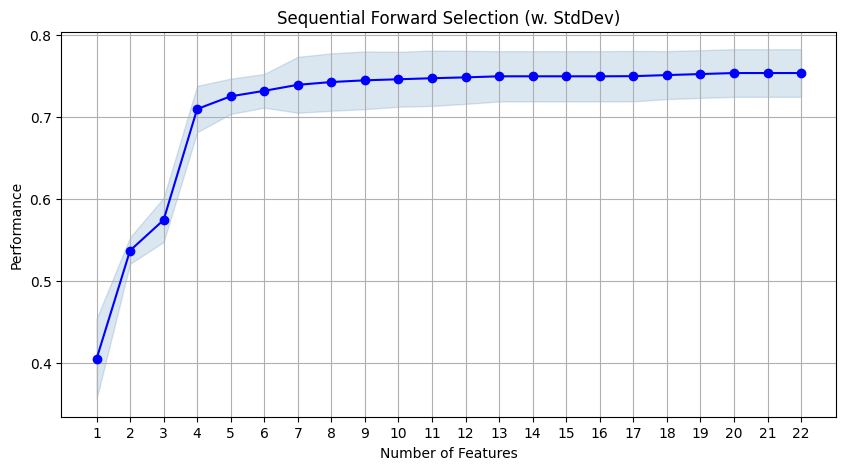

In [118]:
sfs1 = SFS(
    model,
    k_features=22,
    forward=True,
    floating=False,
    scoring="f1",
    verbose=2,
    cv=3,
    n_jobs=-1,
)

sfs1 = sfs1.fit(X_train, y_train)

fig1 = plot_sfs(sfs1.get_metric_dict(), kind="std_dev", figsize=(10, 5))

plt.title("Sequential Forward Selection (w. StdDev)")
plt.grid()
plt.show()

In [119]:
feat_cols = list(sfs1.k_feature_idx_)
print(feat_cols)
X_train.columns[feat_cols]

[2, 3, 6, 7, 9, 10, 11, 12, 13, 14, 16, 17, 20, 34, 42, 65, 100, 123, 149, 192, 206, 207]


Index(['Income', 'Family', 'Securities_Account', 'CD_Account', 'CreditCard',
       'Education_2', 'Education_3', 'City_Alameda', 'City_Alamo',
       'City_Albany', 'City_Anaheim', 'City_Antioch', 'City_Arcata',
       'City_Brisbane', 'City_Cardiff By The Sea', 'City_Davis', 'City_Irvine',
       'City_Menlo Park', 'City_Oakland', 'City_San Jose',
       'City_Santa Barbara', 'City_Santa Clara'],
      dtype='object')

Performance Evaluation of the Simpified model (variables = 22)

In [120]:
X_train_sfs = X_train[X_train.columns[feat_cols]]
# Creating new x_test with the same variables that we selected for x_train
X_test_sfs = X_test[X_train_sfs.columns]
# X_train_sfs = X_train.columns[X_train.columns[feat_cols]]
# X_test_sfs = X_test[X_train_sfs.columns]
print(f'''X_train shape:{X_train_sfs.shape}
Y_test shape:{X_test_sfs.shape}''')

X_train shape:(3500, 22)
Y_test shape:(1500, 22)


In [121]:
X_train_sfs

Output hidden; open in https://colab.research.google.com to view.

In [123]:
# Fitting logistic regession model
log_sfs = LogisticRegression(
    solver="newton-cg", penalty=None, verbose=True, n_jobs=-1, random_state=1
)
# There are several optimizer, we are using optimizer called as 'newton-cg' with max_iter equal to 10000
# max_iter indicates number of iteration needed to converge
log_sfs.fit(X_train_sfs, y_train)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


LogisticRegression(n_jobs=-1, penalty=None, random_state=1, solver='newton-cg',
                   verbose=True)

Model Performance

Training Set analysis

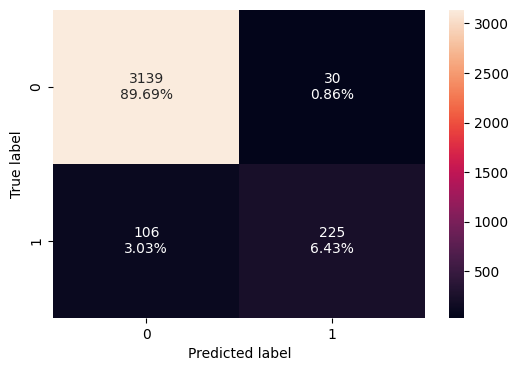

In [124]:
confusion_matrix_sklearn_with_threshold(log_sfs, X_train_sfs, y_train)

In [125]:
log_reg_model_train_perf_SFS = model_performance_classification_sklearn_with_threshold(
    log_sfs, X_train_sfs, y_train
)
print("Training performance:")
log_reg_model_train_perf_SFS

Training performance:


,Accuracy,Recall,Precision,F1
0,0.961143,0.679758,0.882353,0.767918


Test Set Analysis

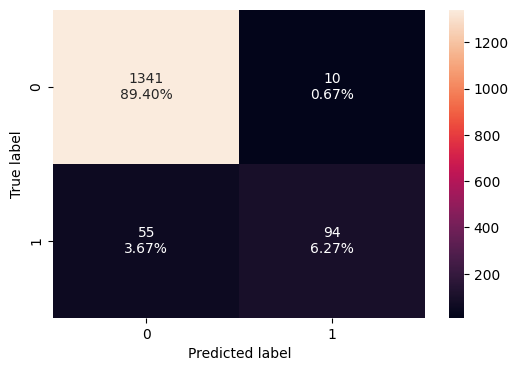

In [126]:
confusion_matrix_sklearn_with_threshold(log_sfs, X_test_sfs, y_test)

In [127]:
log_reg_model_test_perf_SFS = model_performance_classification_sklearn_with_threshold(
    log_sfs, X_test_sfs, y_test
)
print("Test set performance:")
log_reg_model_test_perf_SFS

Test set performance:


,Accuracy,Recall,Precision,F1
0,0.956667,0.630872,0.903846,0.743083


The Recall is much less than after applying the feature selection with the default threshold 0.5 , hence we will derive another model with a threshold 0.1 and observe its performance

In [128]:
log_reg_model_train_perf_SFS_tre = model_performance_classification_sklearn_with_threshold(
    log_sfs, X_train_sfs, y_train,  threshold=0.1
)
print("Training performance:")
log_reg_model_train_perf_SFS_tre

Training performance:


,Accuracy,Recall,Precision,F1
0,0.906,0.873112,0.501736,0.637266


Training performance:


In [129]:
log_reg_model_test_perf_SFS_tre = model_performance_classification_sklearn_with_threshold(
    log_sfs, X_test_sfs, y_test, threshold=0.1
)

print("Test set performance:")
log_reg_model_test_perf_SFS

Test set performance:


,Accuracy,Recall,Precision,F1
0,0.956667,0.630872,0.903846,0.743083


Logistic Regression Models Comparison:
Sr	Model name	train_performance	recall (train)	test_performance	recall(test)	threshold	no. of variables
1	lg	log_reg_model_train_perf	0.6798	log_reg_model_test_perf	0.6242	0.5	257
2	lg	log_reg_model_train_perf_threshold_auc_roc	0.8761	log_reg_model_test_perf_threshold_auc_roc	0.7919	0.187	257
3	lg	log_reg_model_train_perf_threshold_curve	0.9154	log_reg_model_test_perf_threshold_curve	0.8792	0.10	257
4	log_sfs	log_reg_model_train_perf_SFS	0.6798	log_reg_model_test_perf_SFS	0.6241	0.5	22
5	log_sfs	log_reg_model_train_perf_SFS_tre	0.8731	log_reg_model_test_perf_SFS_tre	0.6242	0.1	22

The Recall of the train and test sets are highly mismatched, where recall train = 0.87 and recall test = 0.62



Observation:

The best-performing model is Model_3, a logistic regression model tuned to a threshold of 0.1 and utilizing 257 variables.

Conclusion:

The low threshold, which results in strong model performance, can be explained by the small proportion of class 1 customers (those who accept personal loans) in the original dataset. This model will be used in the final comparison against decision tree models.



Model building


2. Decision Tree


In addition to using the : The get_recall_score and make_confusion_matrix functions, we will define the function plot_tree to plot the decision trees for the models under study



In [130]:
#function to plot a decision tree
def plot_tree(model, Predictor):
    feature_names = Predictor.columns.to_list()
    plt.figure(figsize=(20, 30))
    out = tree.plot_tree(
        model,
        feature_names=feature_names,
        filled=True,
        fontsize=9,
        node_ids=False,
        class_names=None,
    )
    # below code will add arrows to the decision tree split if they are missing
    for o in out:
        arrow = o.arrow_patch
        if arrow is not None:
            arrow.set_edgecolor("black")
            arrow.set_linewidth(1)
    plt.show()

Building the original tree $T_0$


The starting point is building the original full tree model with the default hyperparameters and observe:

Model performance
Variables importance
Model Improvement strategy
Yet, It was noted that the frequence of classes in training set is:

Class	Frequence
0	0.905429
1	0.094571
To avoid ending up with a bias model, we should balance the class weights (using the class_weight hyperparamater) in the decision tree classifer.

In [132]:
#creating the decission tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.metrics import recall_score
t_0 = DecisionTreeClassifier(criterion="gini", class_weight={0: 0.094571, 1: 0.905429}, random_state=1)

In [133]:
#fitting the training data
t_0.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.094571, 1: 0.905429}, random_state=1)

Model performance Evaluation of $T_0$


In [134]:
#Calculating the Recall for train and test data
Recall_Train_T_0 = get_recall_score(t_0, X_train, y_train)
print(f'Recall for T_0 on Train Data = {Recall_Train_T_0}')
Recall_Test_T_0 = get_recall_score(t_0, X_test, y_test)
print(f'Recall for T_0 on Test Data = {Recall_Test_T_0}')

Recall for T_0 on Train Data = 1.0
Recall for T_0 on Test Data = 0.8791946308724832


A quiet big mismatch is observed between train and test sets performance, hence it is assumed that the T_0 model is overfitting the data. let us observe further the confusion matrix and the tree structure.



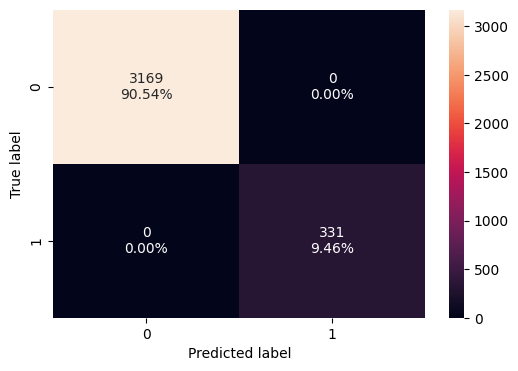

In [135]:
confusion_matrix_sklearn(t_0, X_train, y_train)

As assumed, the model is perfectly overfitting the data as observed from the confusion matric the FN & FP are 0%

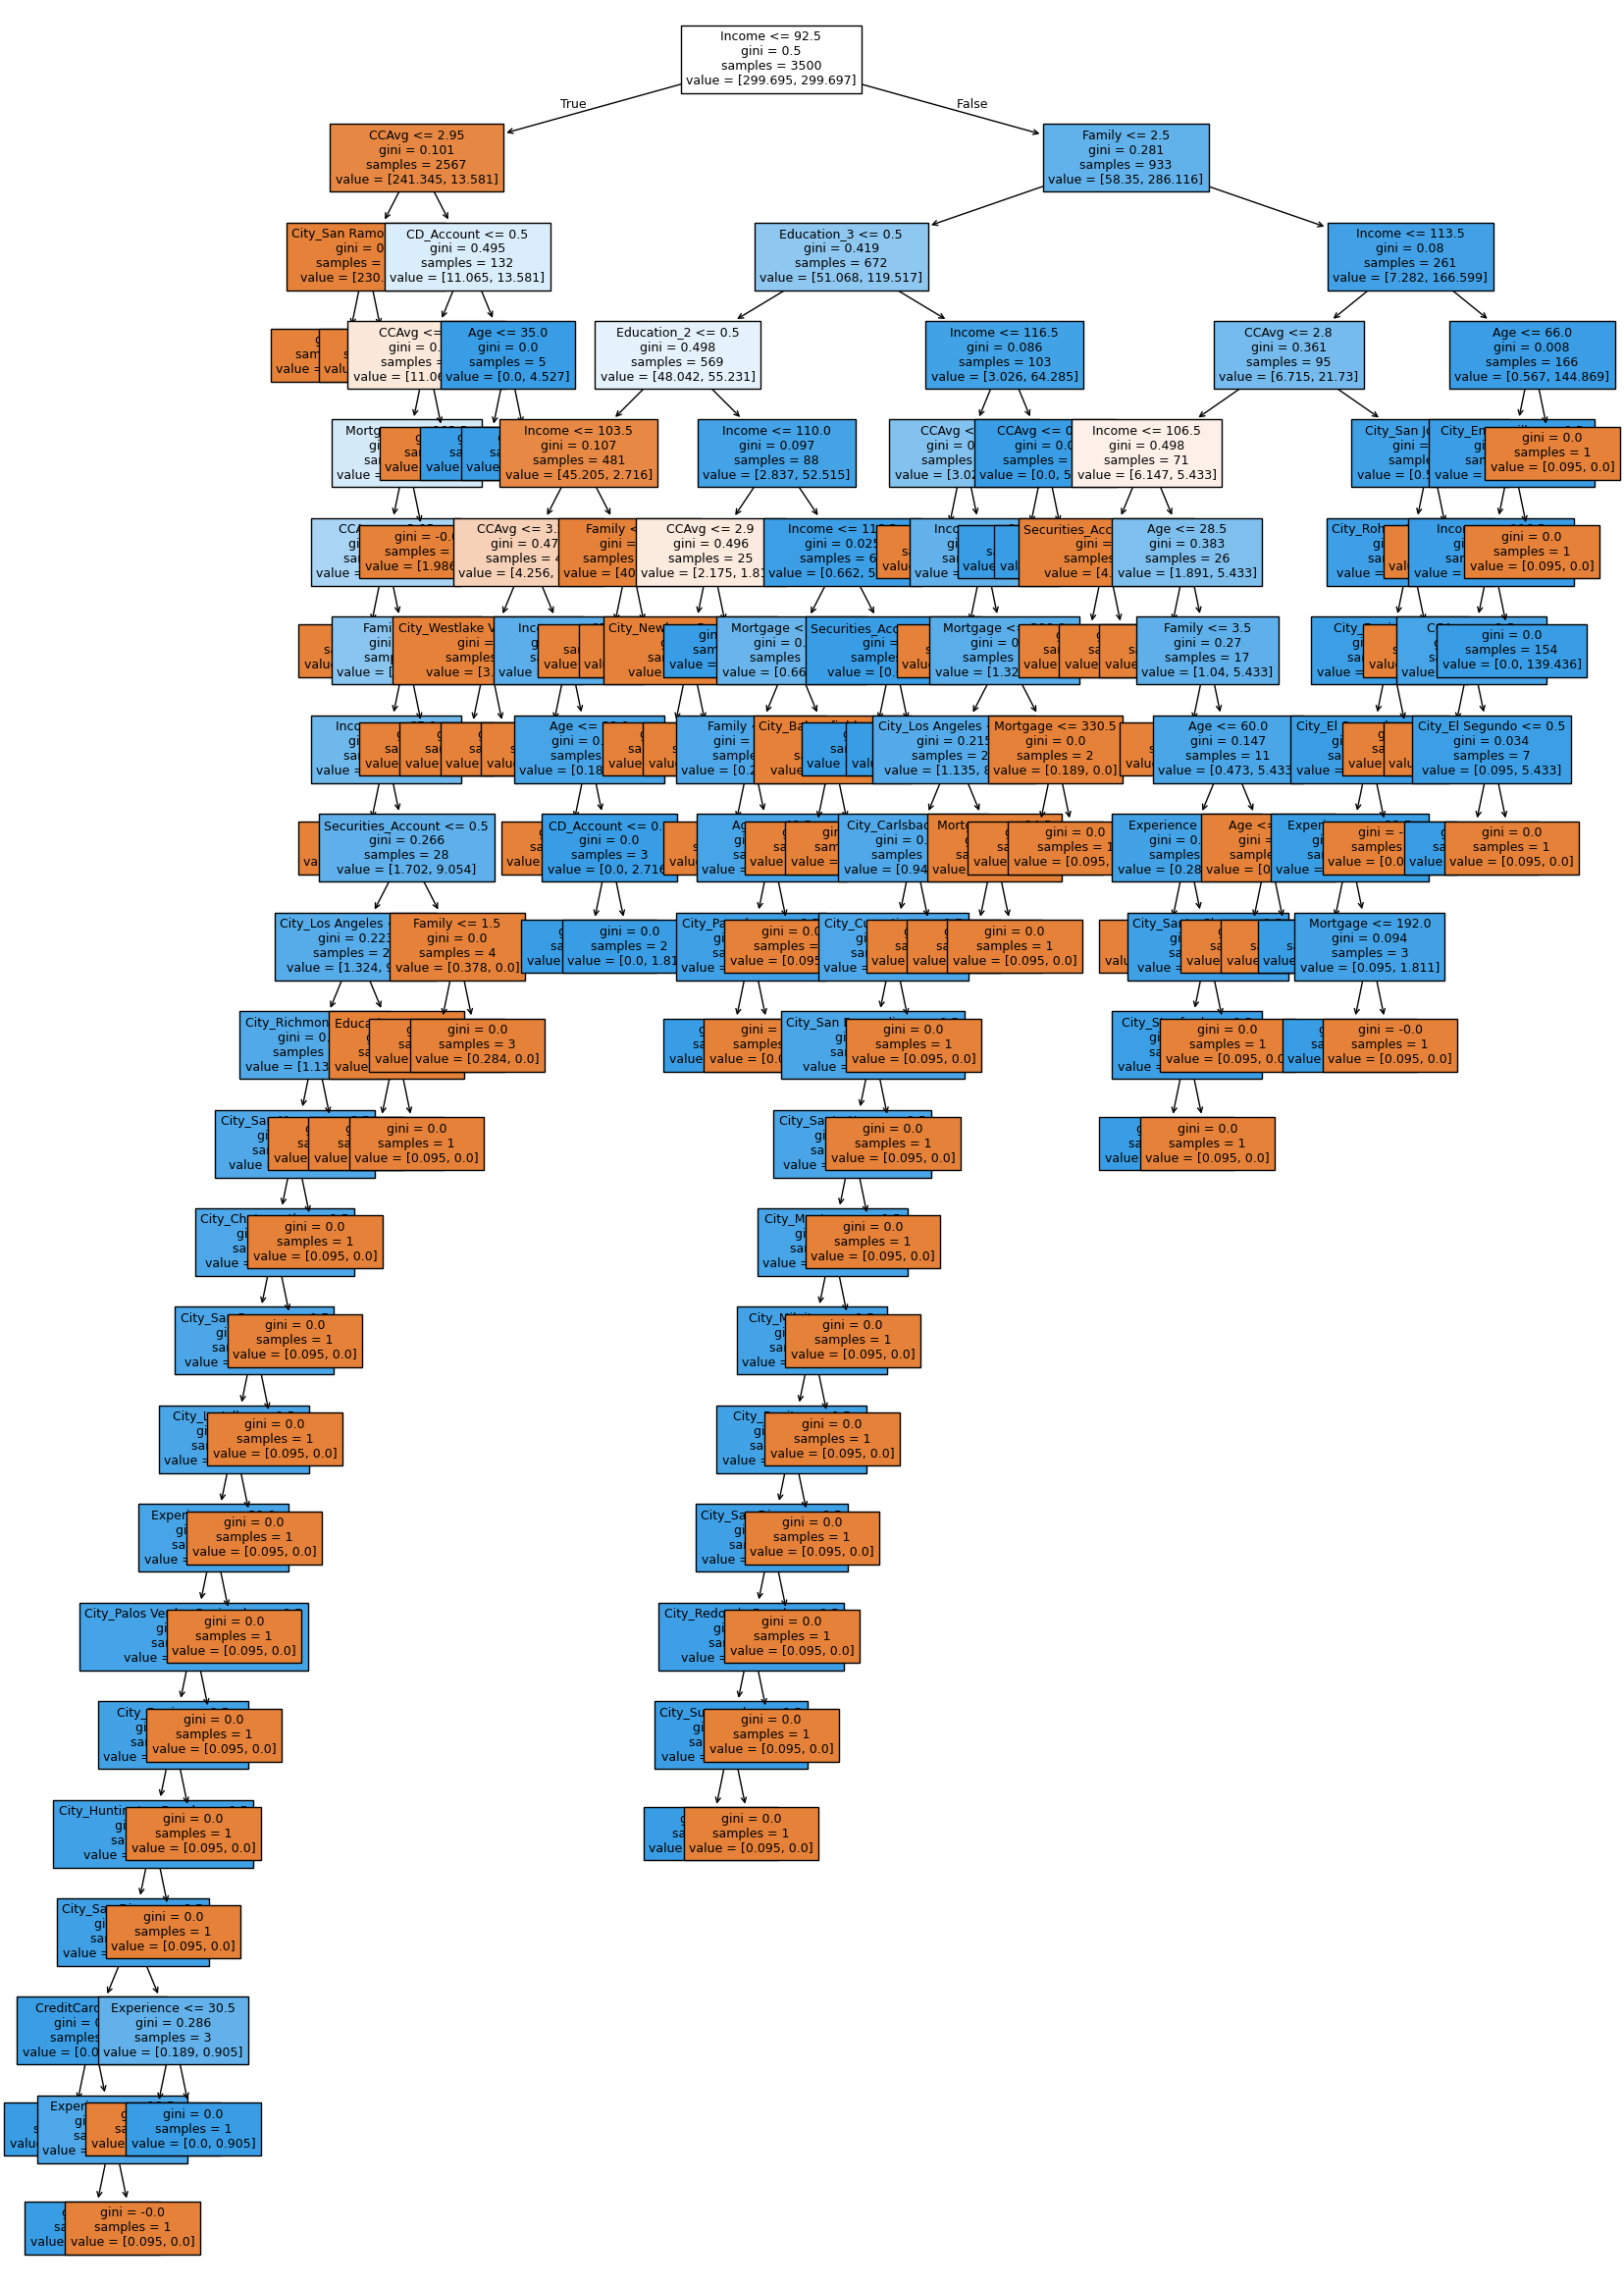

In [137]:
#plotting the tree
from sklearn import tree
plot_tree(t_0,X_train)

The original tree,
𝑇0 is quite complex and overfits the training dataset. Therefore, both pre-pruning and post-pruning should be considered to improve model performance. An interesting observation about
𝑇0 is that the first split occurs on the "Income" variable, so we will begin by examining the variable importances.

### Model Evaluation Criterion

*


In [138]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

def view_nd_plot_importance(model, predictors):
    print("The features importances:")
    print(
        pd.DataFrame(
            model.feature_importances_, columns=["Imp"], index=predictors.columns
        ).sort_values(by="Imp", ascending=False)
    )

    importances = model.feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(12, 65))
    plt.title("Feature Importances")
    plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
    plt.yticks(range(len(indices)), [predictors.columns[i] for i in indices])
    plt.xlabel("Relative Importance")
    plt.show()

The features importances:
                                      Imp
Income                       6.344150e-01
Education_2                  1.363992e-01
CCAvg                        8.947356e-02
Education_3                  4.802533e-02
Family                       4.614256e-02
Mortgage                     8.142300e-03
CD_Account                   7.459360e-03
Age                          7.016396e-03
Experience                   2.776261e-03
City_Los Angeles             1.971268e-03
Securities_Account           1.853857e-03
City_El Segundo              1.240587e-03
City_San Jose                1.192088e-03
City_Davis                   1.188932e-03
City_San Diego               7.638723e-04
City_Emeryville              6.274207e-04
City_Sunnyvale               6.238720e-04
City_Stanford                6.203138e-04
City_Pasadena                6.098786e-04
City_Redondo Beach           6.097199e-04
City_Rohnert Park            6.062424e-04
City_Santa Clara             5.994434e-04
City_Hun

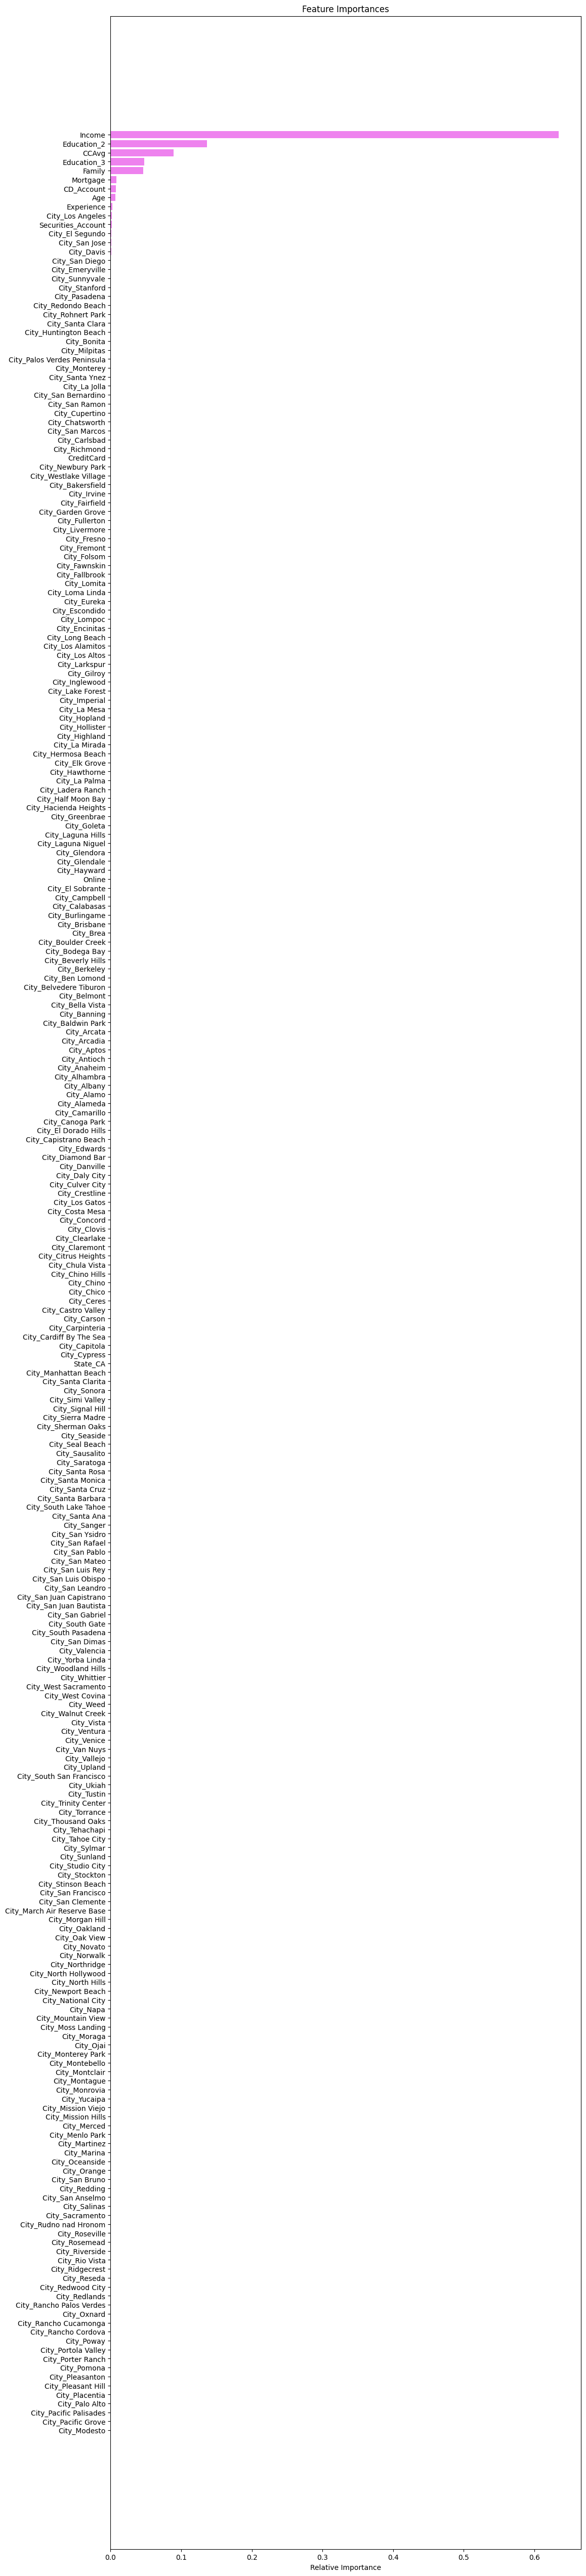

In [139]:
view_nd_plot_importance(t_0, X_train)

It is observed that the top importance variable is Income and the least importance are the cities (except for Los Angles that contributes slightly to the model predictibility)
The top 5 variables are :
Income
Education_2
CCAvg
Education_3
Family

Model performance improvement
1. Pre-prunning via hyperparameter tuning
The approach is: applying GridSearch to compute the optimum hyperparameter values



### Model Building

In [140]:
#let us get the max depth of T_0 to have an idea how to tune our parameters
print(f'''The max depth of the t_0 =  {t_0.tree_.max_depth}
The node_count ={t_0.tree_.node_count}
The number of leaves = {t_0.tree_.n_leaves}''')

The max depth of the t_0 =  22
The node_count =175
The number of leaves = 88


In [141]:
# Choose the type of classifier.
t_grid = DecisionTreeClassifier(random_state=1, class_weight={0: 0.094571, 1: 0.905429})

# Grid of parameters to choose from
parameters = {
    "max_depth": [5, 10, 15, 20, None],
    "criterion": ["entropy", "gini"],
    "splitter": ["best", "random"],
    'min_samples_leaf': [1, 2, 5, 7, 10,15,20],
    'max_leaf_nodes' : [2, 3, 5, 10],
    "min_impurity_decrease": [0.00001, 0.0001, 0.01],
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(recall_score)

# Run the grid search
grid_obj = GridSearchCV(t_grid, parameters, scoring=scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
t_grid = grid_obj.best_estimator_

# Fit the best algorithm to the data.
t_grid.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.094571, 1: 0.905429},
                       criterion='entropy', max_depth=5, max_leaf_nodes=3,
                       min_impurity_decrease=1e-05, random_state=1)

Applying the tuned hyperparamaters to derive T_1
Plugging in the hyper parameters:

max_depth = 5
Criteroion = Entropy
remaining paramaters : Keep as default

In [142]:
# Choose the type of classifier.
t_1 = DecisionTreeClassifier(random_state=1,max_depth=5, criterion='entropy'
                             , class_weight={0: 0.094571, 1: 0.905429})

In [143]:
t_1.fit(X_train,y_train)

DecisionTreeClassifier(class_weight={0: 0.094571, 1: 0.905429},
                       criterion='entropy', max_depth=5, random_state=1)

Model Performance Evaluation_Pre-pruned Tree $T_1$


In [144]:
Recall_Train_T_1 = get_recall_score(t_1, X_train, y_train)
print(f'Recall for T_1 on Train Data = {Recall_Train_T_1}')
Recall_Test_T_1 = get_recall_score(t_1, X_test, y_test)
print(f'Recall for T_1 on Test Data = {Recall_Test_T_1}')

Recall for T_1 on Train Data = 0.9909365558912386
Recall for T_1 on Test Data = 0.9530201342281879


Displaying the tree, the confucion matrix and variables importance



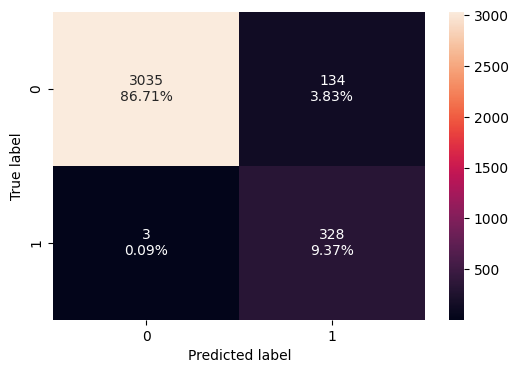

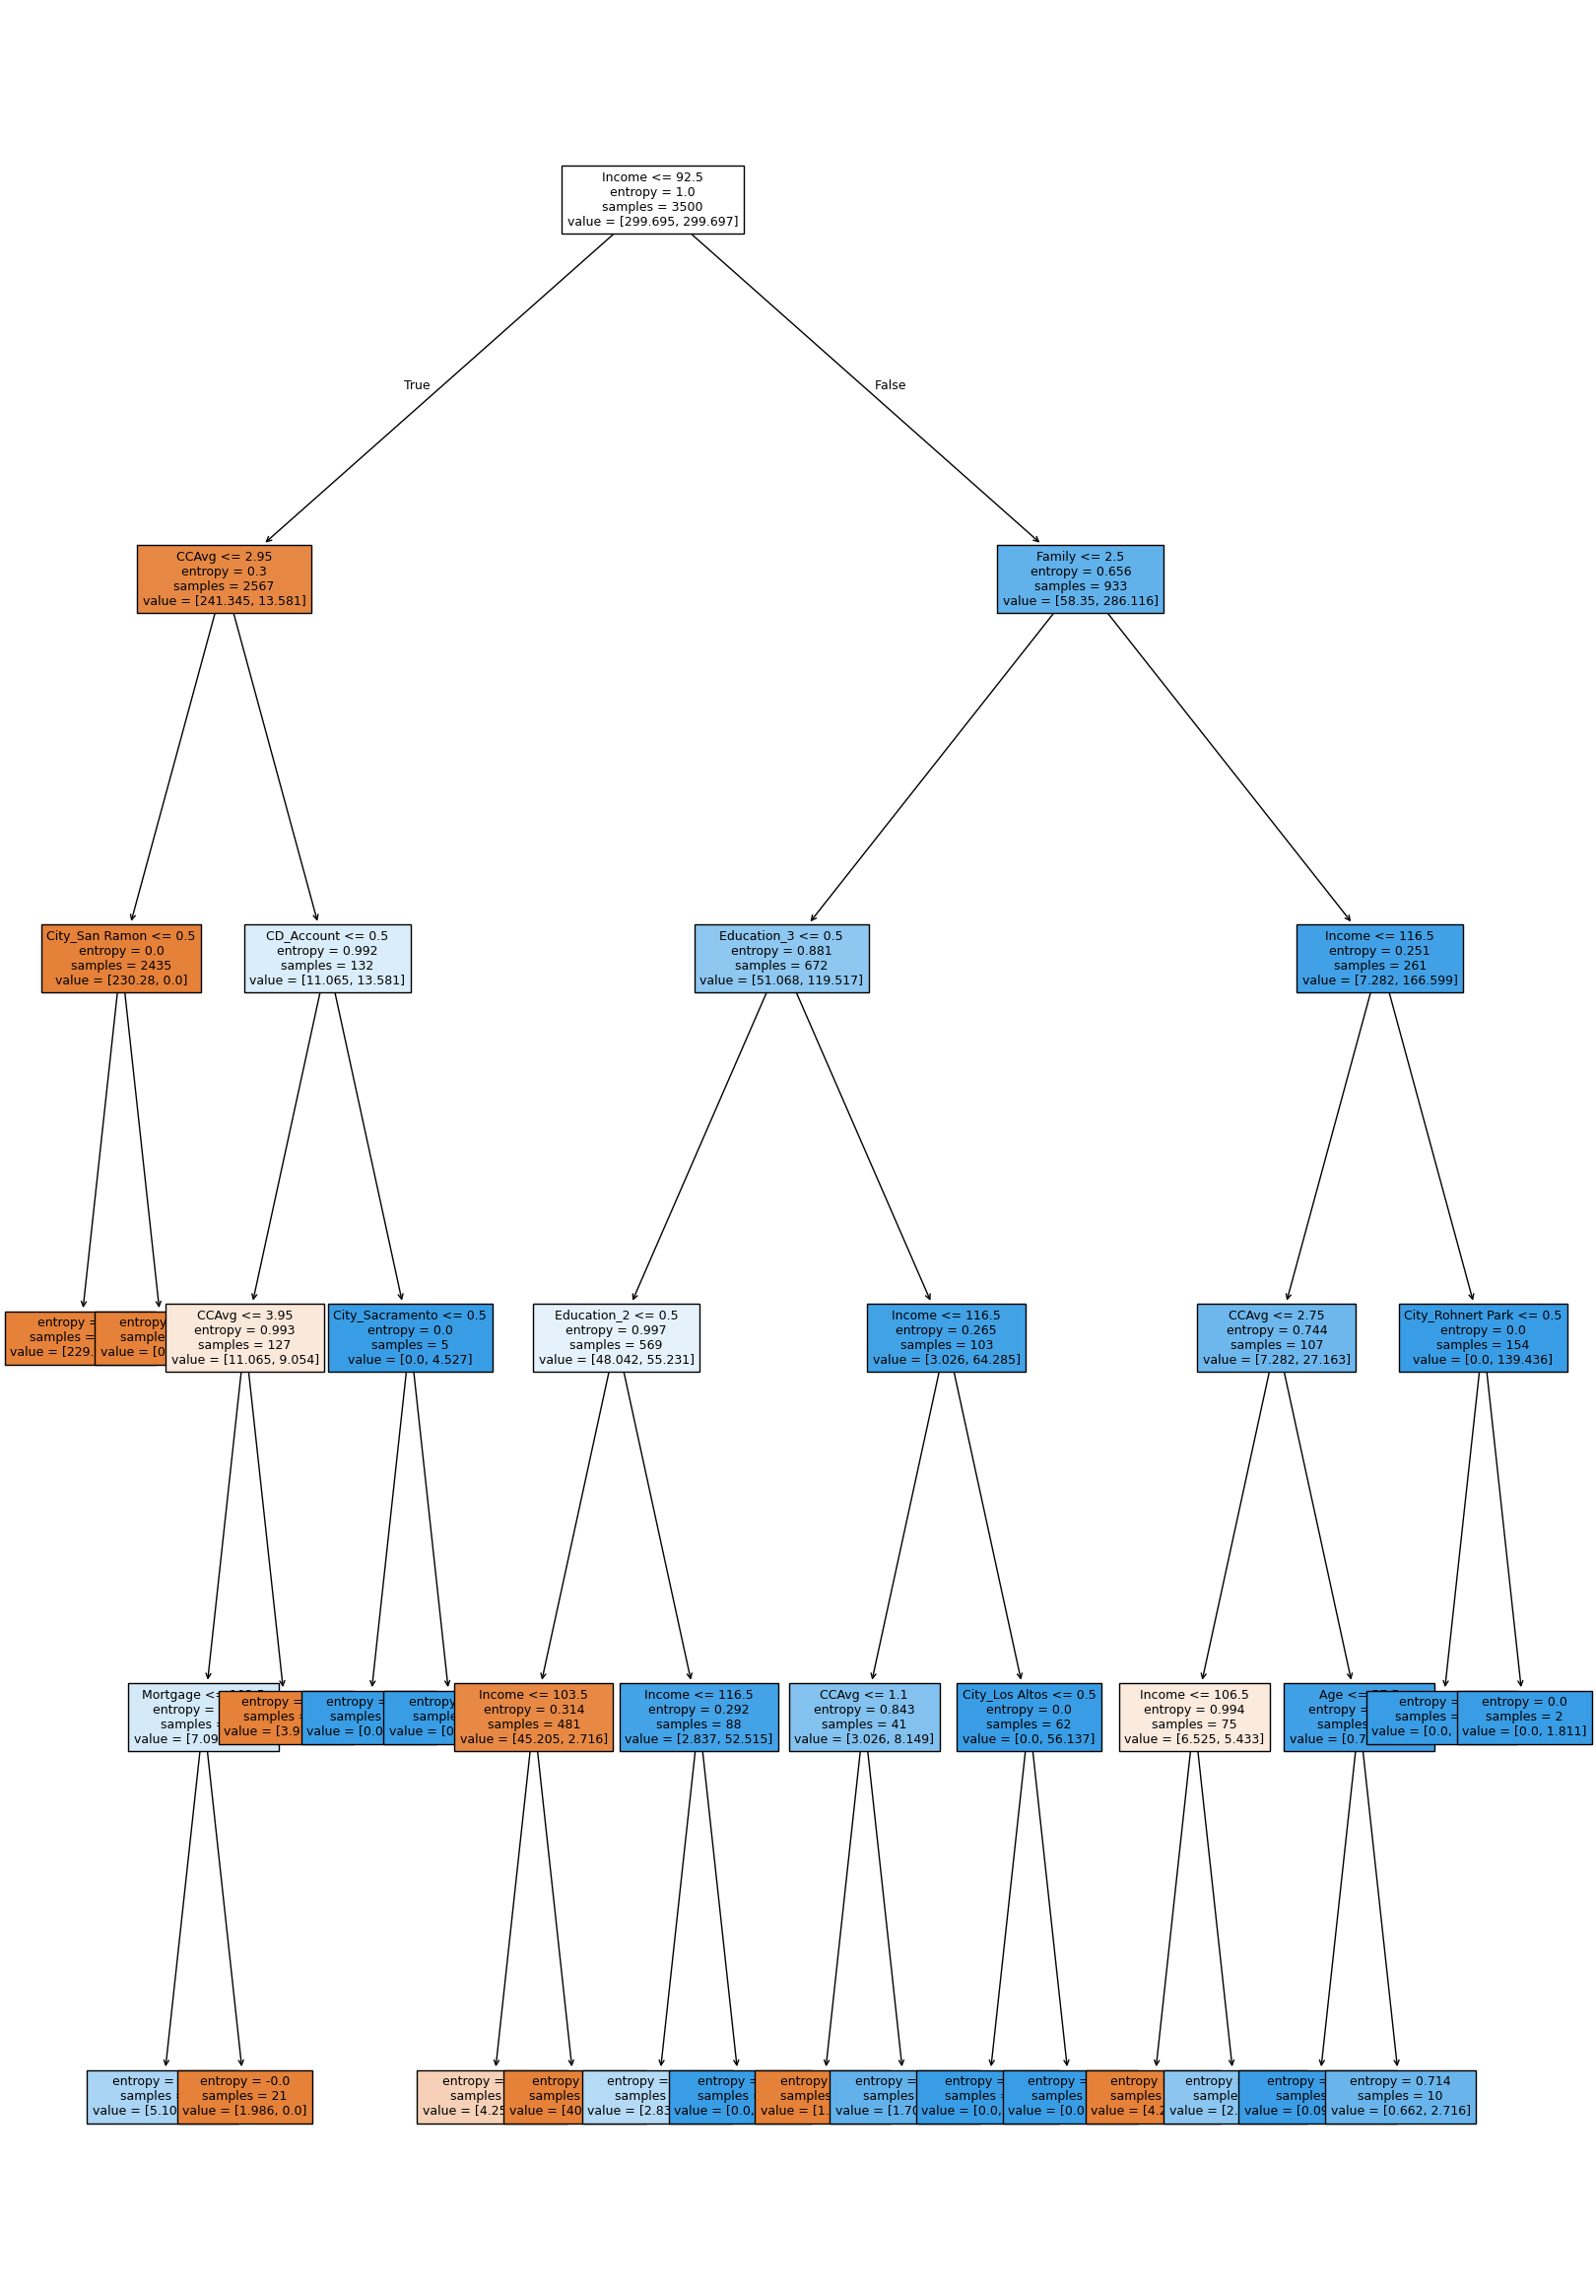

The features importances:
                                      Imp
Income                       6.221524e-01
Education_2                  1.290525e-01
CCAvg                        1.221962e-01
Family                       5.805141e-02
Education_3                  5.305620e-02
CD_Account                   8.074140e-03
Mortgage                     4.711449e-03
Age                          2.705663e-03
City_Rohnert Park            4.421088e-16
City_San Ramon               3.804417e-16
City_Los Altos               3.236215e-17
City_Sacramento              2.348866e-17
City_Rancho Palos Verdes     0.000000e+00
City_Rancho Cucamonga        0.000000e+00
City_Redlands                0.000000e+00
City_Redondo Beach           0.000000e+00
City_Rancho Cordova          0.000000e+00
City_Redwood City            0.000000e+00
City_Reseda                  0.000000e+00
City_Richmond                0.000000e+00
City_Ridgecrest              0.000000e+00
City_Rio Vista               0.000000e+00
City_Riv

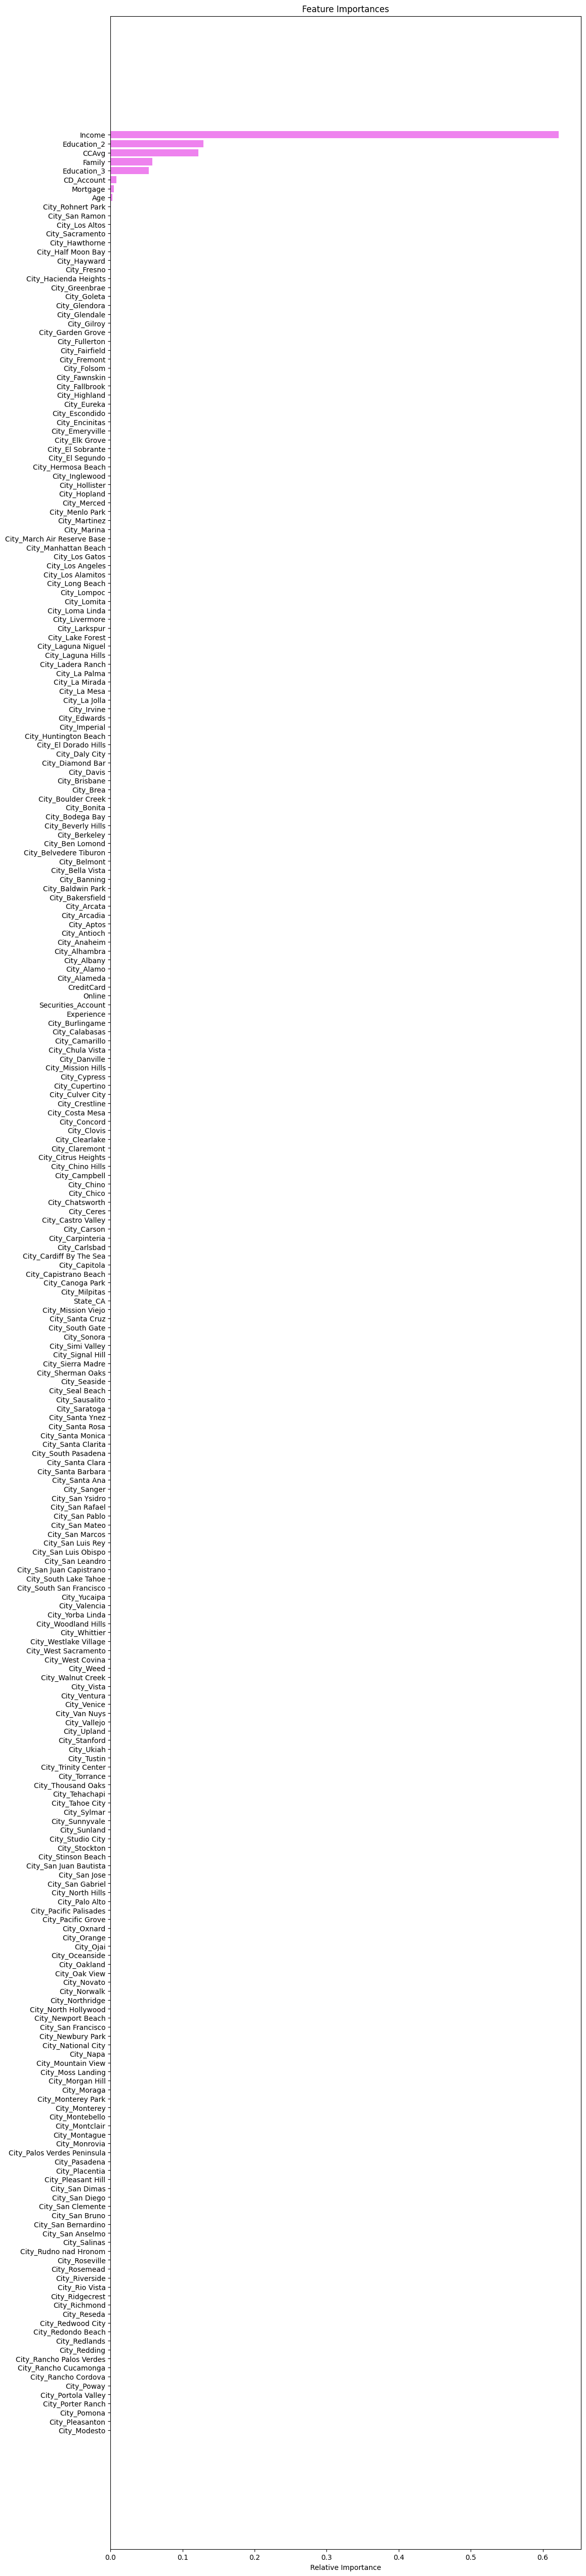

In [145]:
confusion_matrix_sklearn(t_1, X_train, y_train)
plot_tree(t_1,X_train)
view_nd_plot_importance(t_1, X_train)

Observation
At max_depth=5. criterion= entropy and default values for the remaining hyperparameters the model performance on the test set is better than at $T_0$ at max_depth= None criterion = gini

Recall values:

Recall for T_1 on Train Data = 0.9909365558912386
Recall for T_1 on Test Data = 0.9530201342281879
Features with max importance:
Income 6.221524e-01
Education_2 1.290525e-01
Less importance yet still having a predictibily effect:
CCAvg 1.221962e-01
Family 5.805141e-02
Education_3 5.305620e-02 -Confusion matrix:
FN at 0.09%
FP at 3.83%

Tuning further hyperparameters to derive model $T_2$


In [146]:
#Choose the type of classifier.
t_2 = DecisionTreeClassifier(random_state=1,max_depth=5, criterion='entropy'
                             , class_weight={0: 0.094571, 1: 0.905429},max_leaf_nodes=3,
                       min_impurity_decrease=1e-05)

In [147]:
t_2.fit(X_train,y_train)

DecisionTreeClassifier(class_weight={0: 0.094571, 1: 0.905429},
                       criterion='entropy', max_depth=5, max_leaf_nodes=3,
                       min_impurity_decrease=1e-05, random_state=1)

Model Performance Evaluation_Pre-pruned Tree $T_2$

In [148]:
Recall_Train_T_2 = get_recall_score(t_2, X_train, y_train)
print(f'Recall for T_2 on Train Data = {Recall_Train_T_1}')
Recall_Test_T_1 = get_recall_score(t_2, X_test, y_test)
print(f'Recall for T_2 on Test Data = {Recall_Test_T_1}')

Recall for T_2 on Train Data = 0.9909365558912386
Recall for T_2 on Test Data = 1.0


The model seems to overfit the test data, hence it is not to be neglected



Decision Tree Models Comparison (pre-pruning)
Model name	train_performance	recall (train)	test_performance	recall(test)	Depth	Criterion	Other hyperparameters
t_0	Recall_Train_T_0	1.0	Recall_Test_T_0	0.8859	None	Gini	Default
t_0	Recall_Train_T_1	0.9909	Recall_Test_T_1	0.9531	5	Entropy	Default
t_2	Recall_Train_T_2	0.99	Recall_Test_T_2	1.0	5	Entropy	max_leaf_nodes=3 & min_impurity_decrease=1e-05
Conclusion of Pre-prunning
The best performing model on the test set is **$T_1$** with the below hyperparameters: |Hyper parameter|Value| |:--|:--:| |criterion|entropy| |max_depth|5| |class_weight|{0: 0.094571, 1: 0.905429}| |Others|Default Values
The feature importance of this model is:

Features with max importance:
Income 6.221524e-01
Education_2 1.290525e-01
Less importance yet still having a predictibily effect:
CCAvg 1.221962e-01
Family 5.805141e-02
Education_3 5.305620e-02
End of Pre-prunning


Post Prunning


In [149]:
#defining the classifier
PP_t_0 = DecisionTreeClassifier(random_state=1, class_weight={0: 0.094571, 1: 0.905429})

#defining the cost complexity pryning path
path = PP_t_0.cost_complexity_pruning_path(X_train, y_train)

#Extracting the ccp_aplhas and impurities from the path
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [150]:
#displaying the ccp_alphas VS the impurities to prove that as the alphase increas the impurities increase
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-2.615946e-16
1,1.156114e-18,-2.604385e-16
2,1.509370e-18,-2.589291e-16
3,1.541486e-18,-2.573876e-16
4,1.541486e-18,-2.558461e-16
5,1.541486e-18,-2.543046e-16
6,2.452364e-18,-2.518523e-16
7,3.082972e-18,-2.487693e-16
8,8.408105e-18,-2.403612e-16
9,8.670859e-18,-2.316903e-16


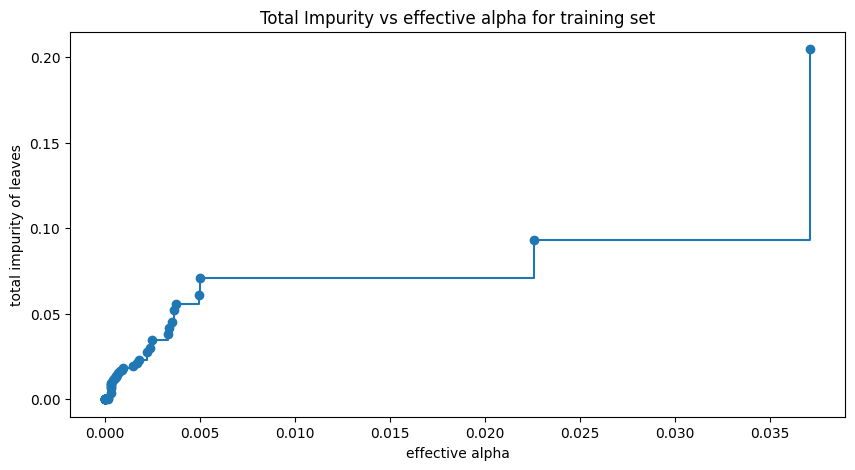

In [151]:
#let us plot the alphas VS the impurities
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

It is observed that the impurities show a sdeen peak after alpha = approx.0.005

Let us start training the decision tree using the effective alphas and observe how the tree depth vary with alpha



In [152]:
#an emplty list of post pruned trees (PP_trees)

PP_trees = []
for alpha in ccp_alphas:
    PP_tree = DecisionTreeClassifier(
        random_state=1, ccp_alpha=alpha, class_weight={0: 0.094571, 1: 0.905429}
    )
    PP_tree.fit(X_train, y_train)
    PP_trees.append(PP_tree)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        PP_trees[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.2953794476658226


Number of nodes in the last tree is: 1 with ccp_alpha: 0.2953794476658226
We will Remove the last elements in PP_trees and CCP_alphas as they relfect the smallest tree (one node) and proceed with the visualtization of the nodes and depth (i.e tree complexity) as alpha varies

In [153]:
PP_trees = PP_trees[:-1]
ccp_alphas = ccp_alphas[:-1]

It is observed that again at alpha = 0.005 the tree seems to have reached the smallest size which is underfitting the data. Hence, we now have an idea that the alpha value that will give us the optimum model performance is definitely below 0.05

Now, let us observe how the Model recall values at varying alphas for the training and test sets

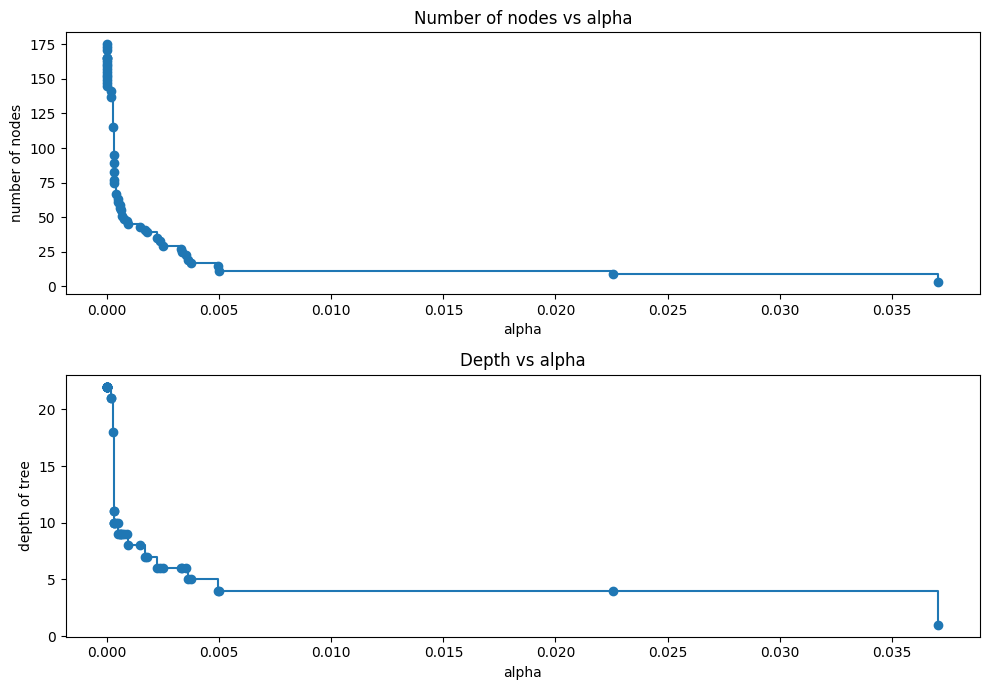

In [154]:
node_counts = [PP_tree.tree_.node_count for PP_tree in PP_trees]
depth = [PP_tree.tree_.max_depth for PP_tree in PP_trees]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [155]:
#derive the recall values for all PP_tress for the train set
recall_train = []
for PP_tree in PP_trees:
    y_pred_train = PP_tree.predict(X_train)
    values_train = recall_score(y_train, y_pred_train)
    recall_train.append(values_train)#derive the recall values for all PP_tress for the test set
recall_test = []
for PP_tree in PP_trees:
    y_pred_test = PP_tree.predict(X_test)
    values_test = recall_score(y_test, y_pred_test)
    recall_test.append(values_test)

In [156]:
#calculating the Accuracy of test and train models
train_scores = [PP_tree.score(X_train, y_train) for PP_tree in PP_trees]
test_scores = [PP_tree.score(X_test, y_test) for PP_tree in PP_trees]

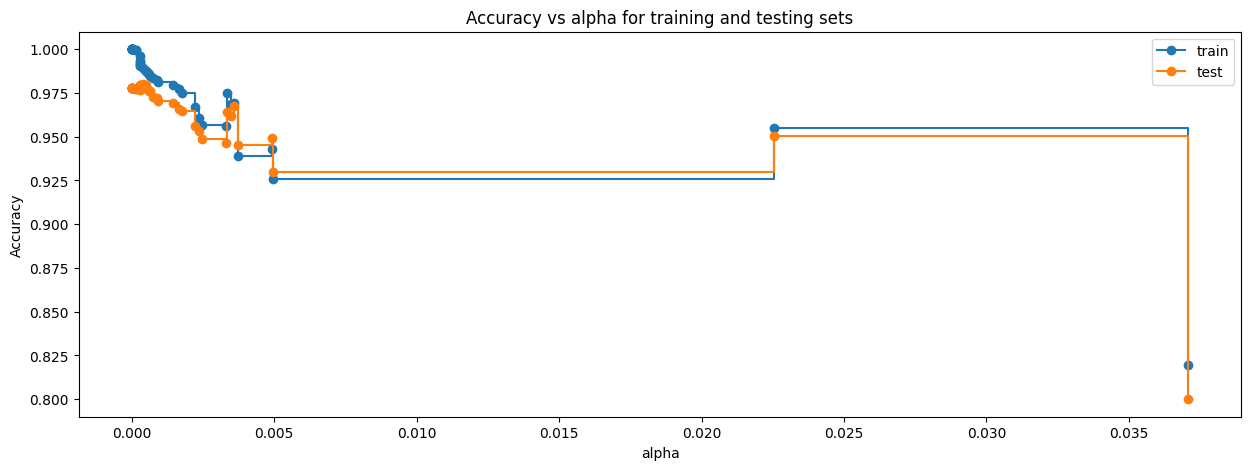

In [157]:
#plotting the accuracy for test and training sets
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

Again, we observe a better performance at alpha less than 0.05. Visually the value of alpha giving the best accuract is either very close to zero which could be still reflecting an over fitting tree, the other option is at approx 0.03 or 0.035. Still, the accuracy is not the optimum performance measure we are pursuing, we are to pursue the best Recall value as a performance measure


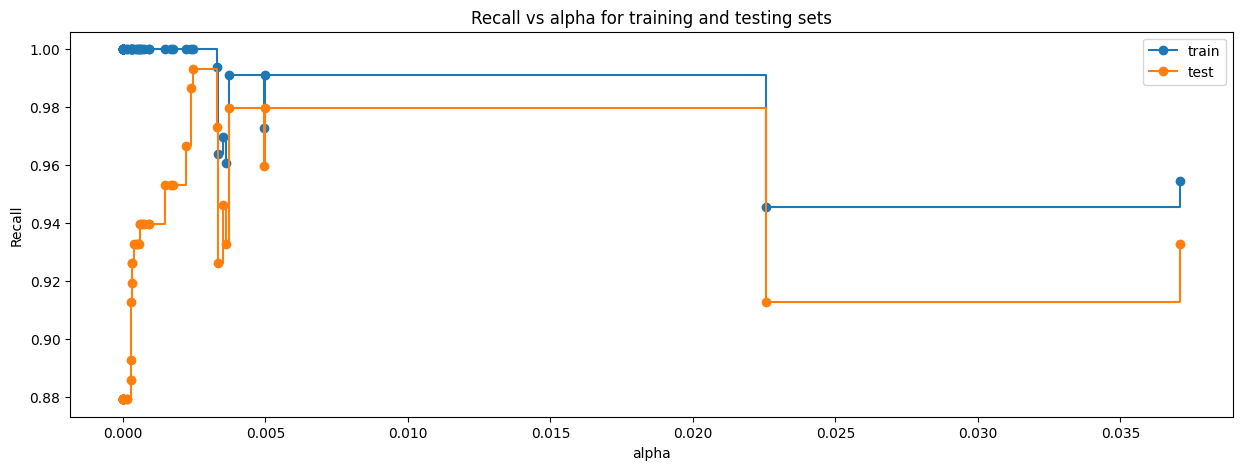

In [158]:
#plotting the recall scores for test and training sets VS Alpha
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [159]:
#let us derive the minimum alpha value for the test test
index_best_model = np.argmax(recall_test)
print(f''' The recall value giving the best predictibility model is: {recall_test[index_best_model]}
"The best alpha value is: {ccp_alphas[index_best_model]}"''')

 The recall value giving the best predictibility model is: 0.9932885906040269
"The best alpha value is: 0.002472652743953646"


he recall value giving the best predictibility model is: 0.9932885906040269
"The best alpha value is: 0.002472652743953624"
Deriving the best model PP_t_best and fitting it to the train set

In [160]:
PP_t_best_1 = PP_trees[index_best_model]
PP_t_best_1.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.002472652743953646,
                       class_weight={0: 0.094571, 1: 0.905429}, random_state=1)

Model Performance Evaluation_Post-pruned Tree

In [161]:
#Calculating the Recall for train and test data
Recall_Train_PP_t_best_1 = get_recall_score(PP_t_best_1, X_train, y_train)
print(f'Recall for PP_t_best_1 on Train Data = {Recall_Train_PP_t_best_1}')

Recall_Test_PP_t_best_1 = get_recall_score(PP_t_best_1, X_test, y_test)
print(f'Recall for PP_t_best_1 on Test Data = {Recall_Test_PP_t_best_1}')

Recall for PP_t_best_1 on Train Data = 1.0
Recall for PP_t_best_1 on Test Data = 0.9932885906040269


The Recall on train data sets is 1.0 which raises the suspicion of an overfitting model, yet its value is closer to the recall of the test dataset which is still better than t_0, yer requires further improvement. Hence, we will derive the tree, decision table and feature importantce for this model PP_t_best_1 and then derive another model of the second peak of alpha.

The tree depth is : 6


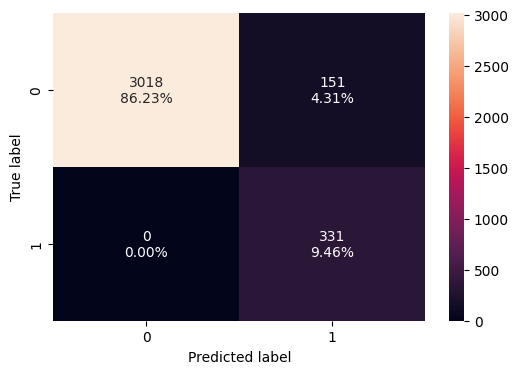

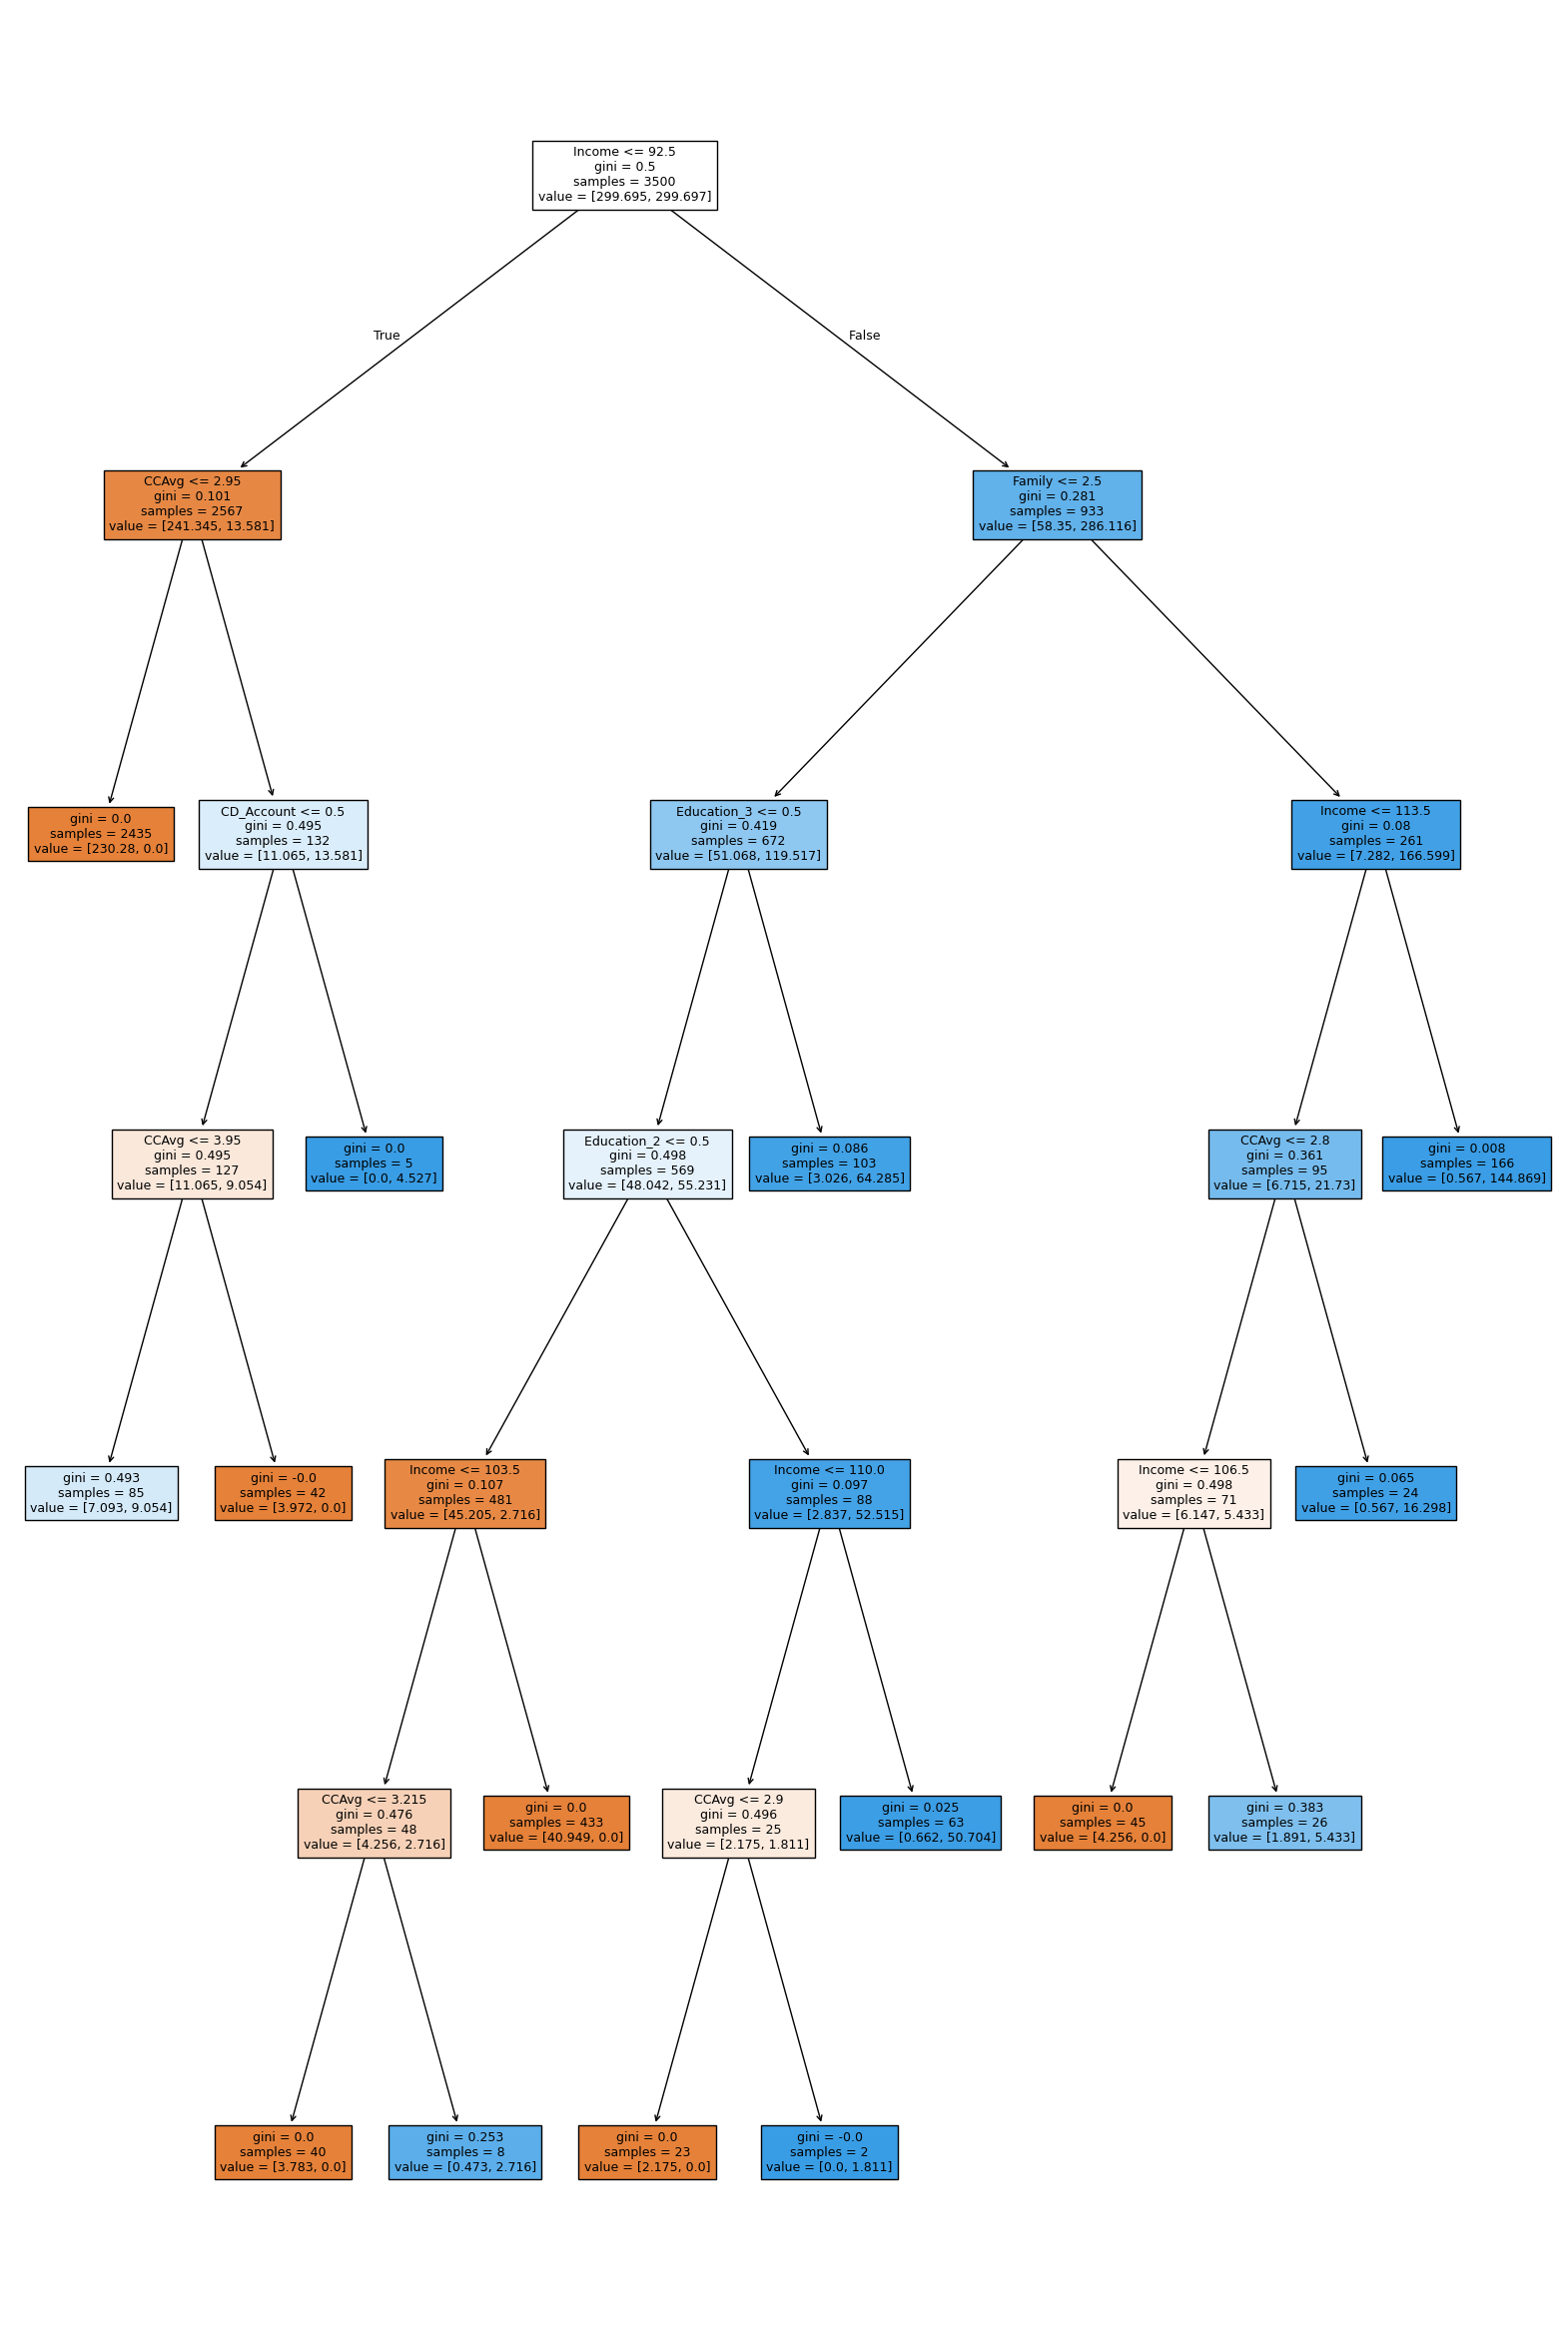

The features importances:
                                  Imp
Income                       0.668840
Education_2                  0.146614
CCAvg                        0.083952
Education_3                  0.051622
Family                       0.040953
CD_Account                   0.008018
City_Redlands                0.000000
City_Rio Vista               0.000000
City_Ridgecrest              0.000000
City_Richmond                0.000000
City_Reseda                  0.000000
City_Redwood City            0.000000
City_Redondo Beach           0.000000
Age                          0.000000
City_Redding                 0.000000
City_Rohnert Park            0.000000
City_Rancho Palos Verdes     0.000000
City_Rancho Cucamonga        0.000000
City_Rancho Cordova          0.000000
City_Poway                   0.000000
City_Riverside               0.000000
City_Sacramento              0.000000
City_Rosemead                0.000000
City_Roseville               0.000000
City_Rudno nad Hronom   

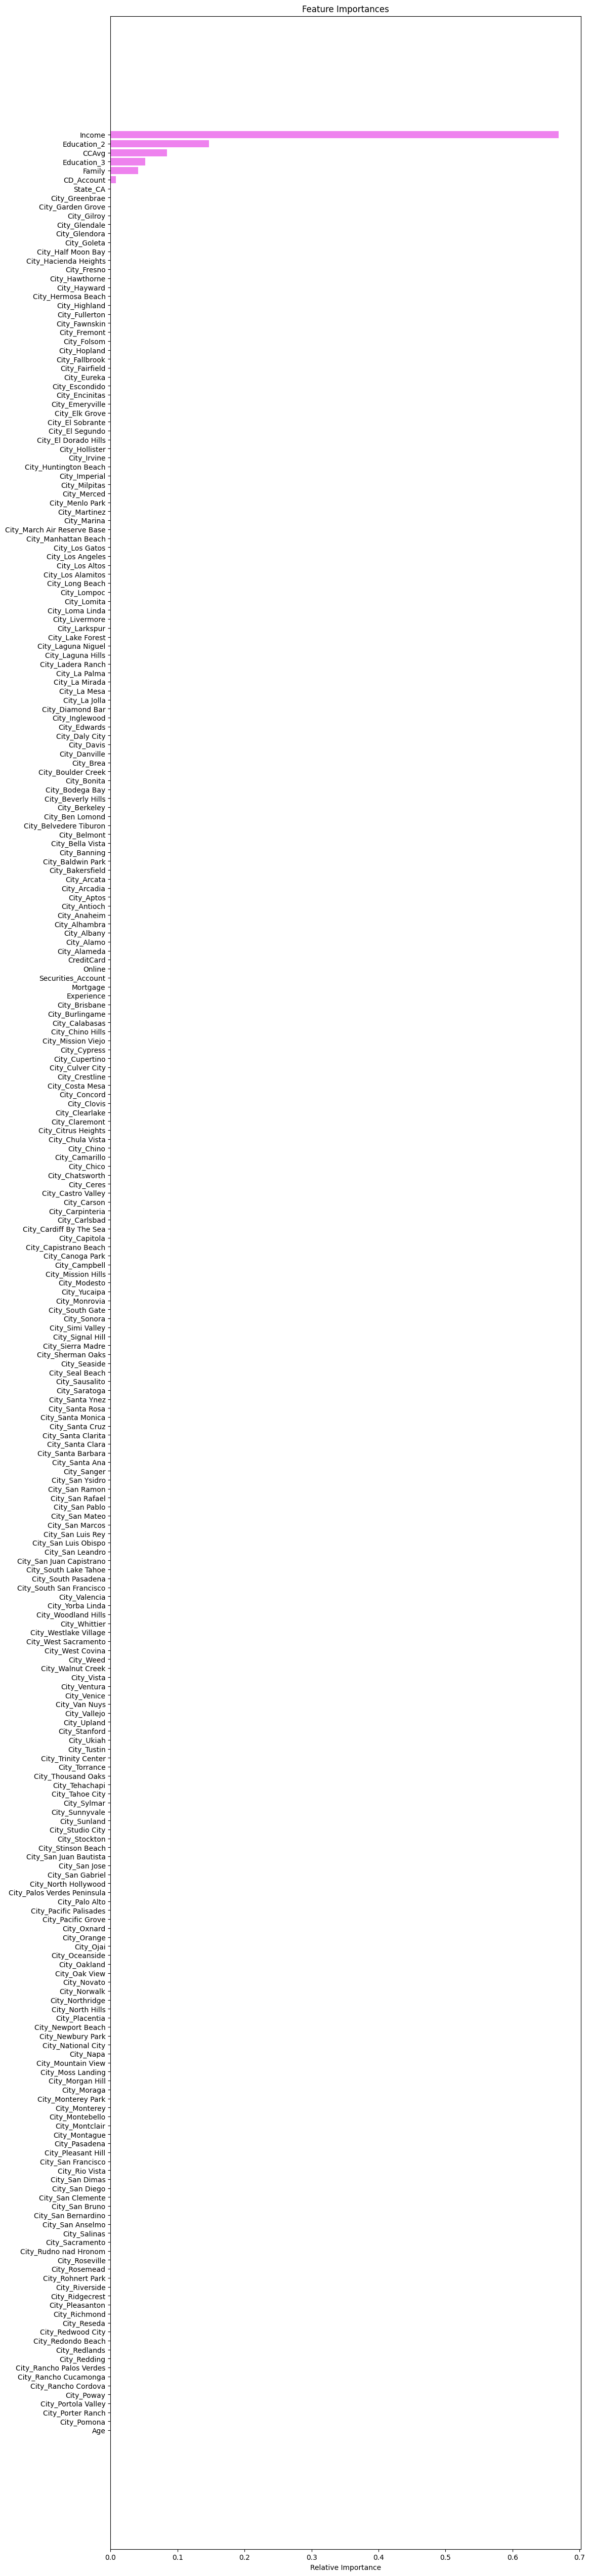

In [162]:
#plotting the tree, variables importance and the confusion matrix
print(f'The tree depth is : {PP_t_best_1.tree_.max_depth}')
confusion_matrix_sklearn(PP_t_best_1, X_train, y_train)
plot_tree(PP_t_best_1,X_train)
view_nd_plot_importance(PP_t_best_1, X_train)

Observation on PP_t_best_1 Model
At ccp_alpha=0.00247265274395358 and max_depth=6 the performance summary is:

Recall values:

Recall for PP_t_best_1 on Train Data = 1.0
Recall for PP_t_best_1 on Test Data = 0.9932885906040269
Features with max importance:
Income
Education_2
Less importance yet still having a predictibily effect:

CCAvg
Education_3
Family
Confusion matrix:

FN at 0.00% (Not realistic)
FP at 4.31%

Further model enhancement by deriving PP_t_best_2 Model

Earlier when we viewed the Recall_test and Recall_train VS the alpha, it was noticed another meeting point at an alpha near value of approx 0.03. Hence, our approach to avoid using an overfitting model is to extract a higher alpha that still gives a very good Recall value for the test set.

In [163]:
#creating a data frame including alpha, recall train and recall test
df = pd.DataFrame()
df[['ccp_alphas', 'recall_train', 'recall_test']]=''
df['ccp_alphas']=ccp_alphas
df['recall_train']= recall_train
df['recall_test']=recall_test
df

,ccp_alphas,recall_train,recall_test
0,0.000000e+00,1.000000,0.879195
1,1.156114e-18,1.000000,0.879195
2,1.509370e-18,1.000000,0.879195
3,1.541486e-18,1.000000,0.879195
4,1.541486e-18,1.000000,0.879195
5,1.541486e-18,1.000000,0.879195
6,2.452364e-18,1.000000,0.879195
7,3.082972e-18,1.000000,0.879195
8,8.408105e-18,1.000000,0.879195
9,8.670859e-18,1.000000,0.879195


At row 42 it is noticed good recall values for train and test sets at a value of alpha near the 0.003 threshold noticed on the curve. This value seems a good fit as it is not too close to an underfitting model, hence we will extract this value and observe how it behaves on the tree and confusion matrix

In [165]:
df.iloc[42]

,42
ccp_alphas,0.003504
recall_train,0.969789
recall_test,0.946309


In [166]:
#extracting the model from the 42nd model and fitting it to train and test data
PP_t_best_2 = PP_trees[42]
PP_t_best_2.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.003503778647096188,
                       class_weight={0: 0.094571, 1: 0.905429}, random_state=1)

Model Performance Evaluation of Post-pruned Tree PP_t_best_2

In [167]:
#Calculating the Recall for train and test data
Recall_Train_PP_t_best_2 = get_recall_score(PP_t_best_2, X_train, y_train)
print(f'Recall for PP_t_best_2 on Train Data = {Recall_Train_PP_t_best_2}')

Recall_Test_PP_t_best_2 = get_recall_score(PP_t_best_2, X_test, y_test)
print(f'Recall for PP_t_best_2 on Test Data = {get_recall_score(PP_t_best_2, X_test, y_test)}')

Recall for PP_t_best_2 on Train Data = 0.9697885196374623
Recall for PP_t_best_2 on Test Data = 0.9463087248322147


Recall for PP_t_best_2 on Train Data = 0.9909365558912386
Recall for PP_t_best_2 on Test Data = 0.9798657718120806
The Recall on test and train data sets are the same as stated in the dataframe df which was expected, let us move forward to visualizing the tree, the confusion matrix and feature importance

In [ ]:
#plotting the tree, variables importance and the confusion matrix
print(f'The tree depth is : {PP_t_best_2.tree_.max_depth}')
confusion_matrix_sklearn(PP_t_best_2, X_train, y_train)
plot_tree(PP_t_best_2,X_train)
view_nd_plot_importance(PP_t_best_2, X_train)

Observation on PP_t_best_2 Model:

With
ccp_alpha=0.003504
ccp_alpha=0.003504 and a max depth of 6, the performance of the PP_t_best_2 model surpasses that of PP_t_best_1. Although the recall values for both training and test sets are slightly lower, the false negative (FN) rate in the confusion matrix is reduced by half. The performance summary is as follows:

Recall values:

Recall for PP_t_best_2 on Training Data: 0.9698
Recall for PP_t_best_2 on Test Data: 0.9463
Features with the highest importance:

Income: 0.6761
Education_2: 0.1499
Features with lower importance but still predictive:

CCAvg: 0.0712
Education_3: 0.0528
Family: 0.0419
Confusion Matrix:

False Negative (FN) rate: 0.29%
False Positive (FP) rate: 2.83%

Model Performance Evaluation_Post-pruned Tree PP_t_best_3


In [168]:
df.iloc[44]

,44
ccp_alphas,0.003730
recall_train,0.990937
recall_test,0.979866


In [169]:
#extracting the model from the 42nd model and fitting it to train and test data
PP_t_best_3 = PP_trees[44]
PP_t_best_3.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.003729680161850272,
                       class_weight={0: 0.094571, 1: 0.905429}, random_state=1)

In [170]:
#Calculating the Recall for train and test data
Recall_Train_PP_t_best_3 = get_recall_score(PP_t_best_3, X_train, y_train)
print(f'Recall for PP_t_best_3 on Train Data = {Recall_Train_PP_t_best_3}')
Recall_Test_PP_t_best_3 = get_recall_score(PP_t_best_3, X_test, y_test)
print(f'Recall for PP_t_best_3 on Test Data = {Recall_Test_PP_t_best_3}')

Recall for PP_t_best_3 on Train Data = 0.9909365558912386
Recall for PP_t_best_3 on Test Data = 0.9798657718120806


Recall for PP_t_best_3 on Train Data = 0.9909365558912386
Recall for PP_t_best_3 on Test Data = 0.9798657718120806
The Recall on test and train data sets are the same as stated in the dataframe df which was expected, let us move forward to visualizing the tree, the confusion matrix and feature importance

The tree depth is : 5


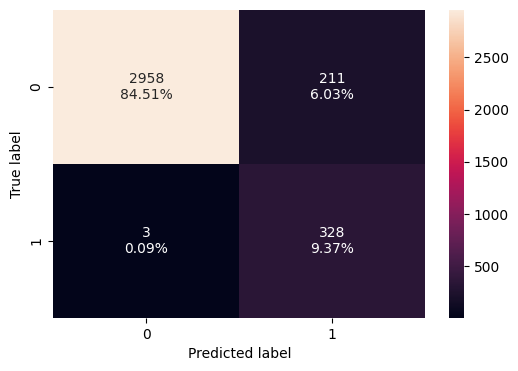

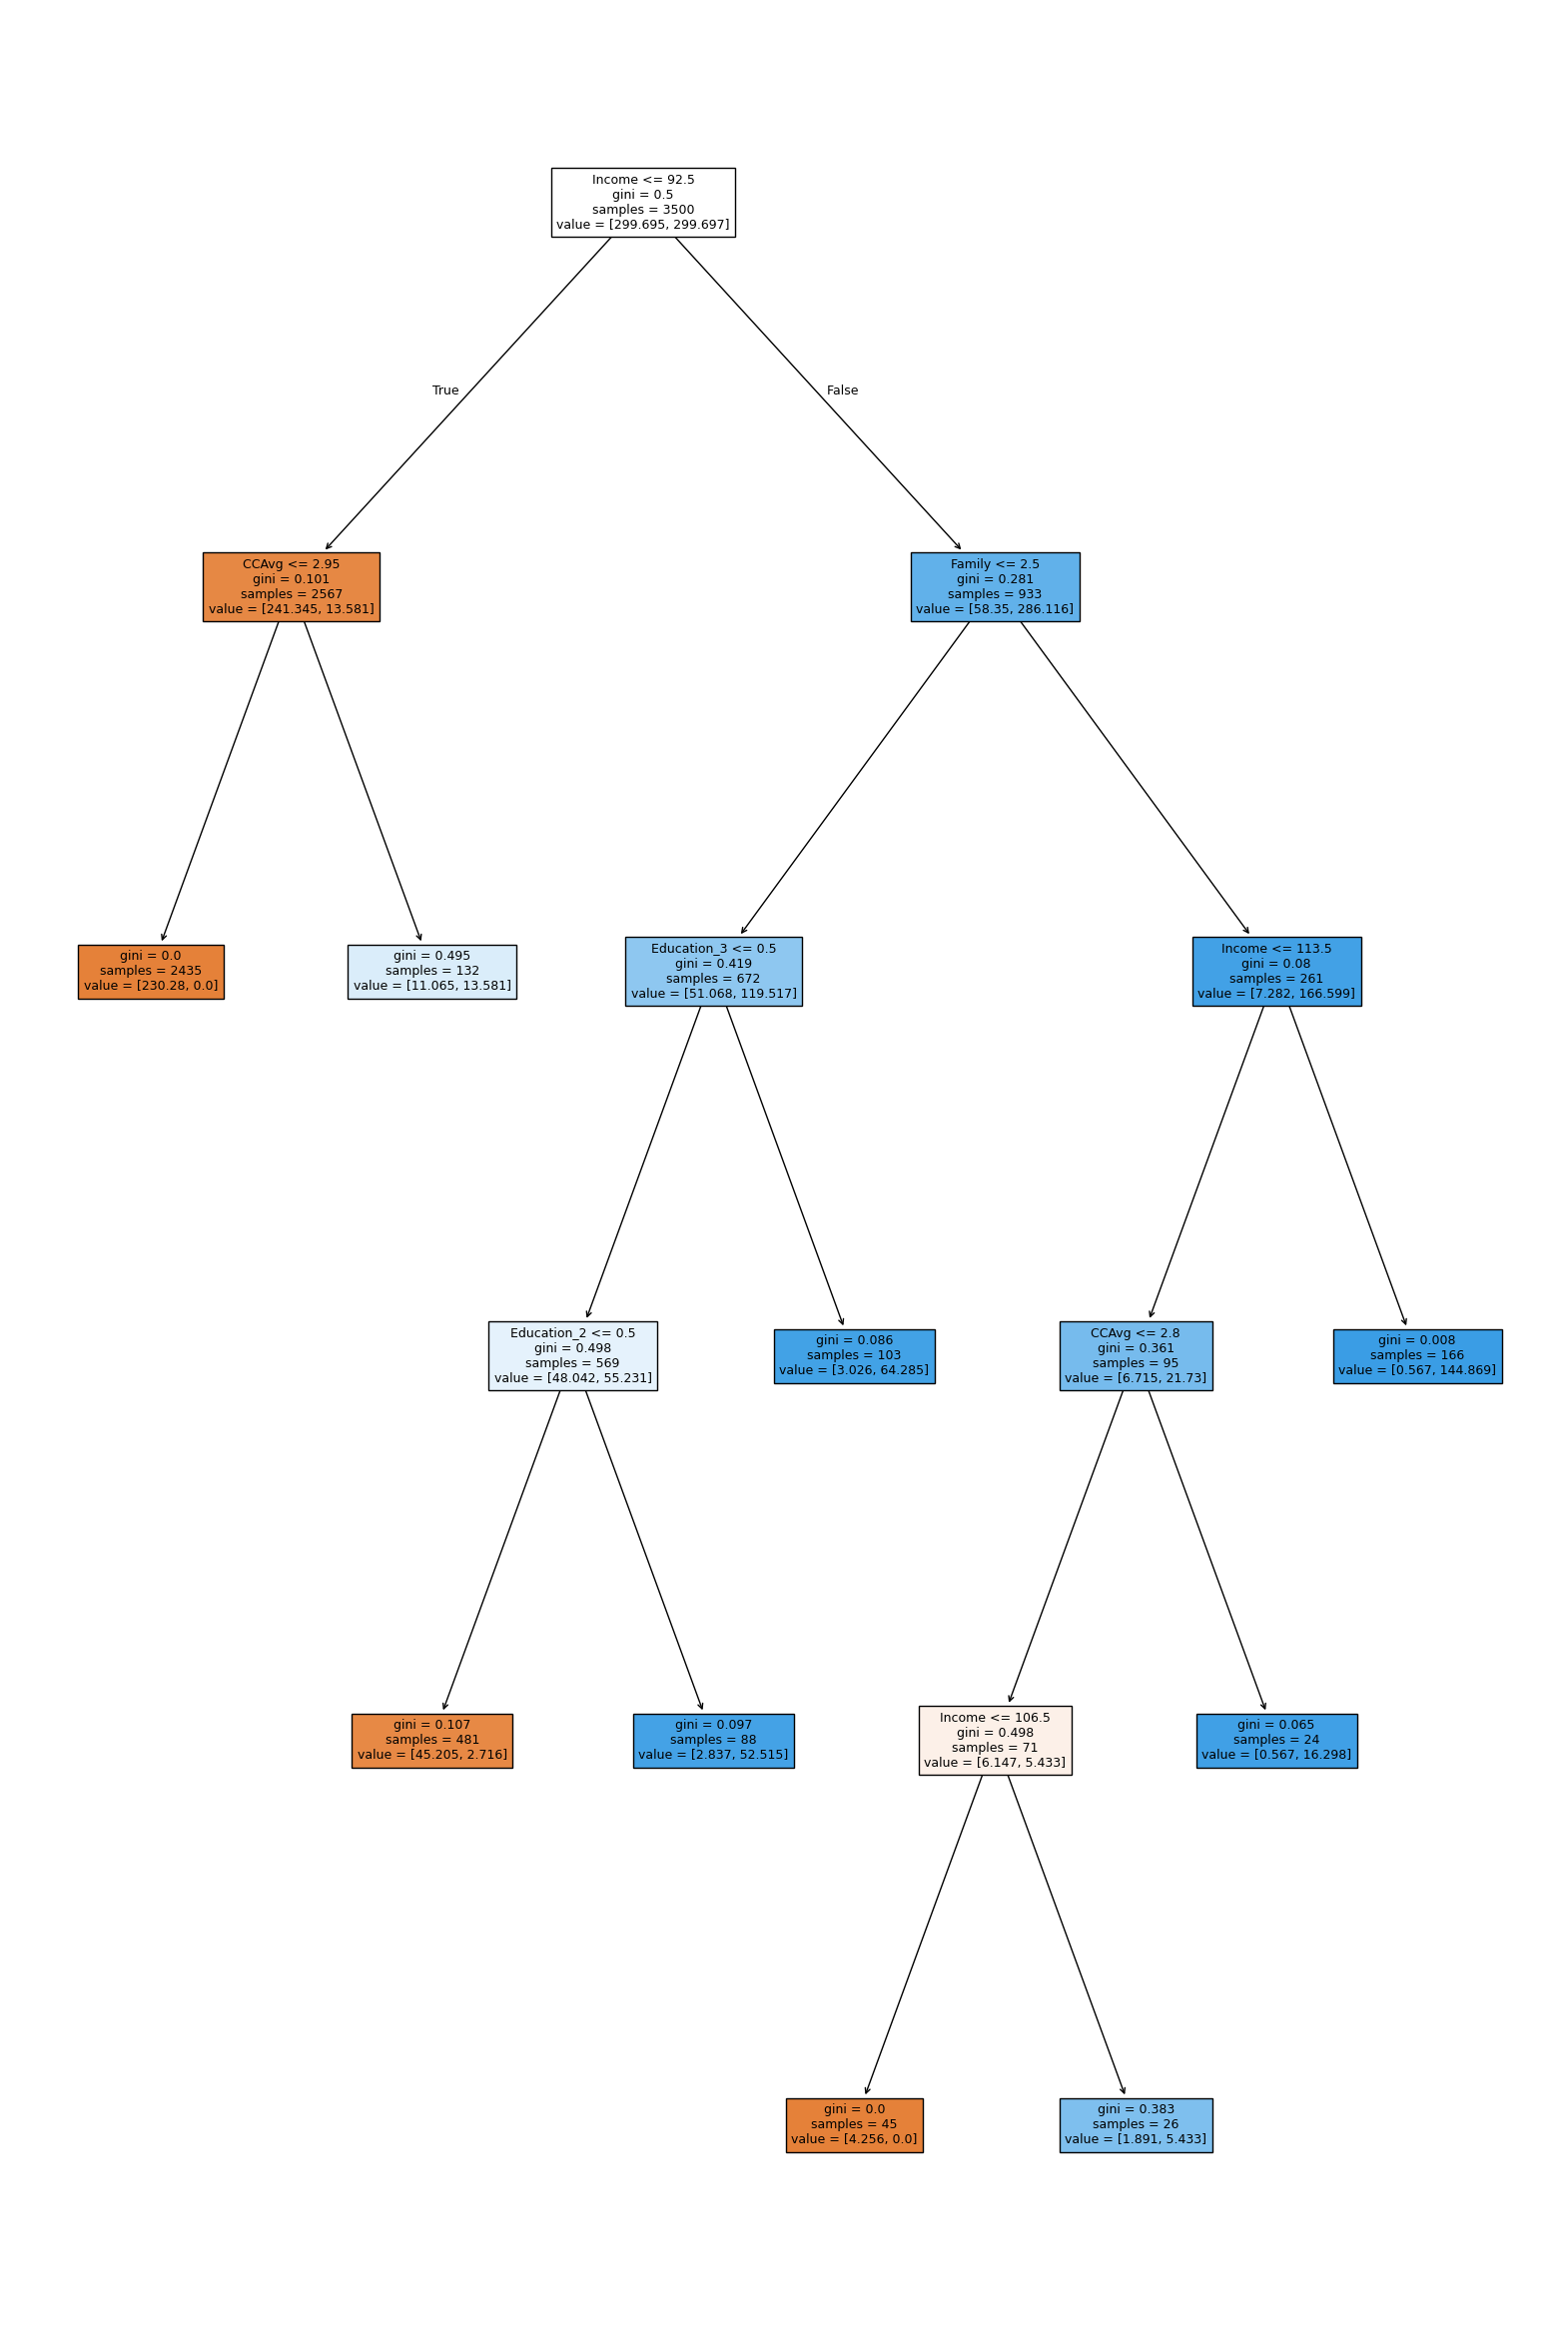

The features importances:
                                  Imp
Income                       0.685906
Education_2                  0.153574
CCAvg                        0.063550
Education_3                  0.054072
Family                       0.042897
City_Redlands                0.000000
City_Rio Vista               0.000000
City_Ridgecrest              0.000000
City_Richmond                0.000000
City_Reseda                  0.000000
City_Redwood City            0.000000
City_Redondo Beach           0.000000
Age                          0.000000
City_Rohnert Park            0.000000
City_Redding                 0.000000
City_Rancho Palos Verdes     0.000000
City_Rancho Cucamonga        0.000000
City_Rancho Cordova          0.000000
City_Poway                   0.000000
City_Riverside               0.000000
City_Rudno nad Hronom        0.000000
City_Rosemead                0.000000
City_Roseville               0.000000
City_Porter Ranch            0.000000
City_Sacramento         

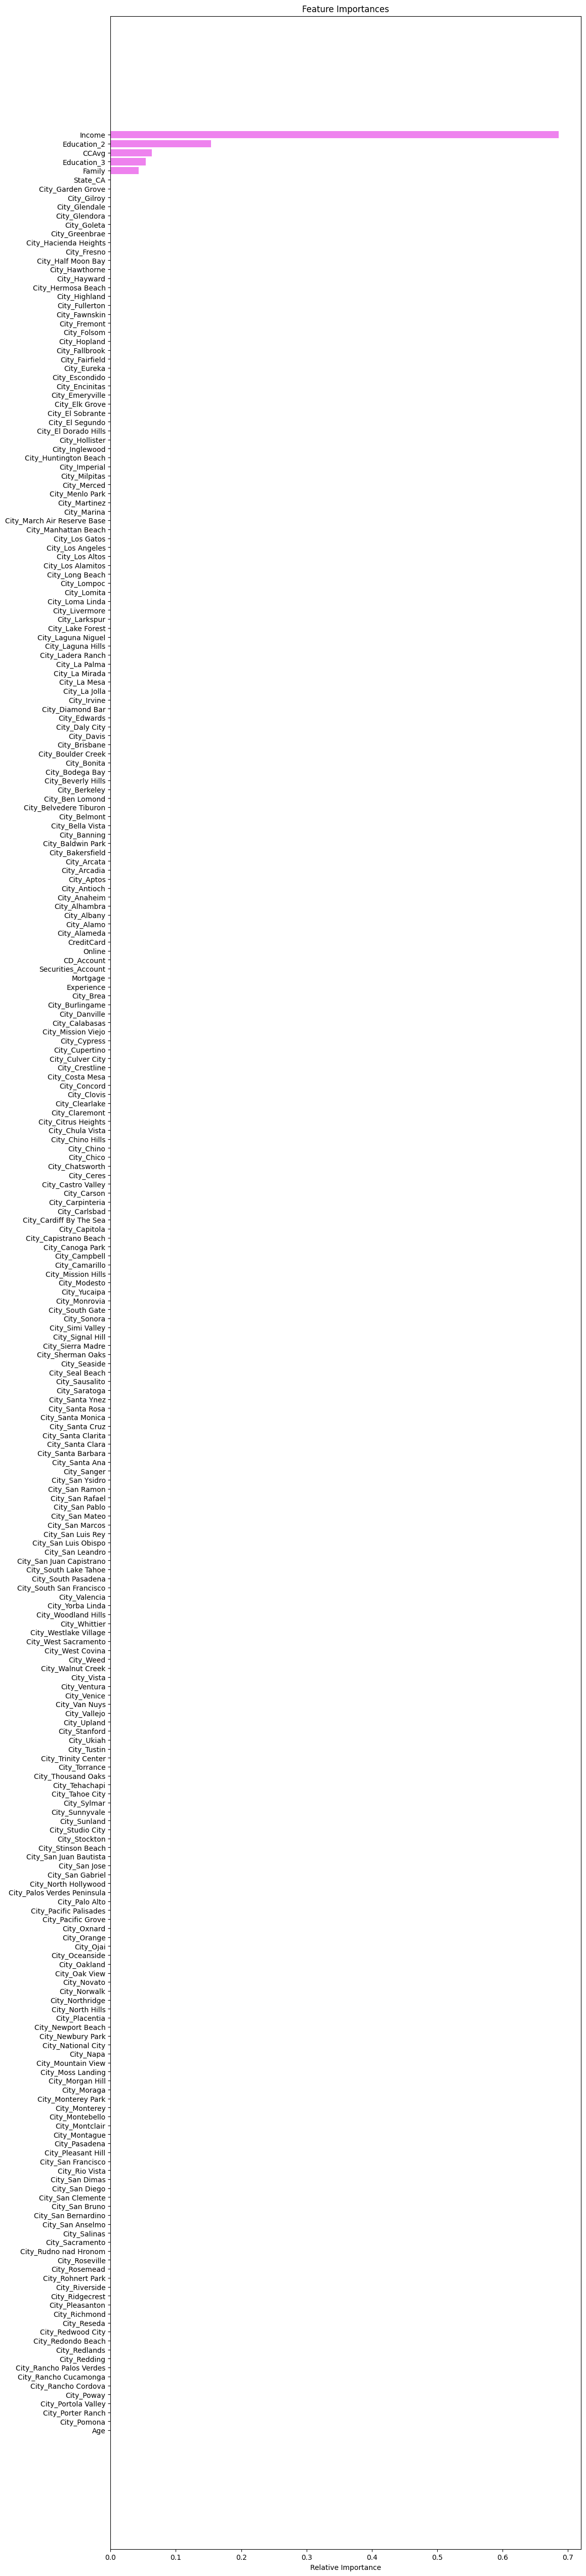

In [171]:
#plotting the tree, variables importance and the confusion matrix
print(f'The tree depth is : {PP_t_best_3.tree_.max_depth}')
confusion_matrix_sklearn(PP_t_best_3, X_train, y_train)
plot_tree(PP_t_best_3,X_train)
view_nd_plot_importance(PP_t_best_3, X_train)

Observation on PP_t_best_3 Model:

With
ccp_alpha=0.003730
ccp_alpha=0.003730 and a max depth of 5, the performance of PP_t_best_3 exceeds that of PP_t_best_2. Although the recall values for both the training and test sets are slightly lower, the false negative (FN) rate in the confusion matrix is reduced by half. The performance summary is as follows:

Recall values:

Recall for PP_t_best_3 on Training Data: 0.9909
Recall for PP_t_best_3 on Test Data: 0.9799
Features with the highest importance:

Income: 0.6859
Education_2: 0.1536
Features with lower importance but still predictive:

CCAvg: 0.0636
Education_3: 0.0541
Family: 0.0429
Confusion Matrix:

False Negative (FN) rate: 0.09%
False Positive (FP) rate: 6.03%

Decision Tree Models (post-pruning)
Model name	train_performance	recall (train)	test_performance	recall(test)	ccp_alpha
PP_t_best_1	Recall_Train_PP_t_best_1	1.0	Recall_Test_PP_t_best_1	0.99	0.002473
PP_t_best_2	Recall_Train_PP_t_best_2	0.97	Recall_Test_PP_t_best_2	0.95	0.003504
PP_t_best_3	Recall_Test_PP_t_best_3	0.99	Recall_Test_PP_t_best_3	0.98	0.003730

Conclusion of Post-prunning
The third and final model has a low tree depth of 5, hence less tree complexity of the tree using a greater value of alpha and it was successful in avoiding the model overfitting. Hence, The best performing model on the test set is **PP_t_best_3** with the below alpha value

Hyper parameter	Value
ccp_alpha	0.003730
Feature Importance:

Features with max importance:
Income 0.685906
Education_2 0.153574
Less importance yet still having a predictibily effect:
CCAvg 0.063550
Education_3 0.054072
Family 0.042897
End of Post-prunning

Actionable Insights & Recommendations
Final Model Comparison:

Modeling Algorithm	Model Name	Recall (Train)	Recall (Test)
Logistic Regression	lg with threshold 0.1	0.92	0.88
Decision Tree (Pre-Pruned)	t_1	0.99	0.95
Decision Tree (Post-Pruned)	PP_t_best_3	0.99	0.98
Insights:

The best-performing model was derived using the Decision Tree algorithm, where the original tree was post-pruned with
ccp_alpha=0.003730
ccp_alpha=0.003730. This model achieved the following recall values on the training and test datasets:

Recall on Train Data: 0.9909
Recall on Test Data: 0.9799
Based on statistical analysis, the features that most influence a customer's decision to accept a personal loan are ranked below, with priority levels (1 being the highest and 5 the lowest):

Priority	Feature	Effect on Customer Decision
1	Income	Higher income increases the likelihood of accepting a personal loan.
2	Education_2	Customers with education level 2 are more likely to accept a loan than those with levels 1 or 3.
3	CCAvg	As monthly spending increases, customers are more inclined to accept a personal loan.
4	Education_3	Customers with education level 3 are more willing to accept a loan than those with level 1.
5	Family	Larger family sizes are associated with a higher likelihood of accepting a personal loan.
Recommendations:

The marketing team should analyze customer profiles before offering personal loans to ensure they target the right audience.
The top 5 features listed above should be considered as key criteria for identifying the ideal customer profile for personal loan campaigns.